# ***PROBLEM TANIMI***

Yapay zeka araçlarının iş hayatına hızla entegre olduğu günümüzde, çalışanların bu dönüşüme verdiği psikolojik ve fiziksel tepkiler kurumlar için kritik bir yönetim meselesi haline gelmiştir. Farklı sektörlerden 8.500 çalışanın yaş, deneyim, günlük yapay zeka kullanım süresi, stres düzeyi, uyku saati ve iş yükü gibi çok boyutlu verileri derlenerek AI-insan iş birliğinin çalışan refahı üzerindeki etkisi belgelenmiştir. Bu veri seti; teknoloji, sağlık, eğitim ve finans gibi sektörlerdeki çalışanların tükenmişlik dinamiklerini anlamak ve erken uyarı mekanizmaları geliştirmek isteyen İK departmanları ile organizasyonel psikoloji araştırmacıları için somut bir ihtiyaca yanıt vermektedir. Projenin temel amacı, söz konusu çok değişkenli yapıyı kullanarak her çalışanı "No Risk", "At Risk" ve "Burned Out" olmak üzere üç tükenmişlik düzeyinden birine atayan bir sınıflandırma modeli geliştirmek ve böylece risk altındaki bireylerin proaktif biçimde tespit edilmesini sağlamaktır.

In [1]:
!pip install category_encoders

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 85.9/85.9 kB 2.6 MB/s eta 0:00:00


In [38]:
!pip install codecarbon

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 380.5/380.5 kB 8.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 155.6/155.6 kB 7.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 51.8/51.8 kB 2.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.0/8.0 MB 38.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.1/3.1 MB 41.3 MB/s eta 0:00:00
  Attempting uninstall: psutil
    Found existing installation: psutil 5.9.5
    Uninstalling psutil-5.9.5:
      Successfully uninstalled psutil-5.9.5


In [68]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import time
import os
import psutil
import pickle
import matplotlib.patches as mpatches
from codecarbon import EmissionsTracker
from sklearn.model_selection import train_test_split
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, roc_auc_score, confusion_matrix,
                             classification_report)
import matplotlib
import matplotlib.gridspec as gridspec
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import (StratifiedKFold, GridSearchCV,
                                     cross_val_score)
from sklearn.metrics import make_scorer, f1_score
from xgboost import XGBClassifier
from sklearn.utils.class_weight import compute_sample_weight
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from matplotlib.patches import FancyBboxPatch
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import LabelEncoder, OneHotEncoder
from category_encoders import TargetEncoder
from imblearn.over_sampling import SMOTE, ADASYN
from imblearn.under_sampling import RandomUnderSampler
from imblearn.combine import SMOTETomek
from collections import Counter
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

In [2]:
BG        = "#0D1117"
PANEL     = "#161B22"
BORDER    = "#30363D"
C1        = "#58A6FF"   # No Risk   – mavi
C2        = "#F0883E"   # At Risk   – turuncu
C3        = "#FF4D4D"   # Burned Out – kırmızı
TEXT_PRI  = "#E6EDF3"
TEXT_SEC  = "#8B949E"
PALETTE   = [C1, C2, C3]
LABEL_MAP = {"No Risk": C1, "At Risk": C2, "Burned Out": C3}

In [3]:
dfC = pd.read_csv('/content/ai_burnout_human_ai_collaboration.csv')

In [4]:
df = dfC.copy()

In [5]:
matplotlib.rcParams.update({
    "figure.facecolor":  BG,
    "axes.facecolor":    PANEL,
    "axes.edgecolor":    BORDER,
    "axes.labelcolor":   TEXT_PRI,
    "xtick.color":       TEXT_SEC,
    "ytick.color":       TEXT_SEC,
    "text.color":        TEXT_PRI,
    "grid.color":        BORDER,
    "grid.linestyle":    "--",
    "grid.alpha":        0.5,
    "font.family":       "DejaVu Sans",
    "axes.spines.top":   False,
    "axes.spines.right": False,
})

counts = df["Burnout_Label"].value_counts().reindex(["No Risk", "At Risk", "Burned Out"])
pcts   = counts / counts.sum() * 100

# ***VERİYE İLK BAKIŞ***

In [7]:
df.head(3)

,Worker_ID,Age,Industry,Job_Role,Years_Experience,AI_Tools_Used_Daily,AI_Hours_Per_Day,AI_Adoption_Level,Perceived_Usefulness,Skill_Anxiety_Score,Work_Hours_Per_Week,Meetings_Per_Week,Deep_Work_Hours,Interruptions_Per_Day,Sleep_Hours_Per_Night,Physical_Activity_Days,Stress_Level,Job_Satisfaction,Cognitive_Load_Score,Remote_Work_Ratio,Productivity_Score,Burnout_Label
0,1,22,Finance,Accountant,0.1,5,4.2,2,9,10,53.8,12,3.4,21,6.4,4,6,5,3,0.74,76.0,No Risk
1,2,29,Creative,Copywriter,9.7,5,3.4,2,10,2,39.0,10,3.6,7,5.6,2,5,8,4,0.24,72.9,No Risk
2,3,39,Education,Curriculum Designer,16.0,4,3.5,2,5,5,54.7,4,4.5,10,6.5,4,8,3,2,0.22,61.8,At Risk


In [8]:
df.tail(3)

,Worker_ID,Age,Industry,Job_Role,Years_Experience,AI_Tools_Used_Daily,AI_Hours_Per_Day,AI_Adoption_Level,Perceived_Usefulness,Skill_Anxiety_Score,Work_Hours_Per_Week,Meetings_Per_Week,Deep_Work_Hours,Interruptions_Per_Day,Sleep_Hours_Per_Night,Physical_Activity_Days,Stress_Level,Job_Satisfaction,Cognitive_Load_Score,Remote_Work_Ratio,Productivity_Score,Burnout_Label
8497,8498,33,Healthcare,Physician,12.4,4,3.8,2,10,4,49.5,7,3.4,9,5.4,1,5,5,6,0.11,68.7,No Risk
8498,8499,45,Technology,DevOps Engineer,21.0,1,1.8,0,3,3,42.3,7,1.4,9,6.4,0,4,2,5,0.56,42.4,No Risk
8499,8500,41,Finance,Risk Manager,20.4,4,3.5,2,7,4,51.6,7,3.6,17,5.1,2,8,4,4,0.53,69.6,At Risk


In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8500 entries, 0 to 8499
Data columns (total 22 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Worker_ID               8500 non-null   int64  
 1   Age                     8500 non-null   int64  
 2   Industry                8500 non-null   object 
 3   Job_Role                8500 non-null   object 
 4   Years_Experience        8500 non-null   float64
 5   AI_Tools_Used_Daily     8500 non-null   int64  
 6   AI_Hours_Per_Day        8500 non-null   float64
 7   AI_Adoption_Level       8500 non-null   int64  
 8   Perceived_Usefulness    8500 non-null   int64  
 9   Skill_Anxiety_Score     8500 non-null   int64  
 10  Work_Hours_Per_Week     8500 non-null   float64
 11  Meetings_Per_Week       8500 non-null   int64  
 12  Deep_Work_Hours         8500 non-null   float64
 13  Interruptions_Per_Day   8500 non-null   int64  
 14  Sleep_Hours_Per_Night   8500 non-null   

In [ ]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Worker_ID,8500.0,4250.500000,2453.882977,1.00,2125.75,4250.50,6375.250,8500.00
Age,8500.0,35.228118,7.651922,22.00,30.00,35.00,40.000,60.00
Years_Experience,8500.0,12.806588,7.703482,0.00,7.10,12.50,18.000,35.00
AI_Tools_Used_Daily,8500.0,4.278941,2.302912,0.00,2.00,4.00,6.000,10.00
AI_Hours_Per_Day,8500.0,3.248824,1.725235,0.00,1.90,3.30,4.700,8.00
AI_Adoption_Level,8500.0,1.636118,1.038245,0.00,1.00,2.00,3.000,3.00
Perceived_Usefulness,8500.0,7.058353,2.481727,1.00,5.00,7.00,9.000,10.00
Skill_Anxiety_Score,8500.0,4.781647,2.069129,1.00,3.00,5.00,6.000,10.00
Work_Hours_Per_Week,8500.0,46.565176,8.189794,25.00,41.10,46.55,52.000,74.30
Meetings_Per_Week,8500.0,8.615059,3.169682,1.00,6.00,8.00,11.000,22.00


In [ ]:
df.isnull().sum()

,0
Worker_ID,0
Age,0
Industry,0
Job_Role,0
Years_Experience,0
AI_Tools_Used_Daily,0
AI_Hours_Per_Day,0
AI_Adoption_Level,0
Perceived_Usefulness,0
Skill_Anxiety_Score,0


In [ ]:
df.duplicated().sum()

np.int64(0)

In [ ]:
df['Burnout_Label'].value_counts()   #dengesiz bir sınıf dağılımı görülmekte

,count
Burnout_Label,
No Risk,6601
At Risk,1865
Burned Out,34


# ***HEDEF DEĞİŞKEN ANALİZİ***

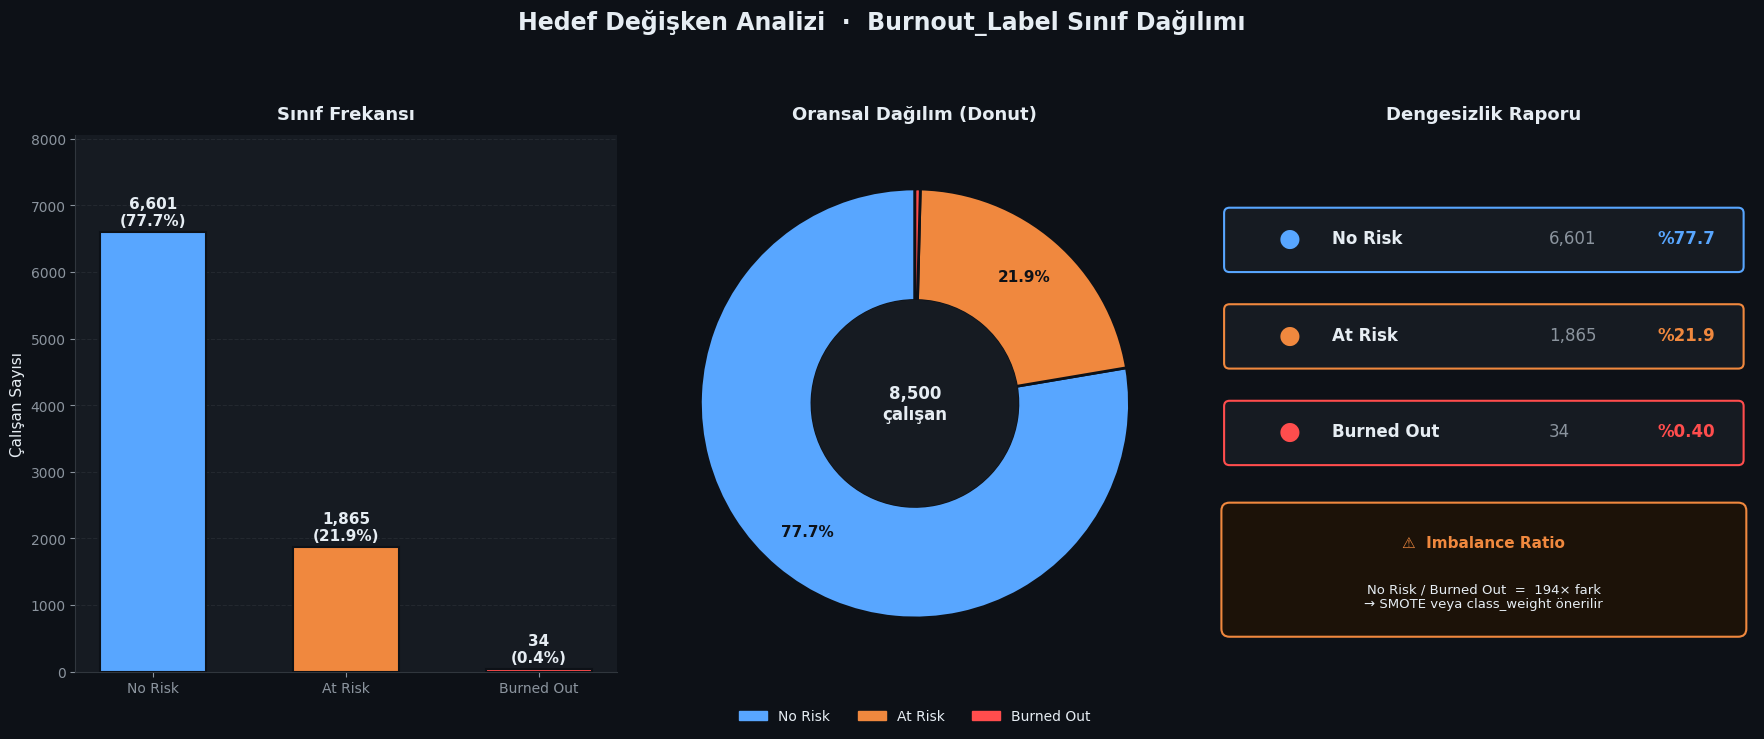

In [7]:
fig1, axes = plt.subplots(1, 3, figsize=(18, 7))
fig1.suptitle("Hedef Değişken Analizi  ·  Burnout_Label Sınıf Dağılımı",
              fontsize=17, fontweight="bold", color=TEXT_PRI, y=1.02)

ax = axes[0]
bars = ax.bar(counts.index, counts.values,
              color=PALETTE, width=0.55, zorder=3,
              edgecolor=BG, linewidth=1.5)
for bar, val, pct in zip(bars, counts.values, pcts.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 60,
            f"{val:,}\n({pct:.1f}%)", ha="center", va="bottom",
            fontsize=11, fontweight="bold", color=TEXT_PRI)
ax.set_title("Sınıf Frekansı", fontsize=13, fontweight="bold", color=TEXT_PRI, pad=12)
ax.set_ylabel("Çalışan Sayısı", fontsize=11)
ax.set_ylim(0, counts.max() * 1.22)
ax.yaxis.grid(True, zorder=0)
ax.set_axisbelow(True)

ax2 = axes[1]
wedges, texts, autotexts = ax2.pie(
    counts.values, labels=None,
    colors=PALETTE, startangle=90,
    autopct=lambda p: f"{p:.1f}%" if p > 1 else "",
    pctdistance=0.78,
    wedgeprops=dict(width=0.52, edgecolor=BG, linewidth=2))
for at in autotexts:
    at.set_color(BG); at.set_fontweight("bold"); at.set_fontsize(11)
centre = plt.Circle((0, 0), 0.48, color=PANEL)
ax2.add_artist(centre)
ax2.text(0, 0, "8,500\nçalışan", ha="center", va="center",
         fontsize=12, fontweight="bold", color=TEXT_PRI)
legend_patches = [mpatches.Patch(color=c, label=l) for l, c in LABEL_MAP.items()]
ax2.legend(handles=legend_patches, loc="lower center",
           bbox_to_anchor=(0.5, -0.12), ncol=3,
           frameon=False, fontsize=10, labelcolor=TEXT_PRI)
ax2.set_title("Oransal Dağılım (Donut)", fontsize=13, fontweight="bold", color=TEXT_PRI, pad=12)

ax3 = axes[2]
ax3.set_xlim(0, 1); ax3.set_ylim(0, 1)
ax3.axis("off")
ax3.set_title("Dengesizlik Raporu", fontsize=13, fontweight="bold", color=TEXT_PRI, pad=12)

ir = counts.max() / counts.min()
lines = [
    ("No Risk",    f"{counts['No Risk']:,}",    f"%{pcts['No Risk']:.1f}",    C1),
    ("At Risk",    f"{counts['At Risk']:,}",    f"%{pcts['At Risk']:.1f}",    C2),
    ("Burned Out", f"{counts['Burned Out']:,}", f"%{pcts['Burned Out']:.2f}", C3),
]
y0 = 0.82
for label, cnt, pct, col in lines:
    ax3.add_patch(FancyBboxPatch((0.03, y0-0.065), 0.94, 0.1,
                  boxstyle="round,pad=0.01", linewidth=1.5,
                  edgecolor=col, facecolor=PANEL, zorder=2))
    ax3.text(0.12, y0-0.012, "●", color=col, fontsize=18, va="center")
    ax3.text(0.22, y0-0.012, label, fontsize=12, fontweight="bold", color=TEXT_PRI, va="center")
    ax3.text(0.62, y0-0.012, cnt,   fontsize=12, color=TEXT_SEC, va="center")
    ax3.text(0.82, y0-0.012, pct,   fontsize=12, fontweight="bold", color=col, va="center")
    y0 -= 0.18

ax3.add_patch(FancyBboxPatch((0.03, 0.08), 0.94, 0.22,
              boxstyle="round,pad=0.015", linewidth=1.5,
              edgecolor="#F0883E", facecolor="#1C1208", zorder=2))
ax3.text(0.5, 0.24, "⚠  Imbalance Ratio",
         ha="center", fontsize=11, fontweight="bold", color=C2, va="center")
ax3.text(0.5, 0.14,
         f"No Risk / Burned Out  =  {ir:.0f}× fark\n→ SMOTE veya class_weight önerilir",
         ha="center", fontsize=9.5, color=TEXT_PRI, va="center")

plt.tight_layout(pad=2)
plt.show()

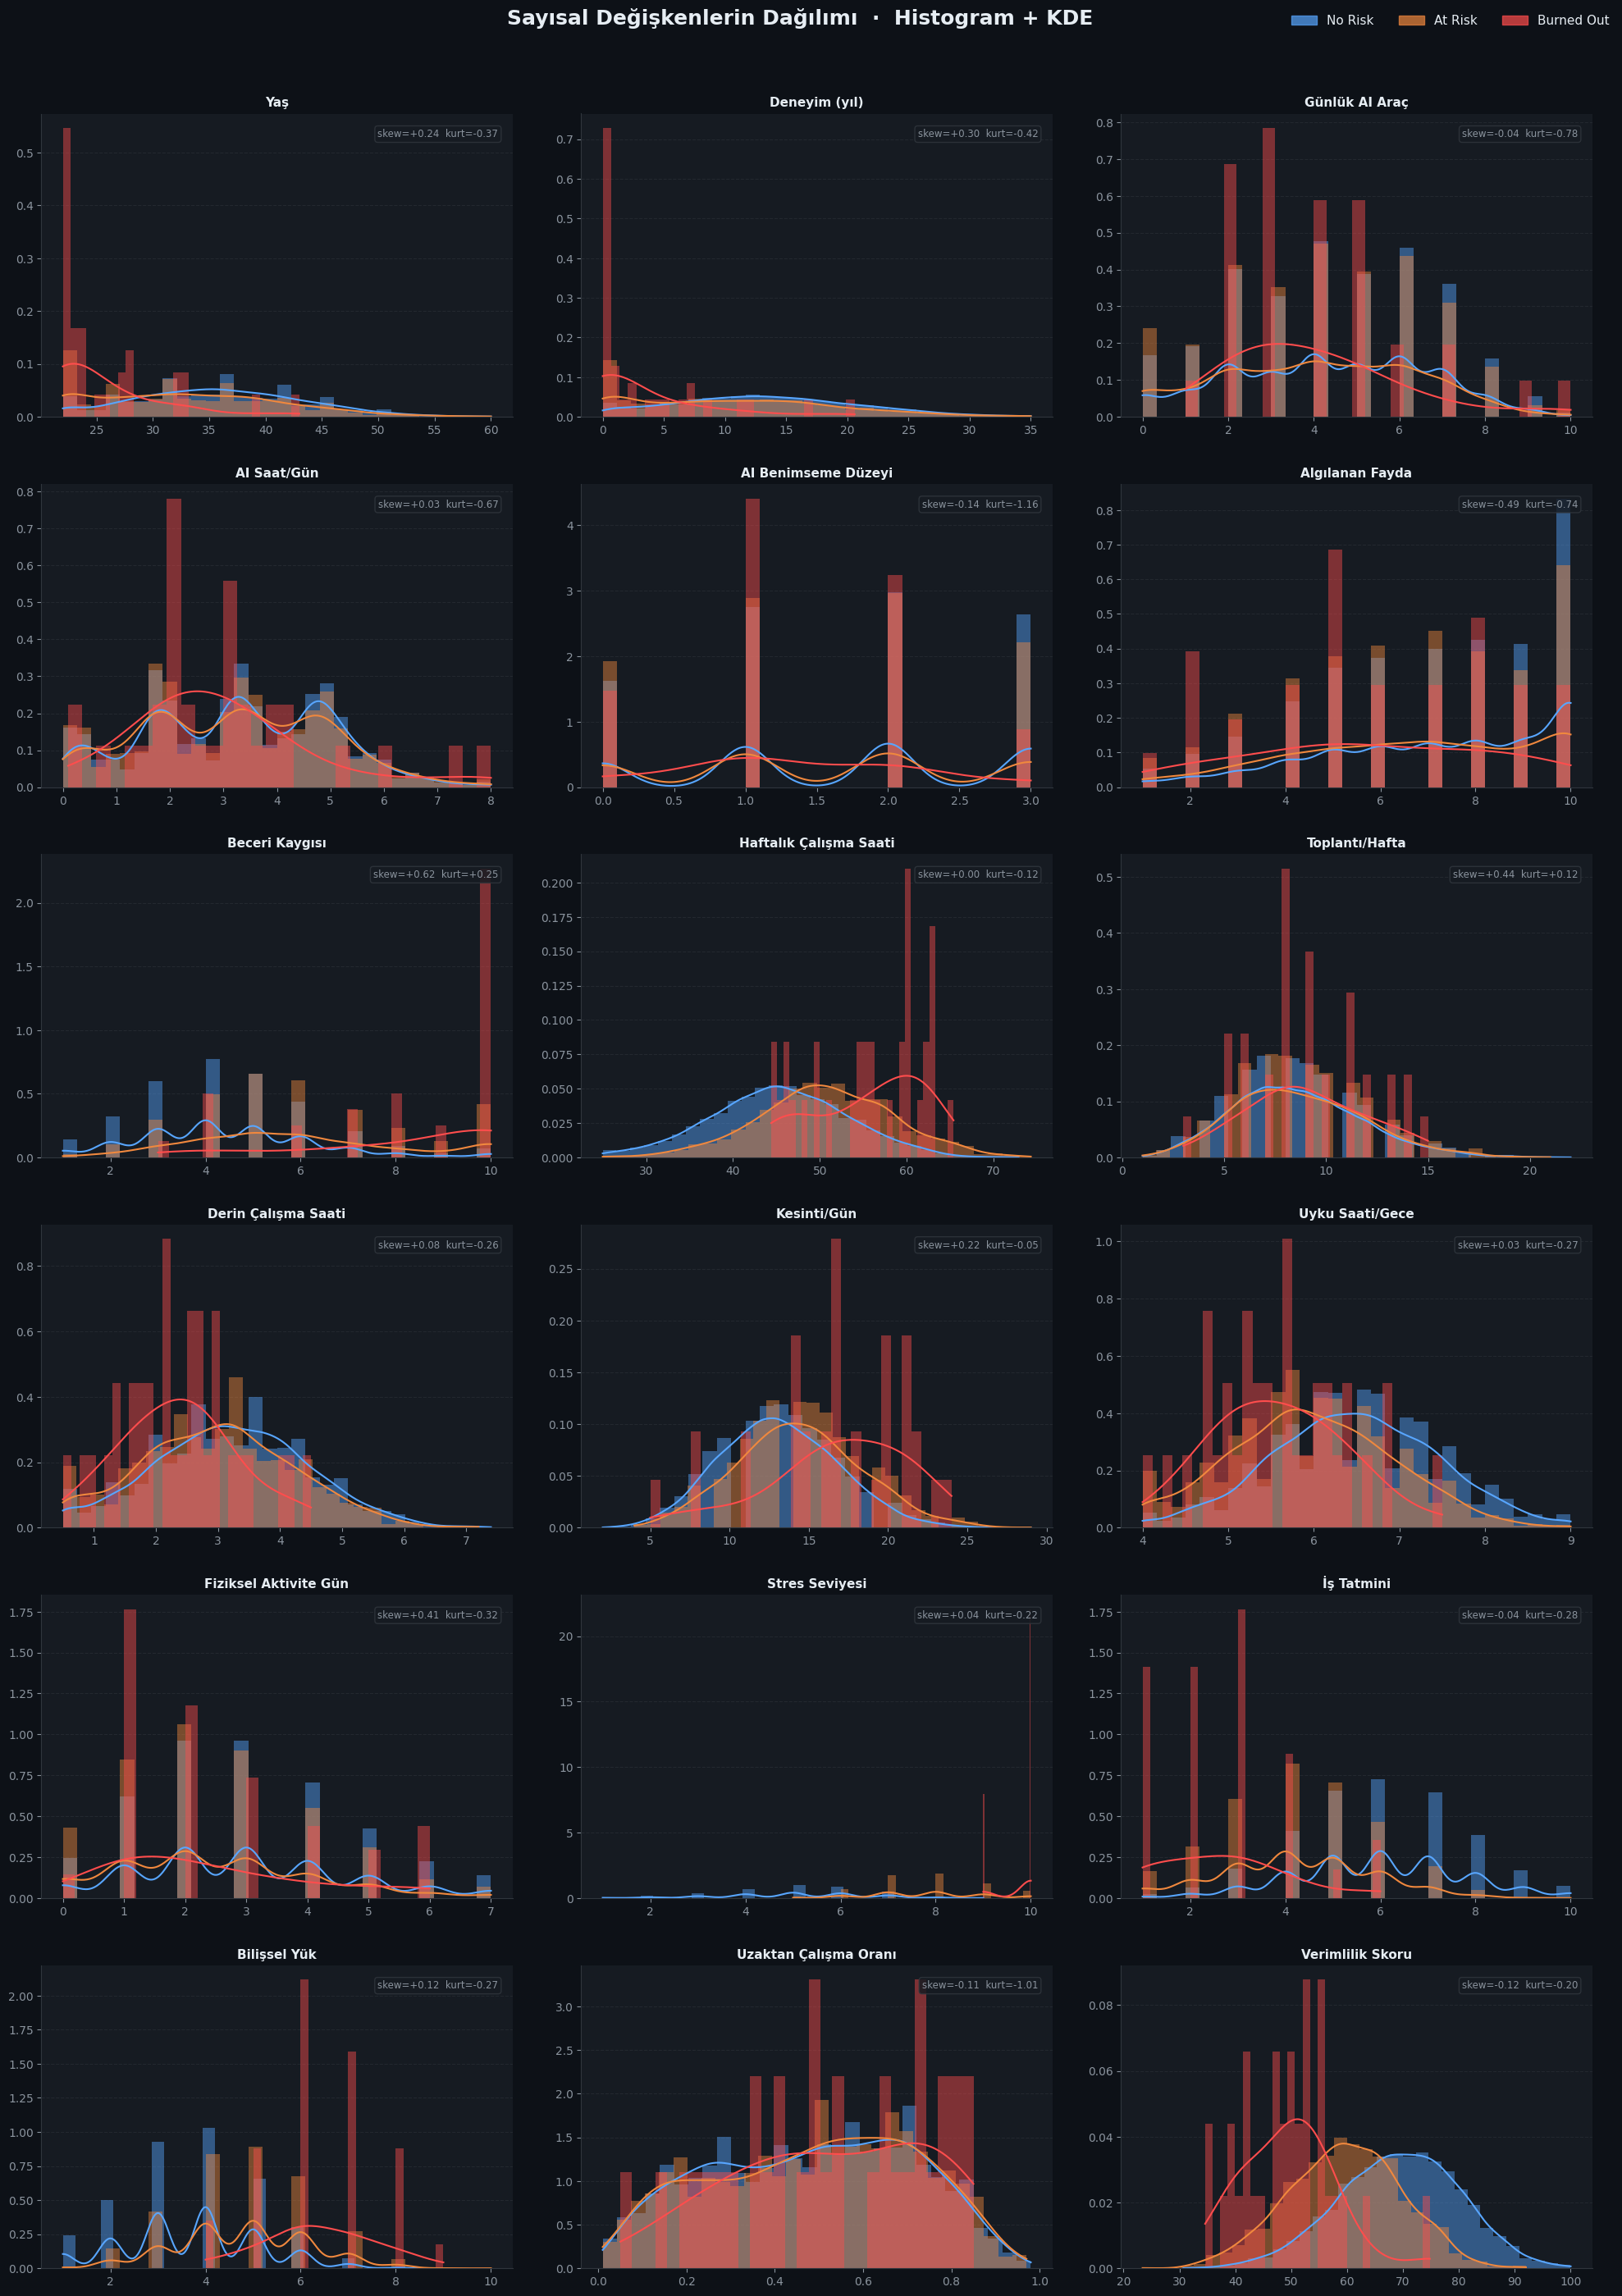

In [8]:
num_cols = ['Age','Years_Experience','AI_Tools_Used_Daily','AI_Hours_Per_Day',
            'AI_Adoption_Level','Perceived_Usefulness','Skill_Anxiety_Score',
            'Work_Hours_Per_Week','Meetings_Per_Week','Deep_Work_Hours',
            'Interruptions_Per_Day','Sleep_Hours_Per_Night','Physical_Activity_Days',
            'Stress_Level','Job_Satisfaction','Cognitive_Load_Score',
            'Remote_Work_Ratio','Productivity_Score']

label_tr = {
    'Age':'Yaş','Years_Experience':'Deneyim (yıl)',
    'AI_Tools_Used_Daily':'Günlük AI Araç','AI_Hours_Per_Day':'AI Saat/Gün',
    'Work_Hours_Per_Week':'Haftalık Çalışma Saati','Stress_Level':'Stres Seviyesi',
    'Sleep_Hours_Per_Night':'Uyku Saati/Gece','Productivity_Score':'Verimlilik Skoru',
    'Skill_Anxiety_Score':'Beceri Kaygısı','Cognitive_Load_Score':'Bilişsel Yük',
    'Job_Satisfaction':'İş Tatmini','Interruptions_Per_Day':'Kesinti/Gün',
    'Deep_Work_Hours':'Derin Çalışma Saati','Meetings_Per_Week':'Toplantı/Hafta',
    'Physical_Activity_Days':'Fiziksel Aktivite Gün','Remote_Work_Ratio':'Uzaktan Çalışma Oranı',
    'Perceived_Usefulness':'Algılanan Fayda','AI_Adoption_Level':'AI Benimseme Düzeyi'
}

fig2, axes = plt.subplots(6, 3, figsize=(20, 28))
fig2.suptitle("Sayısal Değişkenlerin Dağılımı  ·  Histogram + KDE",
              fontsize=18, fontweight="bold", color=TEXT_PRI, y=1.005)
axes = axes.flatten()

for i, col in enumerate(num_cols):
    ax = axes[i]
    skew = df[col].skew()
    kurt = df[col].kurtosis()
    for lbl, col_c in zip(["No Risk","At Risk","Burned Out"], PALETTE):
        sub = df[df["Burnout_Label"]==lbl][col]
        ax.hist(sub, bins=30, alpha=0.45, color=col_c, density=True, label=lbl)
        kde_x = np.linspace(sub.min(), sub.max(), 300)
        kde = stats.gaussian_kde(sub)
        ax.plot(kde_x, kde(kde_x), color=col_c, lw=1.5)
    ax.set_title(label_tr[col], fontsize=11, fontweight="bold", color=TEXT_PRI, pad=6)
    ax.yaxis.grid(True, zorder=0); ax.set_axisbelow(True)
    ax.text(0.97, 0.95, f"skew={skew:+.2f}  kurt={kurt:+.2f}",
            transform=ax.transAxes, ha="right", va="top", fontsize=8.5, color=TEXT_SEC,
            bbox=dict(facecolor=PANEL, edgecolor=BORDER, boxstyle="round,pad=0.3", alpha=0.85))

handles = [plt.Rectangle((0,0),1,1, color=c, alpha=0.7) for c in PALETTE]
fig2.legend(handles, ["No Risk","At Risk","Burned Out"],
            loc="upper right", bbox_to_anchor=(1.0, 1.007),
            ncol=3, frameon=False, fontsize=11, labelcolor=TEXT_PRI)
plt.tight_layout(pad=2.5)
plt.show()

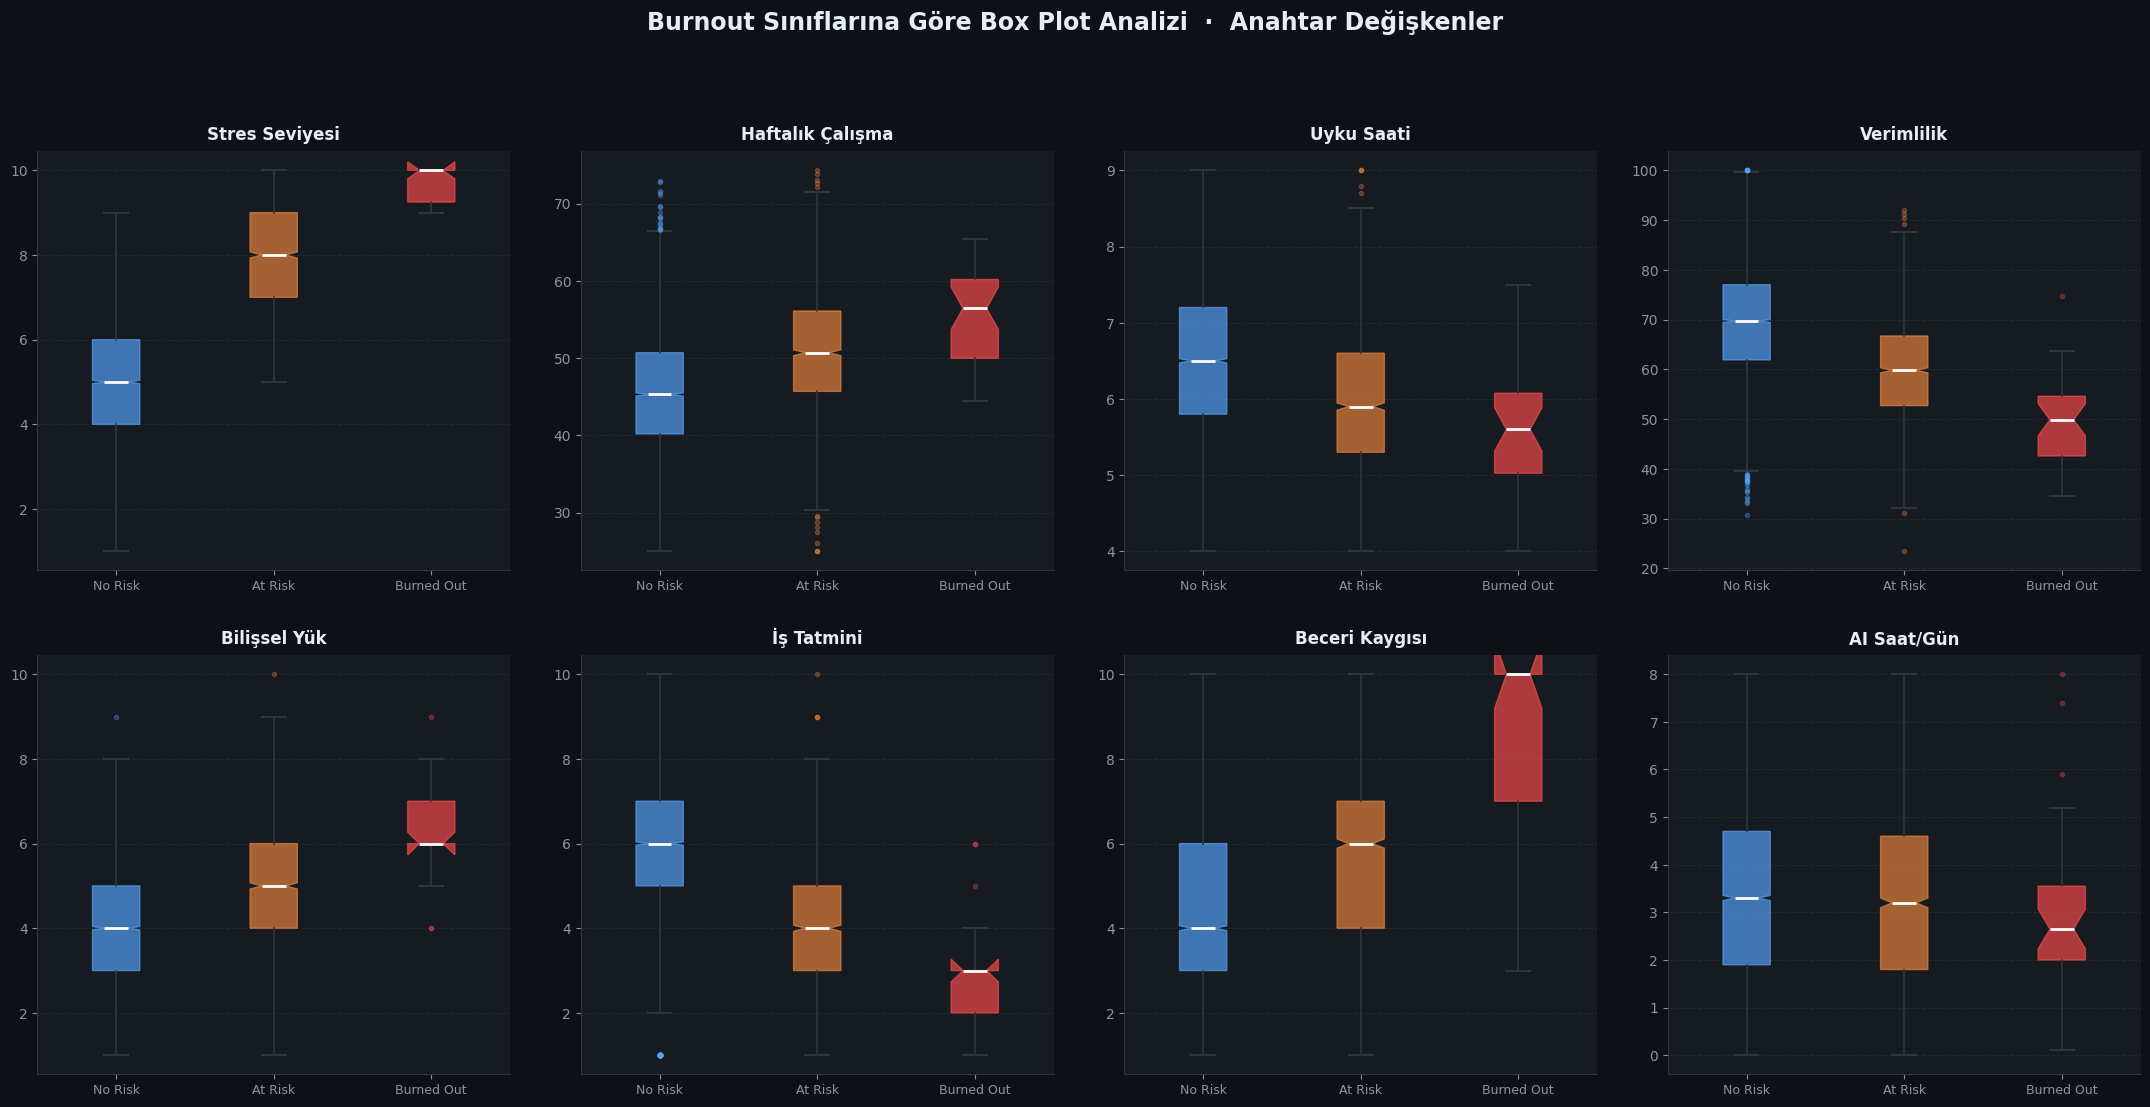

In [15]:
key_cols = ['Stress_Level','Work_Hours_Per_Week','Sleep_Hours_Per_Night',
            'Productivity_Score','Cognitive_Load_Score','Job_Satisfaction',
            'Skill_Anxiety_Score','AI_Hours_Per_Day']
label_tr2 = {
    'Stress_Level':'Stres Seviyesi','Work_Hours_Per_Week':'Haftalık Çalışma',
    'Sleep_Hours_Per_Night':'Uyku Saati','Productivity_Score':'Verimlilik',
    'Cognitive_Load_Score':'Bilişsel Yük','Job_Satisfaction':'İş Tatmini',
    'Skill_Anxiety_Score':'Beceri Kaygısı','AI_Hours_Per_Day':'AI Saat/Gün'
}
ORDER = ["No Risk","At Risk","Burned Out"]

fig3, axes = plt.subplots(2, 4, figsize=(22, 11))
fig3.suptitle("Burnout Sınıflarına Göre Box Plot Analizi  ·  Anahtar Değişkenler",
              fontsize=17, fontweight="bold", color=TEXT_PRI, y=1.02)
axes = axes.flatten()

for i, col in enumerate(key_cols):
    ax = axes[i]
    bp = ax.boxplot(
        [df[df["Burnout_Label"]==lbl][col].values for lbl in ORDER],
        patch_artist=True, notch=True,
        medianprops=dict(color="white", linewidth=2),
        whiskerprops=dict(color=BORDER, linewidth=1.2),
        capprops=dict(color=BORDER, linewidth=1.5),
        flierprops=dict(marker="o", markersize=3, alpha=0.3)
    )
    for patch, color in zip(bp['boxes'], PALETTE):
        patch.set_facecolor(color); patch.set_alpha(0.65); patch.set_edgecolor(color)
    for flier, color in zip(bp['fliers'], PALETTE):
        flier.set_markerfacecolor(color); flier.set_markeredgecolor(color)
    ax.set_xticklabels(["No Risk","At Risk","Burned Out"], fontsize=9, color=TEXT_SEC)
    ax.set_title(label_tr2[col], fontsize=12, fontweight="bold", color=TEXT_PRI, pad=8)
    ax.yaxis.grid(True, zorder=0); ax.set_axisbelow(True)

plt.tight_layout(pad=2.5)
plt.show()

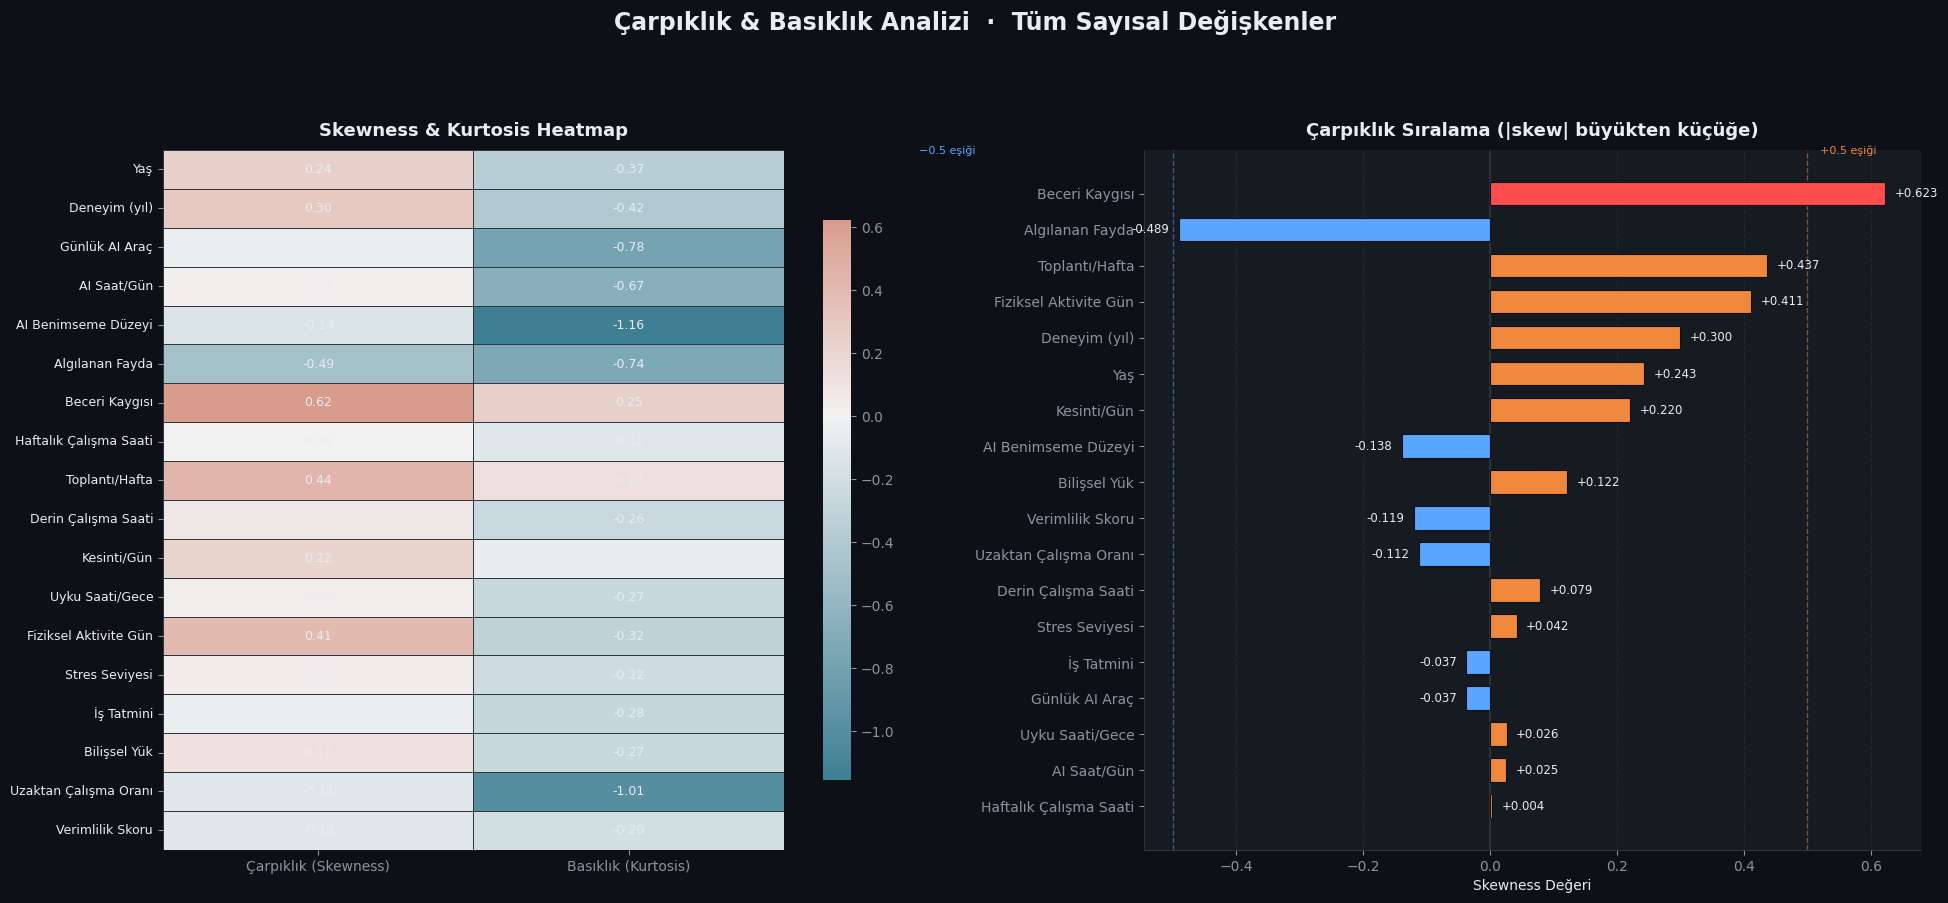

In [16]:
skew_vals = {c: df[c].skew()     for c in num_cols}
kurt_vals = {c: df[c].kurtosis() for c in num_cols}

sk_df = pd.DataFrame({"Çarpıklık (Skewness)": skew_vals,
                       "Basıklık (Kurtosis)":  kurt_vals})
sk_df.index = [label_tr[c] for c in num_cols]

fig5, (ax1, ax2) = plt.subplots(1, 2, figsize=(20, 9))
fig5.suptitle("Çarpıklık & Basıklık Analizi  ·  Tüm Sayısal Değişkenler",
              fontsize=17, fontweight="bold", color=TEXT_PRI, y=1.02)

cmap = sns.diverging_palette(220, 20, as_cmap=True)
sns.heatmap(sk_df, ax=ax1, cmap=cmap, center=0, annot=True,
            fmt=".2f", linewidths=0.5, linecolor=BORDER,
            annot_kws={"size":9, "color": TEXT_PRI},
            cbar_kws={"shrink":0.8})
ax1.set_title("Skewness & Kurtosis Heatmap", fontsize=13, fontweight="bold", color=TEXT_PRI, pad=10)
ax1.tick_params(axis='x', labelcolor=TEXT_SEC, labelsize=10)
ax1.tick_params(axis='y', labelcolor=TEXT_PRI, labelsize=9)

sk_sorted = sorted(skew_vals.items(), key=lambda x: abs(x[1]), reverse=True)
names  = [label_tr[k] for k,v in sk_sorted]
values = [v for k,v in sk_sorted]
colors = [C3 if v > 0.5 else C2 if v > 0 else C1 for v in values]

bars = ax2.barh(names, values, color=colors, edgecolor=BG,
                linewidth=0.8, height=0.65, zorder=3)
ax2.axvline(0,    color=BORDER, lw=1.2, zorder=2)
ax2.axvline( 0.5, color=C2, lw=1, ls="--", alpha=0.5, zorder=2)
ax2.axvline(-0.5, color=C1, lw=1, ls="--", alpha=0.5, zorder=2)
ax2.text(0.52, -1.1, "+0.5 eşiği", color=C2, fontsize=8)
ax2.text(-0.9, -1.1, "−0.5 eşiği", color=C1, fontsize=8)
for bar, val in zip(bars, values):
    ax2.text(val + (0.015 if val>=0 else -0.015),
             bar.get_y() + bar.get_height()/2,
             f"{val:+.3f}", va="center",
             ha="left" if val>=0 else "right",
             fontsize=8.5, color=TEXT_PRI)
ax2.set_title("Çarpıklık Sıralama (|skew| büyükten küçüğe)",
              fontsize=13, fontweight="bold", color=TEXT_PRI, pad=10)
ax2.set_xlabel("Skewness Değeri", fontsize=10)
ax2.xaxis.grid(True, zorder=0); ax2.set_axisbelow(True)
ax2.invert_yaxis()

plt.tight_layout(pad=2.5)
plt.show()

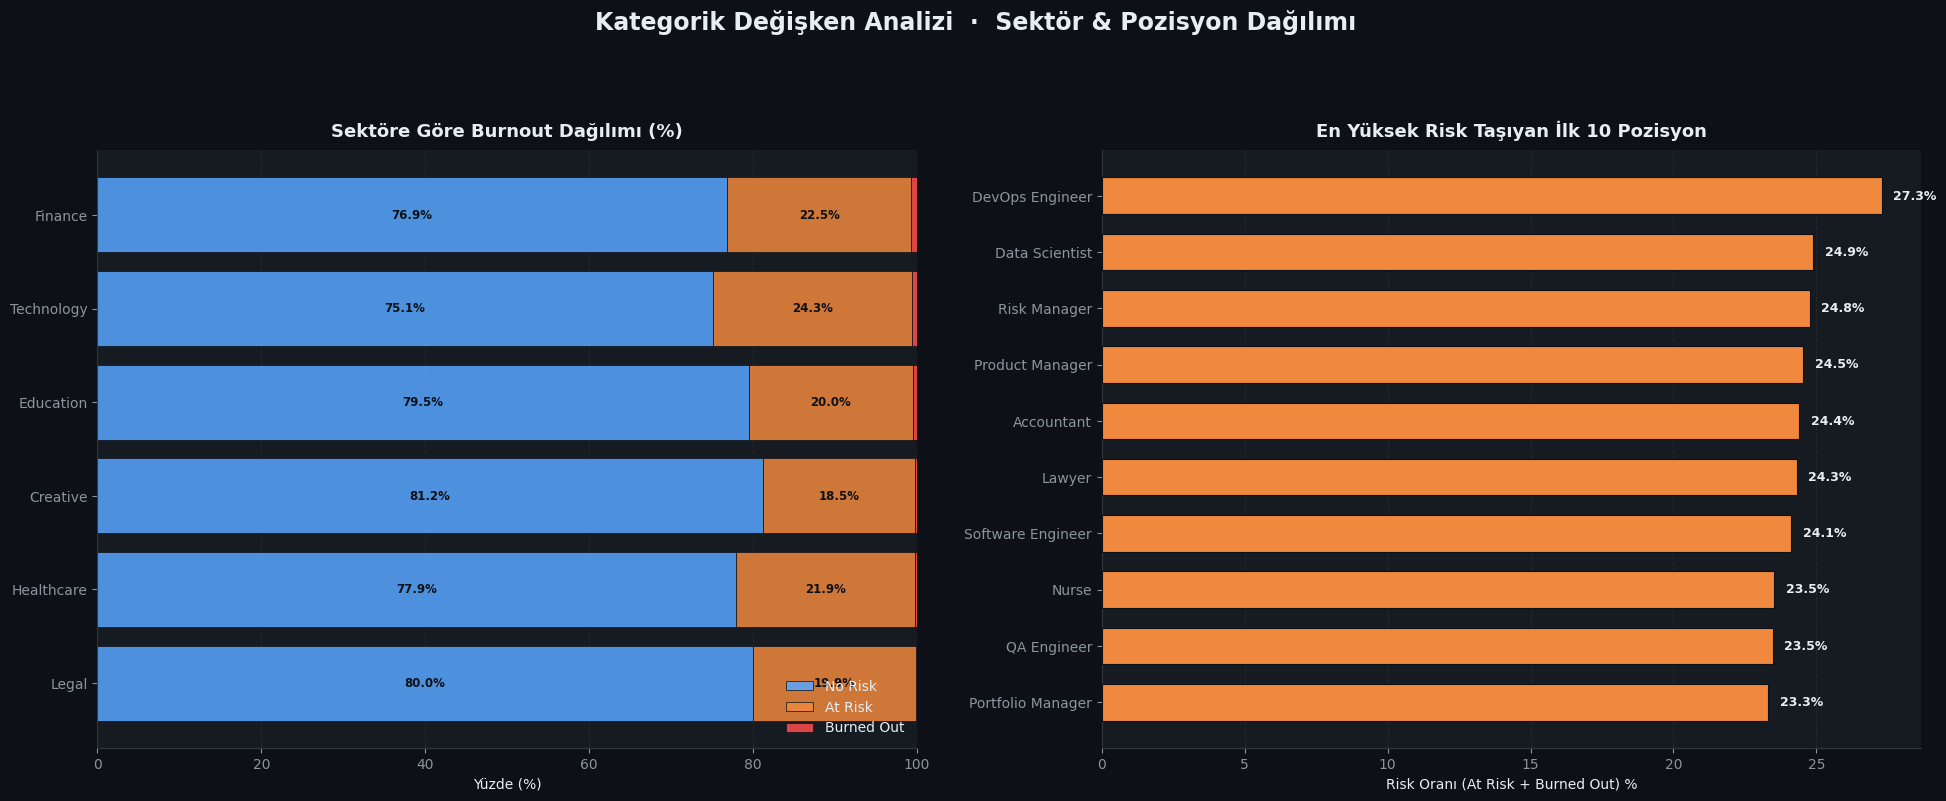

In [17]:
fig6, axes = plt.subplots(1, 2, figsize=(20, 8))
fig6.suptitle("Kategorik Değişken Analizi  ·  Sektör & Pozisyon Dağılımı",
              fontsize=17, fontweight="bold", color=TEXT_PRI, y=1.02)

ax = axes[0]
ind_ct  = (df.groupby(["Industry","Burnout_Label"])
             .size().unstack(fill_value=0)
             .reindex(columns=ORDER))
ind_pct = ind_ct.div(ind_ct.sum(axis=1), axis=0) * 100
ind_pct_sorted = ind_pct.sort_values("Burned Out", ascending=True)

bottom = np.zeros(len(ind_pct_sorted))
for lbl, color in zip(ORDER, PALETTE):
    vals = ind_pct_sorted[lbl].values
    bars = ax.barh(ind_pct_sorted.index, vals, left=bottom,
                   color=color, alpha=0.85, edgecolor=BG,
                   linewidth=0.6, label=lbl)
    for bar, val in zip(bars, vals):
        if val > 4:
            ax.text(bar.get_x() + bar.get_width()/2,
                    bar.get_y() + bar.get_height()/2,
                    f"{val:.1f}%", ha="center", va="center",
                    fontsize=8.5, color=BG, fontweight="bold")
    bottom += vals
ax.set_xlim(0, 100)
ax.set_xlabel("Yüzde (%)", fontsize=10)
ax.set_title("Sektöre Göre Burnout Dağılımı (%)", fontsize=13, fontweight="bold", color=TEXT_PRI, pad=10)
ax.legend(loc="lower right", frameon=False, fontsize=10, labelcolor=TEXT_PRI)
ax.xaxis.grid(True, zorder=0); ax.set_axisbelow(True)

ax2 = axes[1]
role_ct = (df.groupby(["Job_Role","Burnout_Label"])
             .size().unstack(fill_value=0)
             .reindex(columns=ORDER))
role_ct["total"]    = role_ct.sum(axis=1)
role_ct             = role_ct[role_ct["total"] >= 50]
role_ct["risk_pct"] = (role_ct["At Risk"] + role_ct["Burned Out"]) / role_ct["total"] * 100
top10 = role_ct.nlargest(10, "risk_pct").sort_values("risk_pct")

colors_bar = [C3 if v > 30 else C2 if v > 20 else C1 for v in top10["risk_pct"]]
bars = ax2.barh(top10.index, top10["risk_pct"],
                color=colors_bar, edgecolor=BG, linewidth=0.8, height=0.65, zorder=3)
for bar, val in zip(bars, top10["risk_pct"]):
    ax2.text(val + 0.4, bar.get_y() + bar.get_height()/2,
             f"{val:.1f}%", va="center", fontsize=9, color=TEXT_PRI, fontweight="bold")
ax2.set_xlabel("Risk Oranı (At Risk + Burned Out) %", fontsize=10)
ax2.set_title("En Yüksek Risk Taşıyan İlk 10 Pozisyon",
              fontsize=13, fontweight="bold", color=TEXT_PRI, pad=10)
ax2.xaxis.grid(True, zorder=0); ax2.set_axisbelow(True)

plt.tight_layout(pad=2.5)
plt.show()

# ***DEĞİŞKEN ANALİZLERİ***

In [9]:
uni_stats = pd.DataFrame({
    'Mean':   df[num_cols].mean(),
    'Median': df[num_cols].median(),
    'Std':    df[num_cols].std(),
    'Min':    df[num_cols].min(),
    'Max':    df[num_cols].max(),
    'Skew':   df[num_cols].skew(),
    'Kurt':   df[num_cols].kurtosis(),
    'IQR':    df[num_cols].quantile(0.75) - df[num_cols].quantile(0.25)
}).round(3)

print("=== TEKLİ ANALİZ — Merkezi Eğilim & Yayılım ===")
print(uni_stats.to_string())

=== TEKLİ ANALİZ — Merkezi Eğilim & Yayılım ===
                          Mean  Median     Std    Min     Max   Skew   Kurt     IQR
Age                     35.228   35.00   7.652  22.00   60.00  0.243 -0.365  10.000
Years_Experience        12.807   12.50   7.703   0.00   35.00  0.300 -0.423  10.900
AI_Tools_Used_Daily      4.279    4.00   2.303   0.00   10.00 -0.037 -0.782   4.000
AI_Hours_Per_Day         3.249    3.30   1.725   0.00    8.00  0.025 -0.669   2.800
AI_Adoption_Level        1.636    2.00   1.038   0.00    3.00 -0.138 -1.156   2.000
Perceived_Usefulness     7.058    7.00   2.482   1.00   10.00 -0.489 -0.739   4.000
Skill_Anxiety_Score      4.782    5.00   2.069   1.00   10.00  0.623  0.246   3.000
Work_Hours_Per_Week     46.565   46.55   8.190  25.00   74.30  0.004 -0.116  10.900
Meetings_Per_Week        8.615    8.00   3.170   1.00   22.00  0.437  0.123   5.000
Deep_Work_Hours          3.155    3.20   1.246   0.50    7.40  0.079 -0.258   1.700
Interruptions_Per_Day   13.4

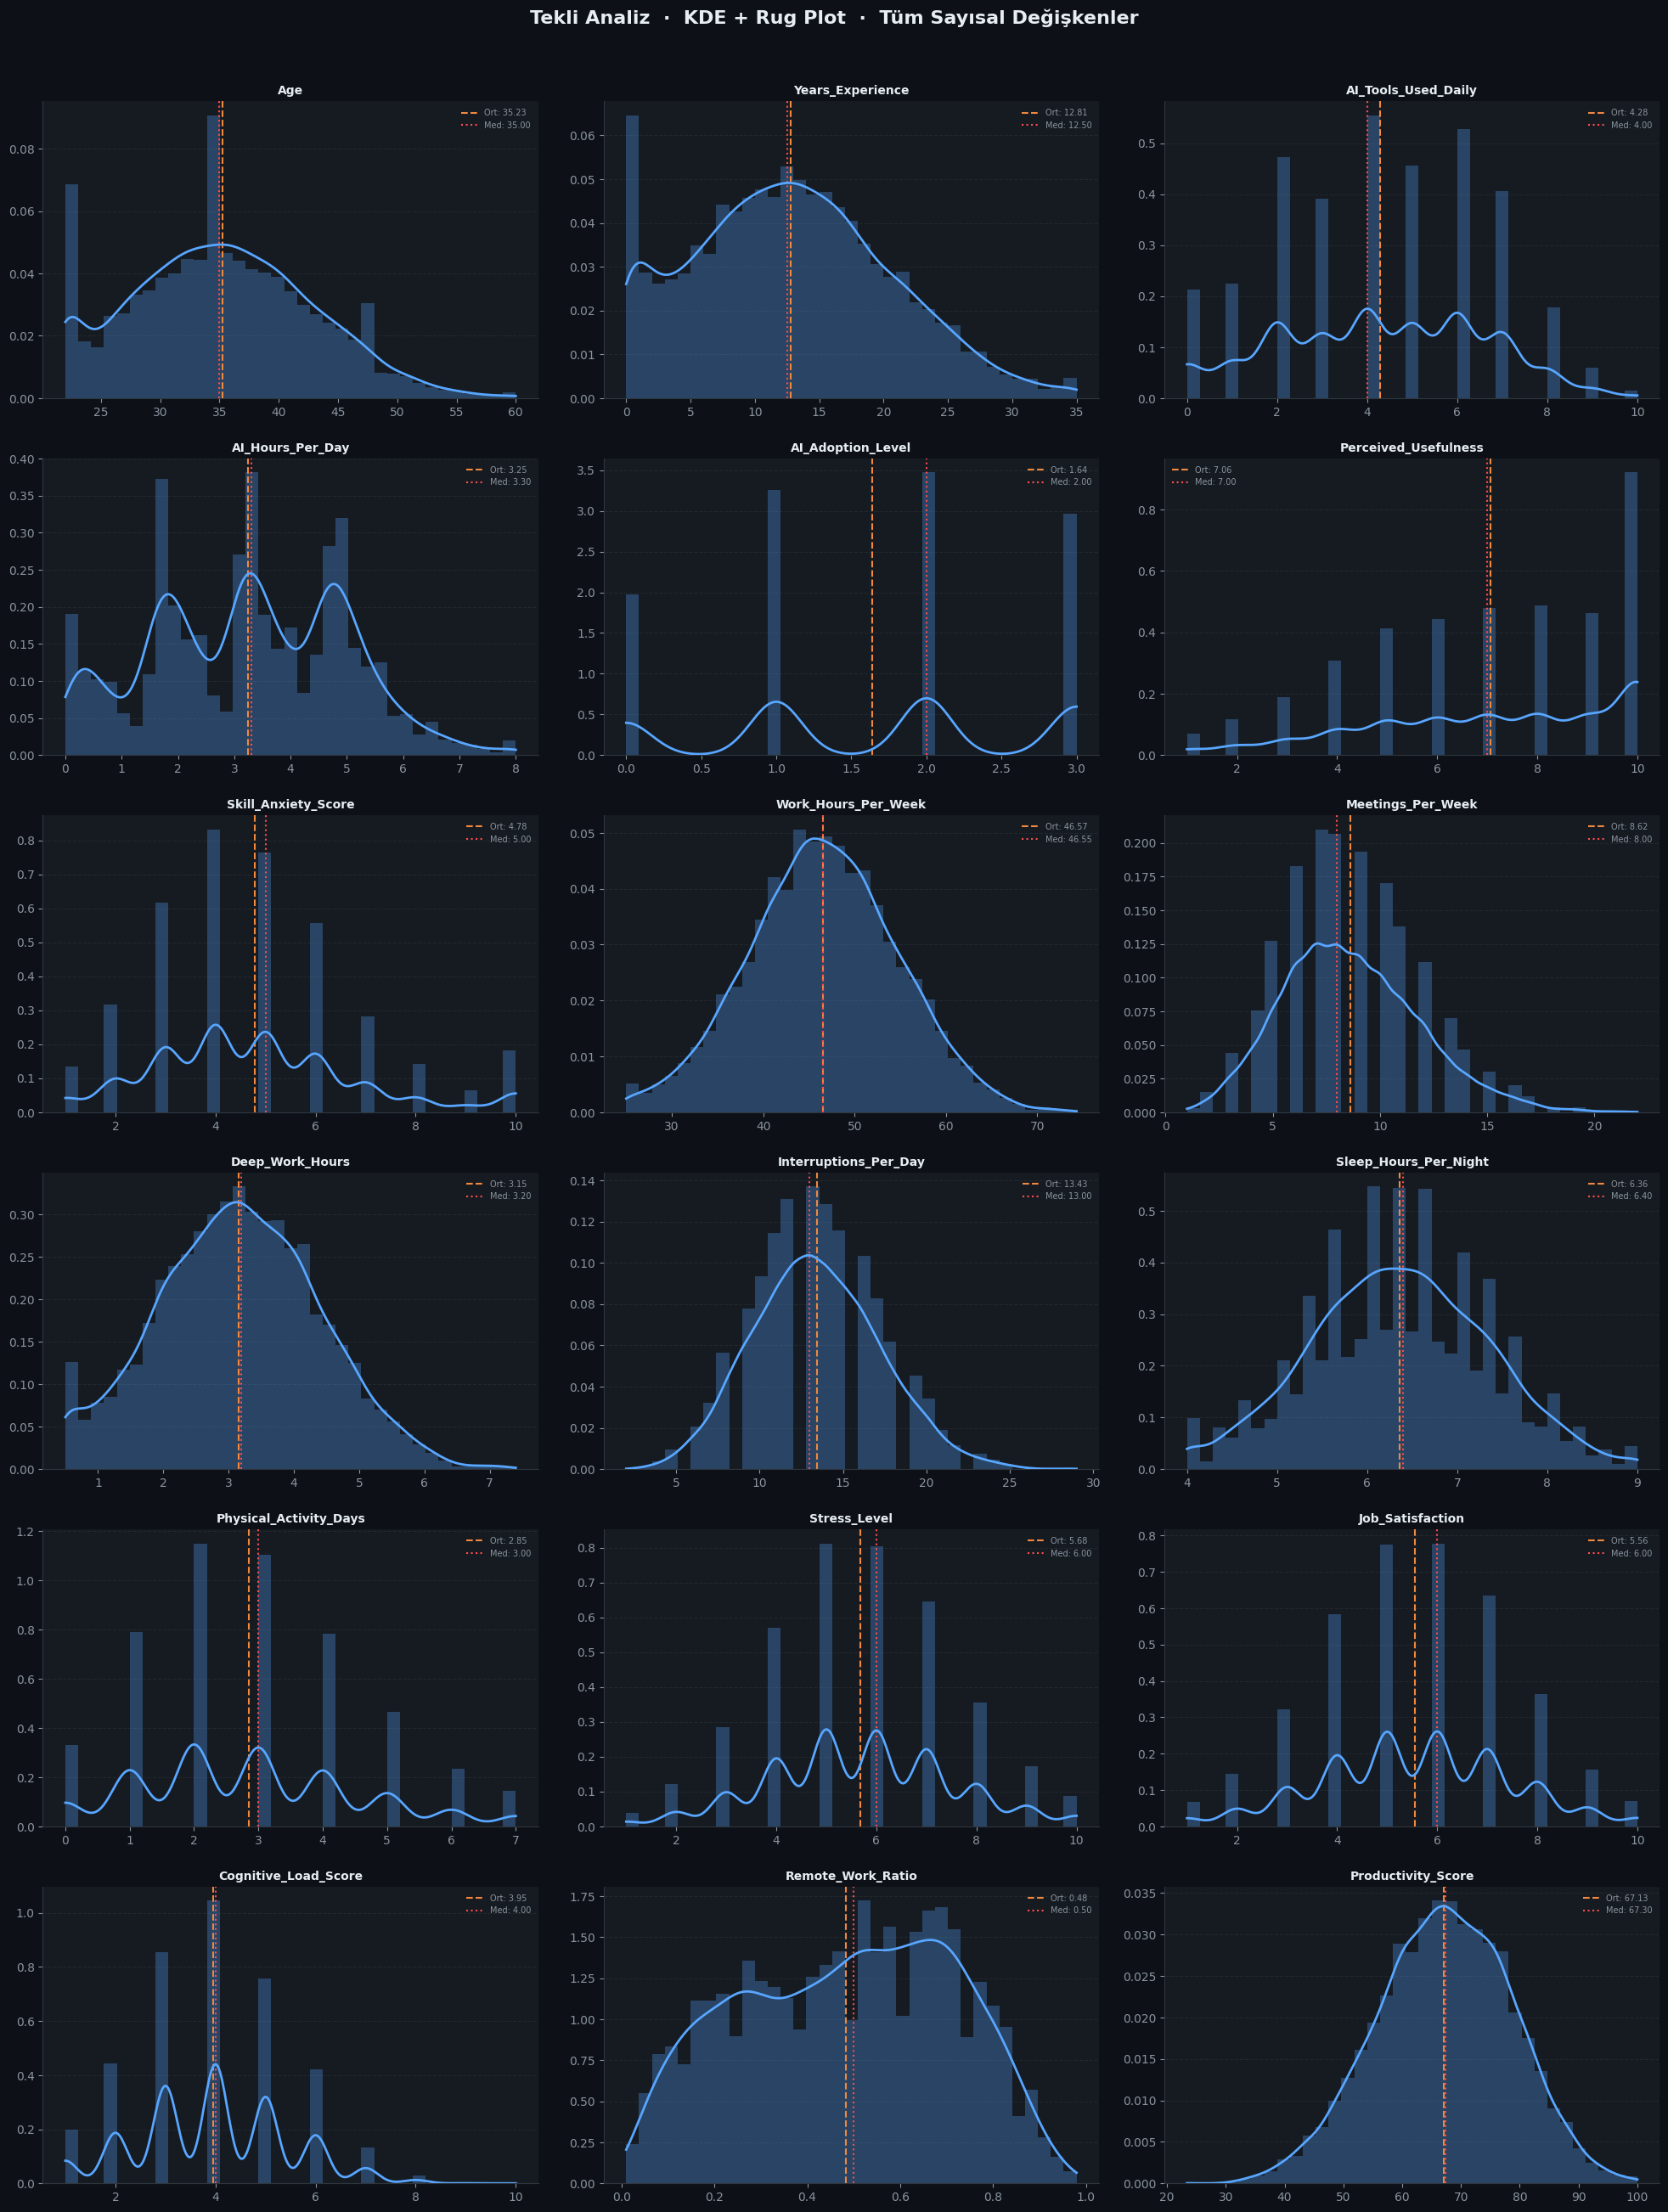

In [12]:
fig, axes = plt.subplots(6, 3, figsize=(20, 26))
fig.suptitle("Tekli Analiz  ·  KDE + Rug Plot  ·  Tüm Sayısal Değişkenler",
             fontsize=16, fontweight="bold", color=TEXT_PRI, y=1.005)
axes = axes.flatten()

for i, col in enumerate(num_cols):
    ax = axes[i]
    ax.hist(df[col], bins=35, color=C1, alpha=0.3, density=True, zorder=2)
    kde_x = np.linspace(df[col].min(), df[col].max(), 400)
    kde   = stats.gaussian_kde(df[col])
    ax.plot(kde_x, kde(kde_x), color=C1, lw=2, zorder=3)
    ax.axvline(df[col].mean(),   color=C2, lw=1.5, ls="--", label=f"Ort: {df[col].mean():.2f}")
    ax.axvline(df[col].median(), color=C3, lw=1.5, ls=":",  label=f"Med: {df[col].median():.2f}")
    ax.set_title(col, fontsize=10, fontweight="bold", color=TEXT_PRI)
    ax.legend(fontsize=7, frameon=False, labelcolor=TEXT_SEC)
    ax.yaxis.grid(True, zorder=0); ax.set_axisbelow(True)

plt.tight_layout(pad=2)
plt.show()

In [13]:
print("=== İKİLİ ANALİZ — Sınıfa Göre Grup İstatistikleri ===\n")
group_stats = df.groupby("Burnout_Label")[num_cols].agg(['mean','median','std']).round(3)
print(group_stats.to_string())

=== İKİLİ ANALİZ — Sınıfa Göre Grup İstatistikleri ===

                  Age               Years_Experience               AI_Tools_Used_Daily               AI_Hours_Per_Day               AI_Adoption_Level               Perceived_Usefulness               Skill_Anxiety_Score               Work_Hours_Per_Week               Meetings_Per_Week               Deep_Work_Hours               Interruptions_Per_Day               Sleep_Hours_Per_Night               Physical_Activity_Days               Stress_Level               Job_Satisfaction               Cognitive_Load_Score               Remote_Work_Ratio               Productivity_Score               
                 mean median    std             mean median    std                mean median    std             mean median    std              mean median    std                 mean median    std                mean median    std                mean median    std              mean median    std            mean median    std                  m

In [18]:
print("\n=== ANOVA Testi (sınıflar arası fark anlamlılığı) ===")
print(f"{'Değişken':<30} {'F-stat':>10} {'p-value':>12} {'Anlamlı?':>12}")
print("-" * 68)
groups = {lbl: df[df["Burnout_Label"]==lbl] for lbl in ORDER}
for col in num_cols:
    f, p = stats.f_oneway(*[groups[lbl][col].values for lbl in ORDER])
    sig = "✓ Evet (p<0.05)" if p < 0.05 else "✗ Hayır"
    print(f"{col:<30} {f:>10.3f} {p:>12.4f} {sig:>12}")


=== ANOVA Testi (sınıflar arası fark anlamlılığı) ===
Değişken                           F-stat      p-value     Anlamlı?
--------------------------------------------------------------------
Age                               125.124       0.0000 ✓ Evet (p<0.05)
Years_Experience                  122.900       0.0000 ✓ Evet (p<0.05)
AI_Tools_Used_Daily                 8.197       0.0003 ✓ Evet (p<0.05)
AI_Hours_Per_Day                    2.012       0.1338      ✗ Hayır
AI_Adoption_Level                  10.132       0.0000 ✓ Evet (p<0.05)
Perceived_Usefulness               31.816       0.0000 ✓ Evet (p<0.05)
Skill_Anxiety_Score               479.166       0.0000 ✓ Evet (p<0.05)
Work_Hours_Per_Week               371.559       0.0000 ✓ Evet (p<0.05)
Meetings_Per_Week                   1.117       0.3272      ✗ Hayır
Deep_Work_Hours                    33.826       0.0000 ✓ Evet (p<0.05)
Interruptions_Per_Day              97.082       0.0000 ✓ Evet (p<0.05)
Sleep_Hours_Per_Night            

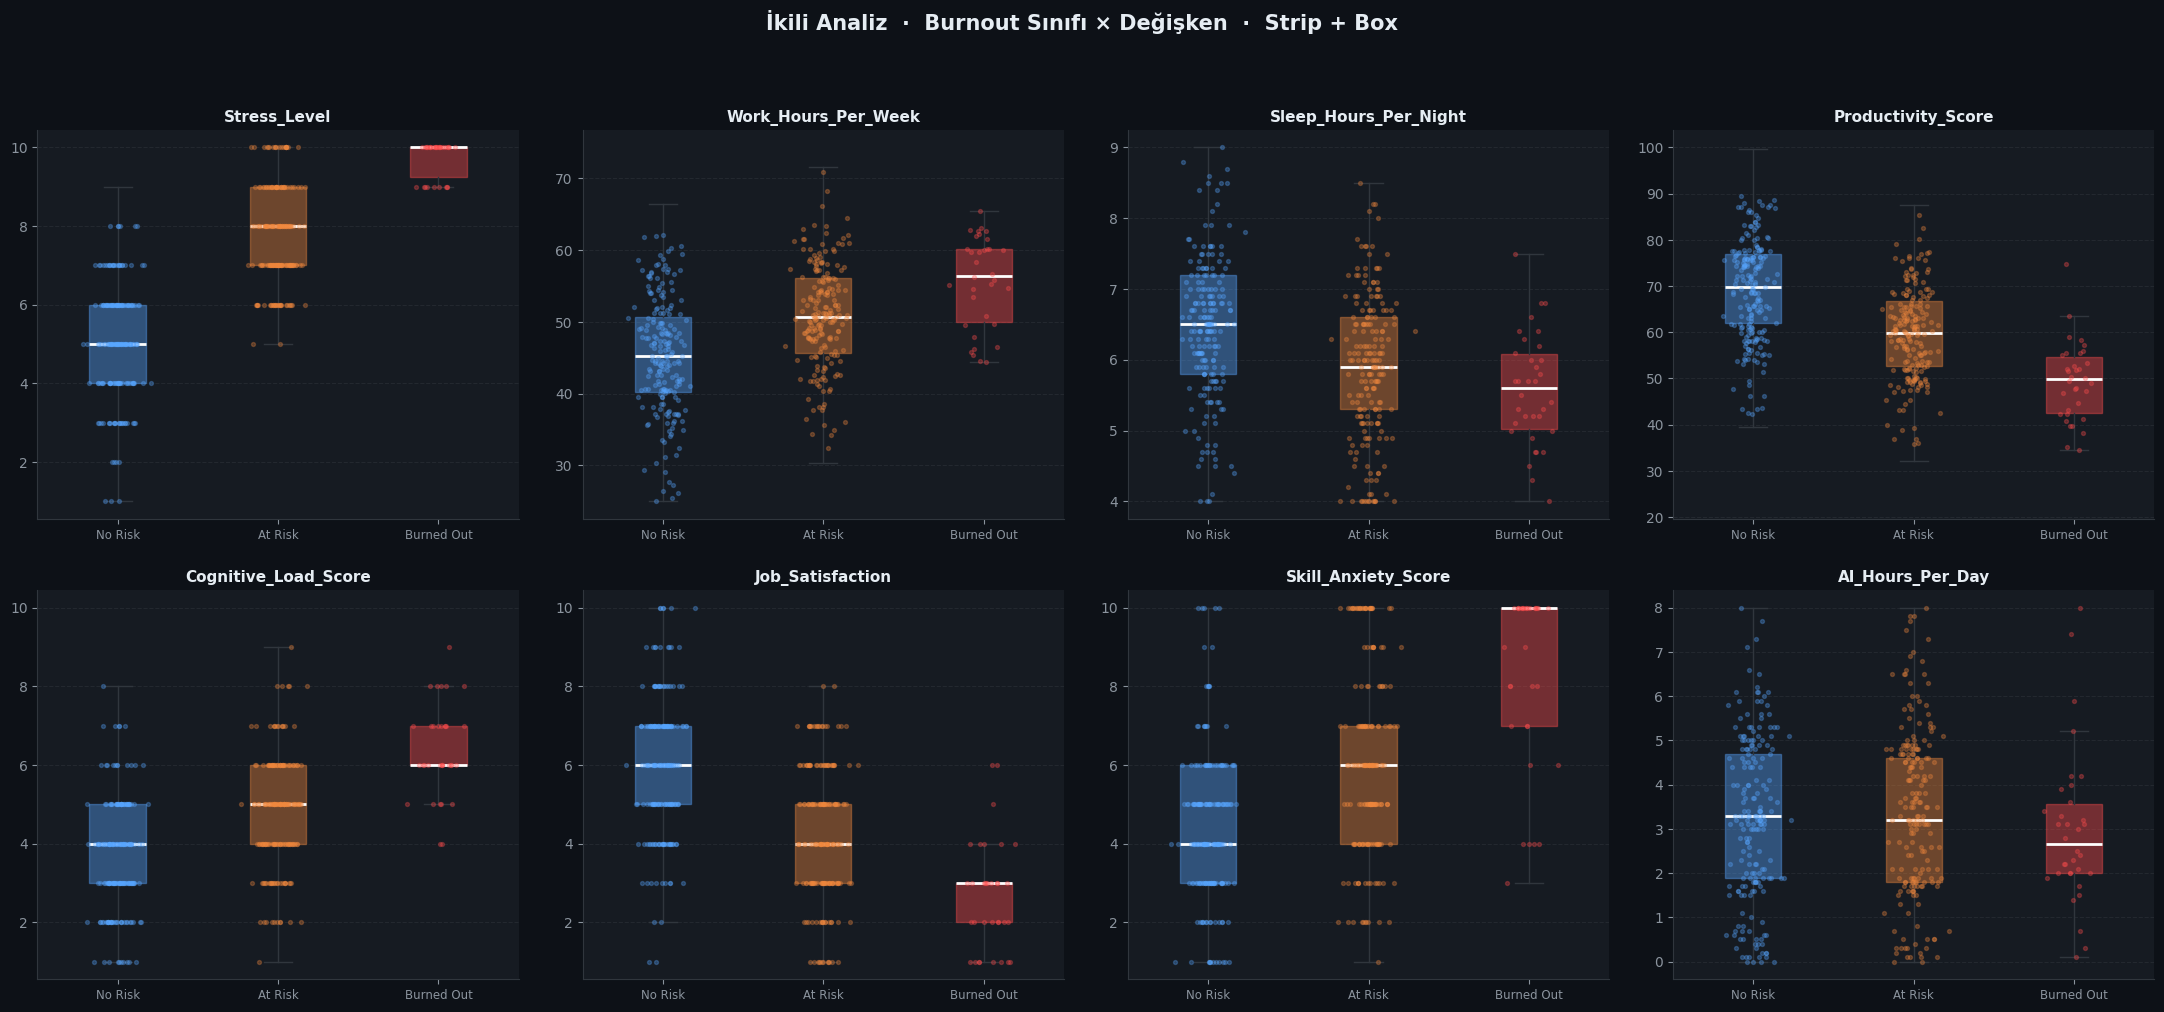

In [19]:
key_cols = ['Stress_Level','Work_Hours_Per_Week','Sleep_Hours_Per_Night',
            'Productivity_Score','Cognitive_Load_Score','Job_Satisfaction',
            'Skill_Anxiety_Score','AI_Hours_Per_Day']

fig, axes = plt.subplots(2, 4, figsize=(22, 10))
fig.suptitle("İkili Analiz  ·  Burnout Sınıfı × Değişken  ·  Strip + Box",
             fontsize=15, fontweight="bold", color=TEXT_PRI, y=1.02)
axes = axes.flatten()

for i, col in enumerate(key_cols):
    ax = axes[i]
    # box
    bp = ax.boxplot(
        [groups[lbl][col].values for lbl in ORDER],
        positions=[1,2,3], patch_artist=True, widths=0.35,
        medianprops=dict(color="white", lw=2),
        whiskerprops=dict(color=BORDER), capprops=dict(color=BORDER),
        flierprops=dict(marker="", alpha=0)
    )
    for patch, color in zip(bp['boxes'], PALETTE):
        patch.set_facecolor(color); patch.set_alpha(0.4); patch.set_edgecolor(color)
    # strip
    for j, (lbl, color) in enumerate(zip(ORDER, PALETTE)):
        sub = groups[lbl][col].values
        jit = np.random.normal(j+1, 0.07, size=min(200, len(sub)))
        smp = np.random.choice(sub, size=min(200, len(sub)), replace=False)
        ax.scatter(jit, smp, s=8, alpha=0.3, color=color, zorder=4)
    ax.set_xticks([1,2,3])
    ax.set_xticklabels(["No Risk","At Risk","Burned Out"], fontsize=8.5, color=TEXT_SEC)
    ax.set_title(col, fontsize=11, fontweight="bold", color=TEXT_PRI)
    ax.yaxis.grid(True, zorder=0); ax.set_axisbelow(True)

plt.tight_layout(pad=2)
plt.show()

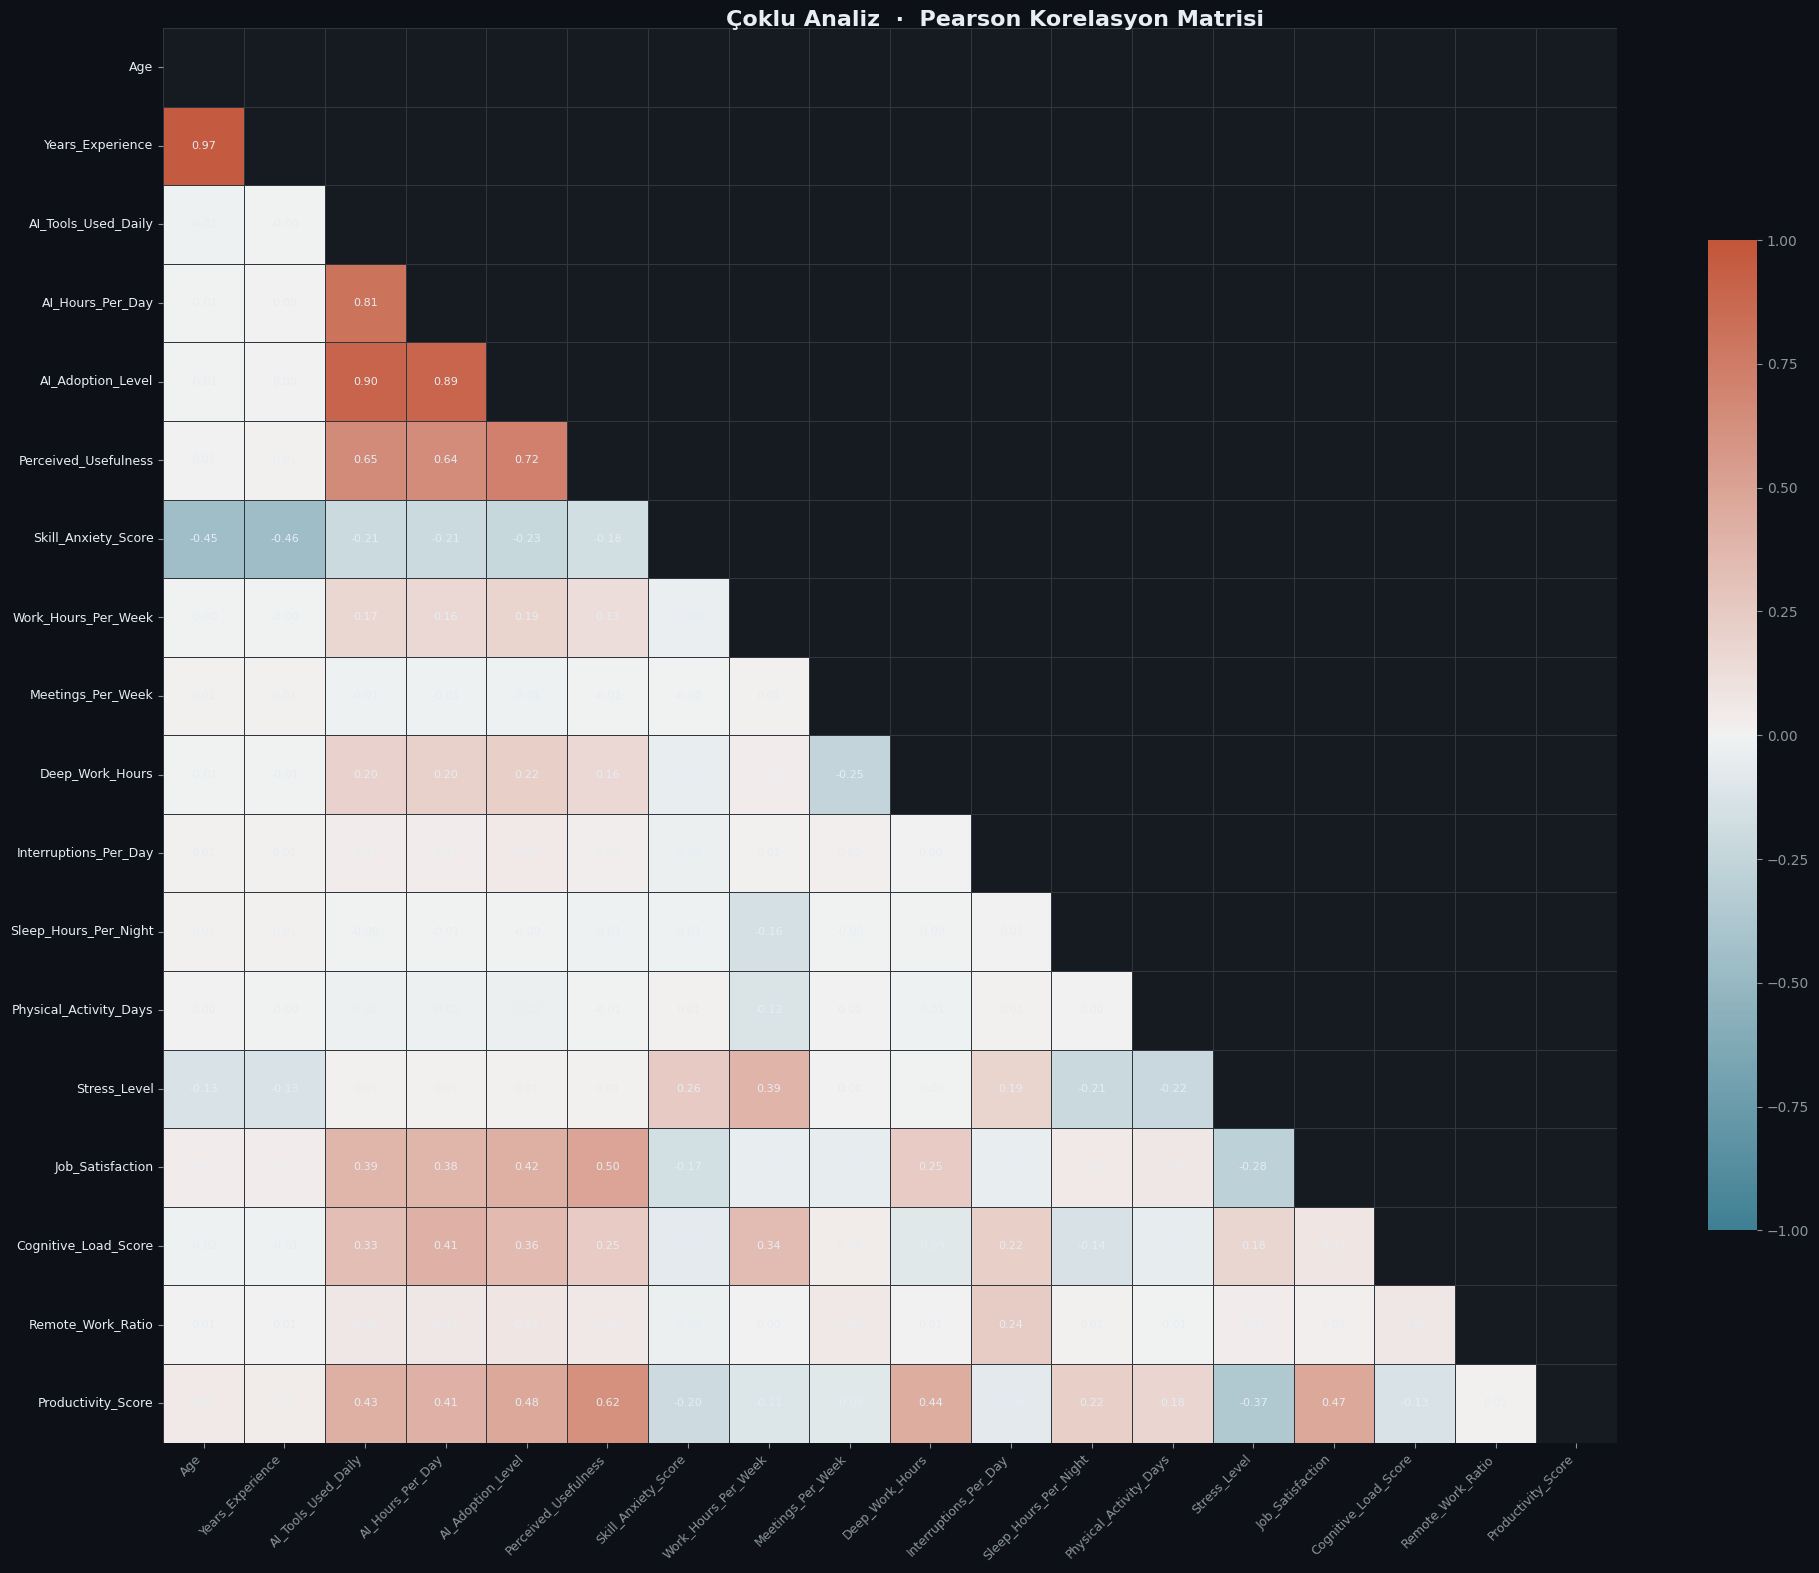

In [21]:
# ÇOKLU ANALİZ
corr = df[num_cols].corr()

fig, ax = plt.subplots(figsize=(20, 16))
fig.suptitle("Çoklu Analiz  ·  Pearson Korelasyon Matrisi",
             fontsize=16, fontweight="bold", color=TEXT_PRI)

mask = np.triu(np.ones_like(corr, dtype=bool))
cmap = sns.diverging_palette(220, 20, as_cmap=True)
sns.heatmap(corr, mask=mask, ax=ax, cmap=cmap, center=0,
            vmin=-1, vmax=1, annot=True, fmt=".2f",
            linewidths=0.4, linecolor=BORDER,
            annot_kws={"size": 8, "color": TEXT_PRI},
            cbar_kws={"shrink": 0.7})
ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha="right",
                   fontsize=9, color=TEXT_SEC)
ax.set_yticklabels(ax.get_yticklabels(), fontsize=9, color=TEXT_PRI)
plt.tight_layout()
plt.show()

In [22]:
print("\n=== Güçlü Korelasyon Çiftleri (|r| > 0.30) ===")
print(f"{'Değişken 1':<28} {'Değişken 2':<28} {'r':>8}")
print("-" * 68)
corr_pairs = (corr.where(np.tril(np.ones(corr.shape), k=-1).astype(bool))
                  .stack()
                  .reset_index())
corr_pairs.columns = ["Var1","Var2","r"]
corr_pairs = corr_pairs[corr_pairs["r"].abs() > 0.30].sort_values("r", ascending=False)
for _, row in corr_pairs.iterrows():
    print(f"{row['Var1']:<28} {row['Var2']:<28} {row['r']:>8.3f}")


=== Güçlü Korelasyon Çiftleri (|r| > 0.30) ===
Değişken 1                   Değişken 2                          r
--------------------------------------------------------------------
Years_Experience             Age                             0.969
AI_Adoption_Level            AI_Tools_Used_Daily             0.904
AI_Adoption_Level            AI_Hours_Per_Day                0.893
AI_Hours_Per_Day             AI_Tools_Used_Daily             0.808
Perceived_Usefulness         AI_Adoption_Level               0.721
Perceived_Usefulness         AI_Tools_Used_Daily             0.650
Perceived_Usefulness         AI_Hours_Per_Day                0.643
Productivity_Score           Perceived_Usefulness            0.618
Job_Satisfaction             Perceived_Usefulness            0.500
Productivity_Score           AI_Adoption_Level               0.476
Productivity_Score           Job_Satisfaction                0.470
Productivity_Score           Deep_Work_Hours                 0.443
Productivity

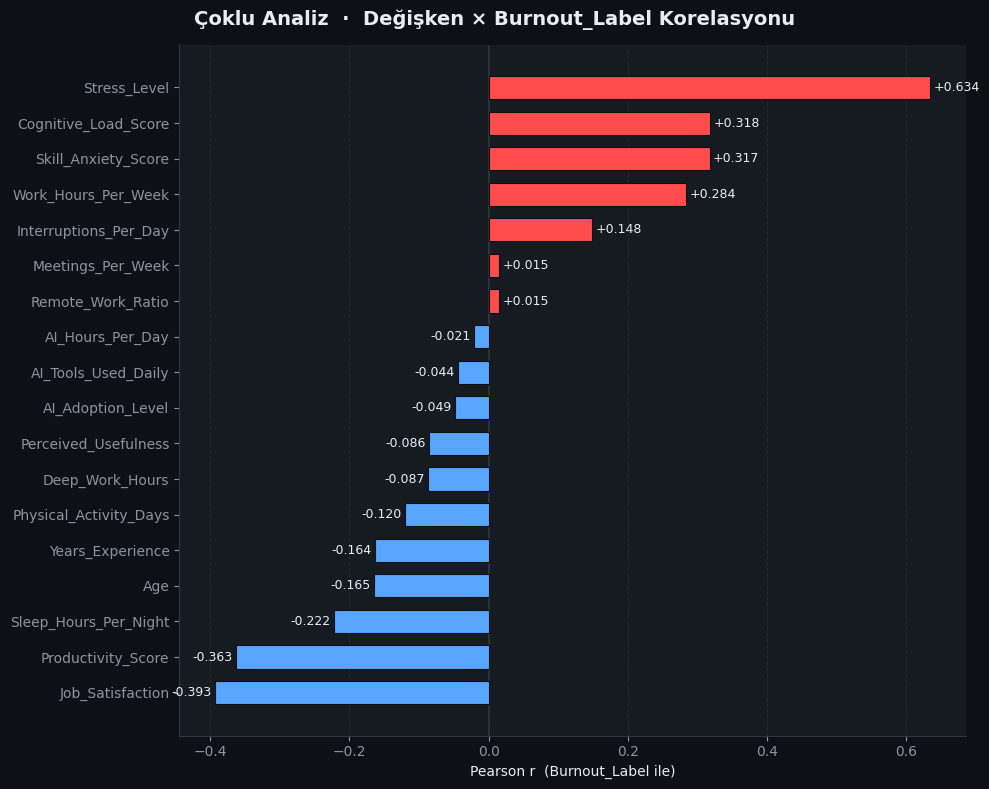

In [23]:
#Hedef değişken ile korelasyon
label_enc = df["Burnout_Label"].map({"No Risk": 0, "At Risk": 1, "Burned Out": 2})
target_corr = df[num_cols].corrwith(label_enc).sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(10, 8))
fig.suptitle("Çoklu Analiz  ·  Değişken × Burnout_Label Korelasyonu",
             fontsize=14, fontweight="bold", color=TEXT_PRI)
colors = [C3 if v > 0 else C1 for v in target_corr.values]
bars = ax.barh(target_corr.index, target_corr.values,
               color=colors, edgecolor=BG, linewidth=0.8, height=0.65, zorder=3)
ax.axvline(0, color=BORDER, lw=1.2)
for bar, val in zip(bars, target_corr.values):
    ax.text(val + (0.005 if val>=0 else -0.005),
            bar.get_y() + bar.get_height()/2,
            f"{val:+.3f}", va="center",
            ha="left" if val>=0 else "right",
            fontsize=9, color=TEXT_PRI)
ax.set_xlabel("Pearson r  (Burnout_Label ile)", fontsize=10)
ax.xaxis.grid(True, zorder=0); ax.set_axisbelow(True)
ax.invert_yaxis()
plt.tight_layout()
plt.show()

<Figure size 1800x1600 with 0 Axes>

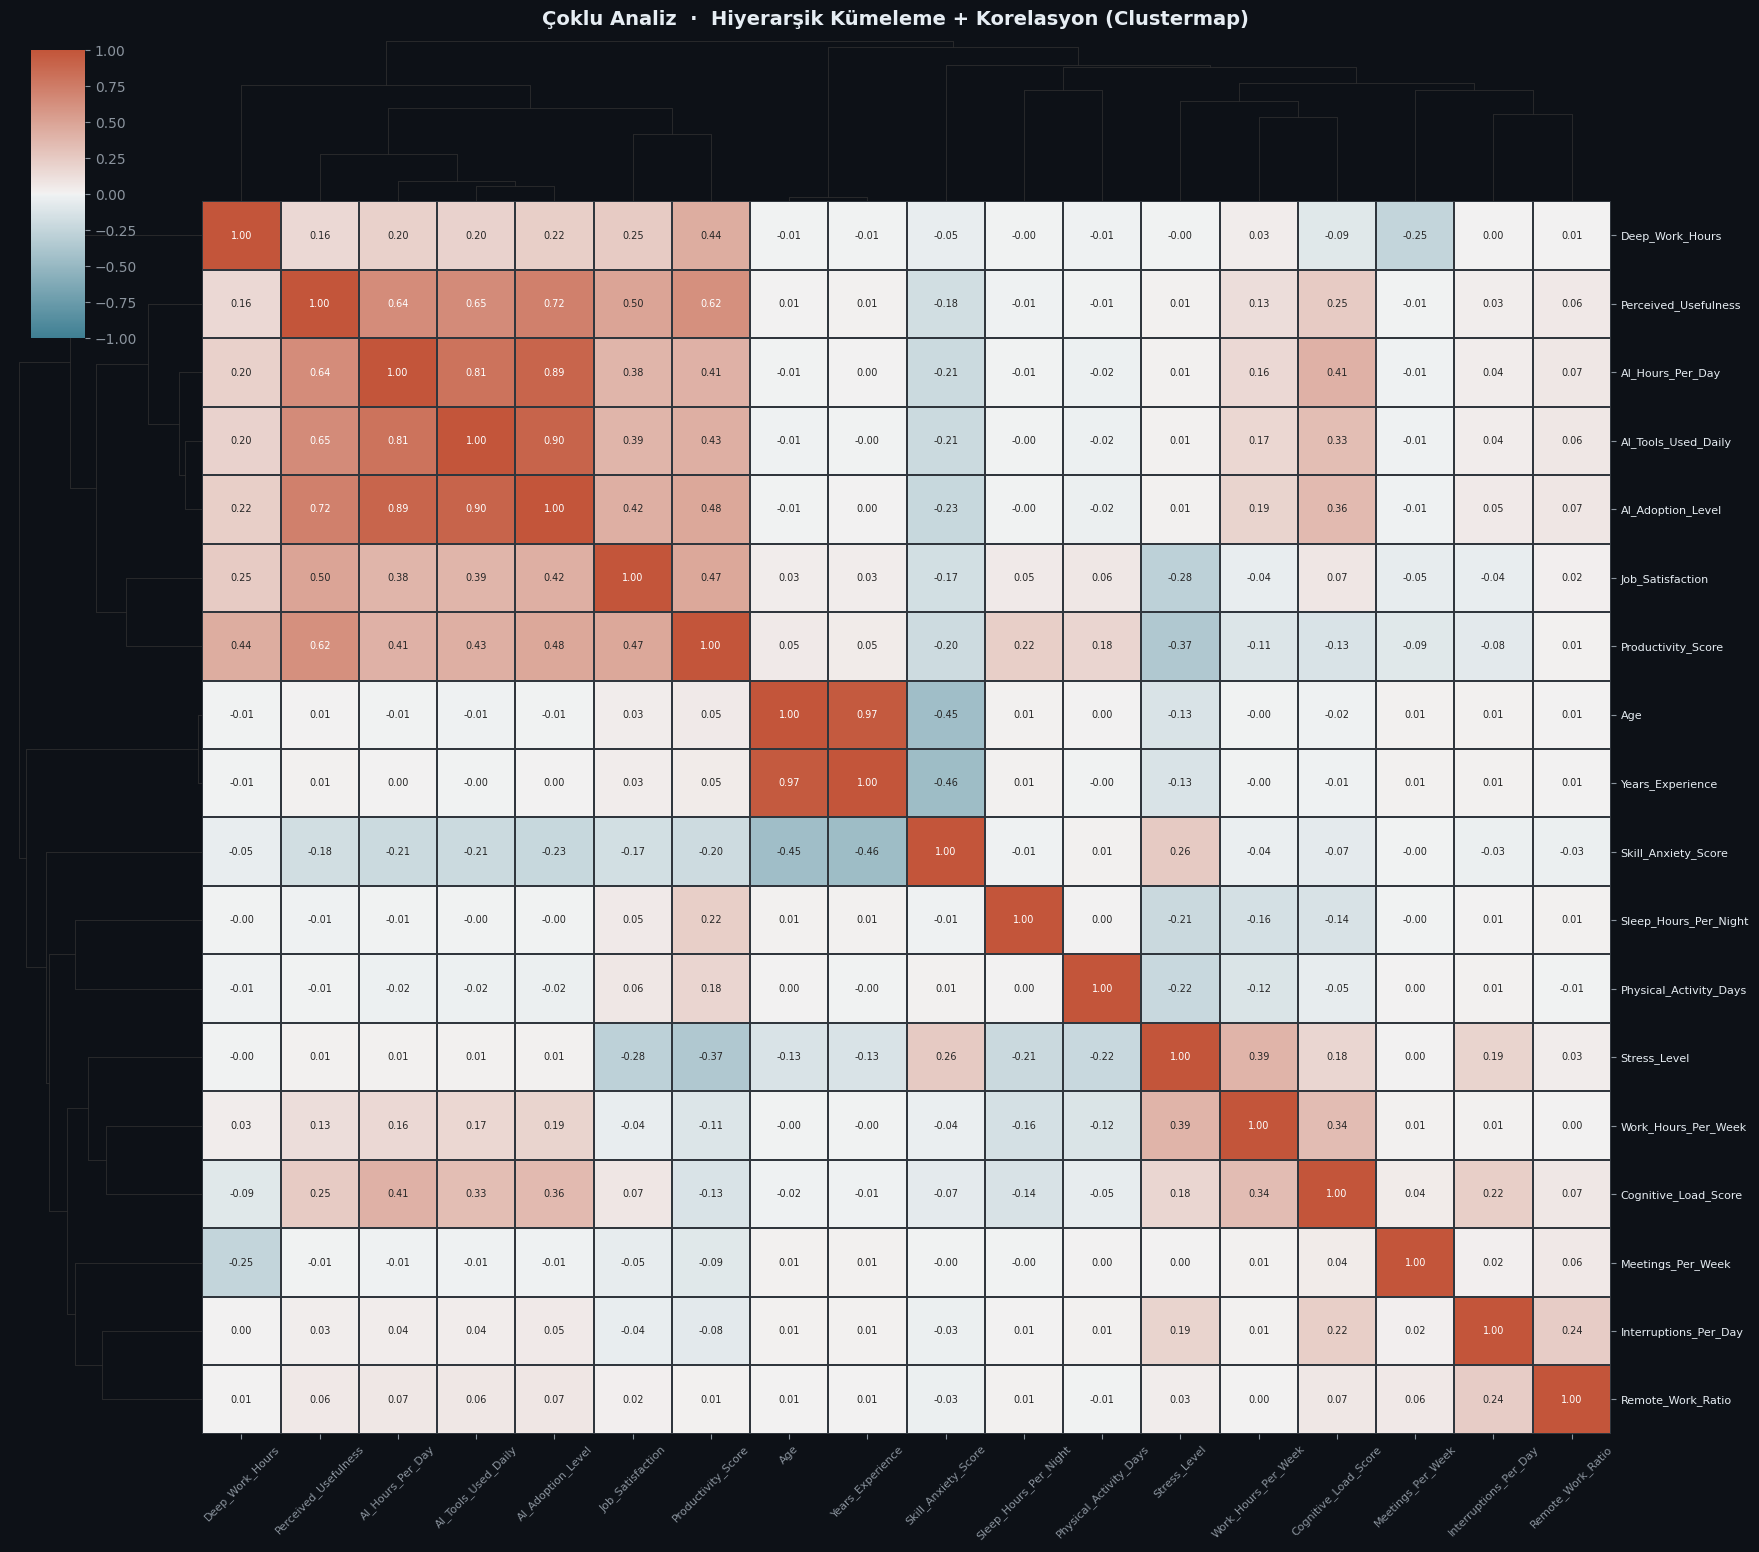

In [ ]:
# — 4) Clustermap (hiyerarşik kümeleme + korelasyon) —
fig = plt.figure(figsize=(18, 16))
cg = sns.clustermap(corr, cmap=sns.diverging_palette(220, 20, as_cmap=True),
                    center=0, vmin=-1, vmax=1,
                    annot=True, fmt=".2f",
                    linewidths=0.3, linecolor=BORDER,
                    annot_kws={"size": 7},
                    figsize=(18, 16),
                    dendrogram_ratio=0.12,
                    cbar_pos=(0.02, 0.8, 0.03, 0.18))
cg.fig.patch.set_facecolor(BG)
cg.ax_heatmap.set_facecolor(PANEL)
cg.ax_heatmap.tick_params(axis='x', labelcolor=TEXT_SEC, labelsize=8, rotation=45)
cg.ax_heatmap.tick_params(axis='y', labelcolor=TEXT_PRI, labelsize=8)
cg.fig.suptitle("Çoklu Analiz  ·  Hiyerarşik Kümeleme + Korelasyon (Clustermap)",
                fontsize=14, fontweight="bold", color=TEXT_PRI, y=1.005)
plt.show()

# ***EKSİK VE AYKIRI DEĞERLER ANALİZİ***

Text(0.5, 0.98, 'Eksik Değer Analizi  ·  Heatmap & Özet')

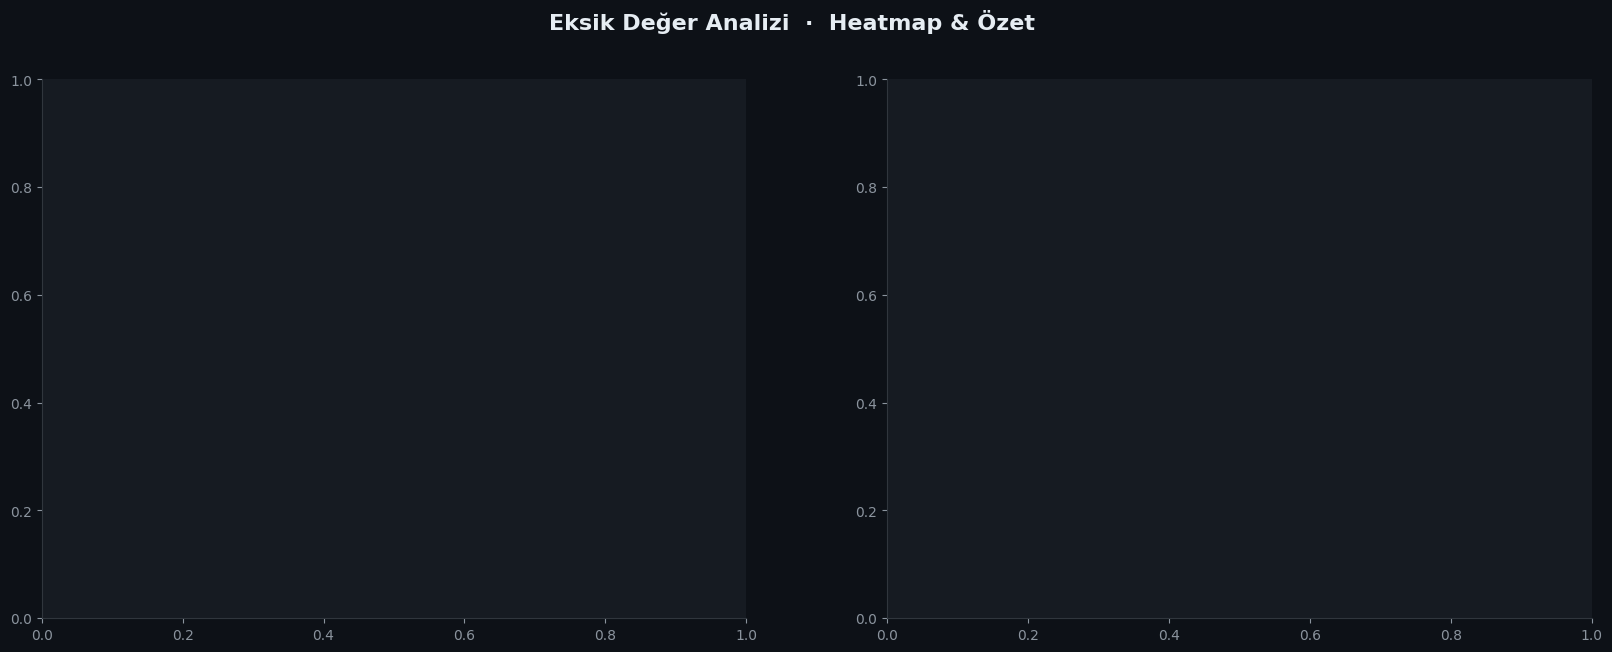

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(20, 7))
fig.suptitle("Eksik Değer Analizi  ·  Heatmap & Özet",
             fontsize=16, fontweight="bold", color=TEXT_PRI)

In [24]:
# AYKIRI DEĞER ANALİZİ — IQR Yöntemi
Q1  = df[num_cols].quantile(0.25)
Q3  = df[num_cols].quantile(0.75)
IQR = Q3 - Q1

lower_iqr = Q1 - 1.5 * IQR
upper_iqr = Q3 + 1.5 * IQR

outlier_iqr = ((df[num_cols] < lower_iqr) | (df[num_cols] > upper_iqr))

iqr_report = pd.DataFrame({
    'Alt Sınır (IQR)': lower_iqr.round(3),
    'Üst Sınır (IQR)': upper_iqr.round(3),
    'Aykırı Sayı':     outlier_iqr.sum(),
    'Aykırı %':        (outlier_iqr.sum() / len(df) * 100).round(2)
})

print("=== IQR AYKIRI DEĞER RAPORU ===")
print(iqr_report.to_string())

=== IQR AYKIRI DEĞER RAPORU ===
                        Alt Sınır (IQR)  Üst Sınır (IQR)  Aykırı Sayı  Aykırı %
Age                              15.000           55.000           46      0.54
Years_Experience                 -9.250           34.350           32      0.38
AI_Tools_Used_Daily              -4.000           12.000            0      0.00
AI_Hours_Per_Day                 -2.300            8.900            0      0.00
AI_Adoption_Level                -2.000            6.000            0      0.00
Perceived_Usefulness             -1.000           15.000            0      0.00
Skill_Anxiety_Score              -1.500           10.500            0      0.00
Work_Hours_Per_Week              24.750           68.350           25      0.29
Meetings_Per_Week                -1.500           18.500           31      0.36
Deep_Work_Hours                  -0.250            6.550           28      0.33
Interruptions_Per_Day             3.500           23.500           67      0.79
Sleep_Ho

In [25]:
# AYKIRI DEĞER ANALİZİ — Z-Score Yöntemi

z_scores    = np.abs(stats.zscore(df[num_cols]))
outlier_z = pd.DataFrame(z_scores > 3, columns=num_cols)

z_report = pd.DataFrame({
    'Aykırı Sayı (Z>3)': outlier_z.sum(),
    'Aykırı % (Z>3)':    (outlier_z.sum() / len(df) * 100).round(2),
    'Max Z-Score':        z_scores.max(axis=0).round(3)
})

print("=== Z-SCORE AYKIRI DEĞER RAPORU (|z| > 3) ===")
print(z_report.to_string())

=== Z-SCORE AYKIRI DEĞER RAPORU (|z| > 3) ===
                        Aykırı Sayı (Z>3)  Aykırı % (Z>3)  Max Z-Score
Age                                    17            0.20        3.238
Years_Experience                        0            0.00        2.881
AI_Tools_Used_Daily                     0            0.00        2.484
AI_Hours_Per_Day                        0            0.00        2.754
AI_Adoption_Level                       0            0.00        1.576
Perceived_Usefulness                    0            0.00        2.441
Skill_Anxiety_Score                     0            0.00        2.522
Work_Hours_Per_Week                    10            0.12        3.387
Meetings_Per_Week                      31            0.36        4.223
Deep_Work_Hours                        19            0.22        3.408
Interruptions_Per_Day                  27            0.32        4.073
Sleep_Hours_Per_Night                   0            0.00        2.661
Physical_Activity_Days         

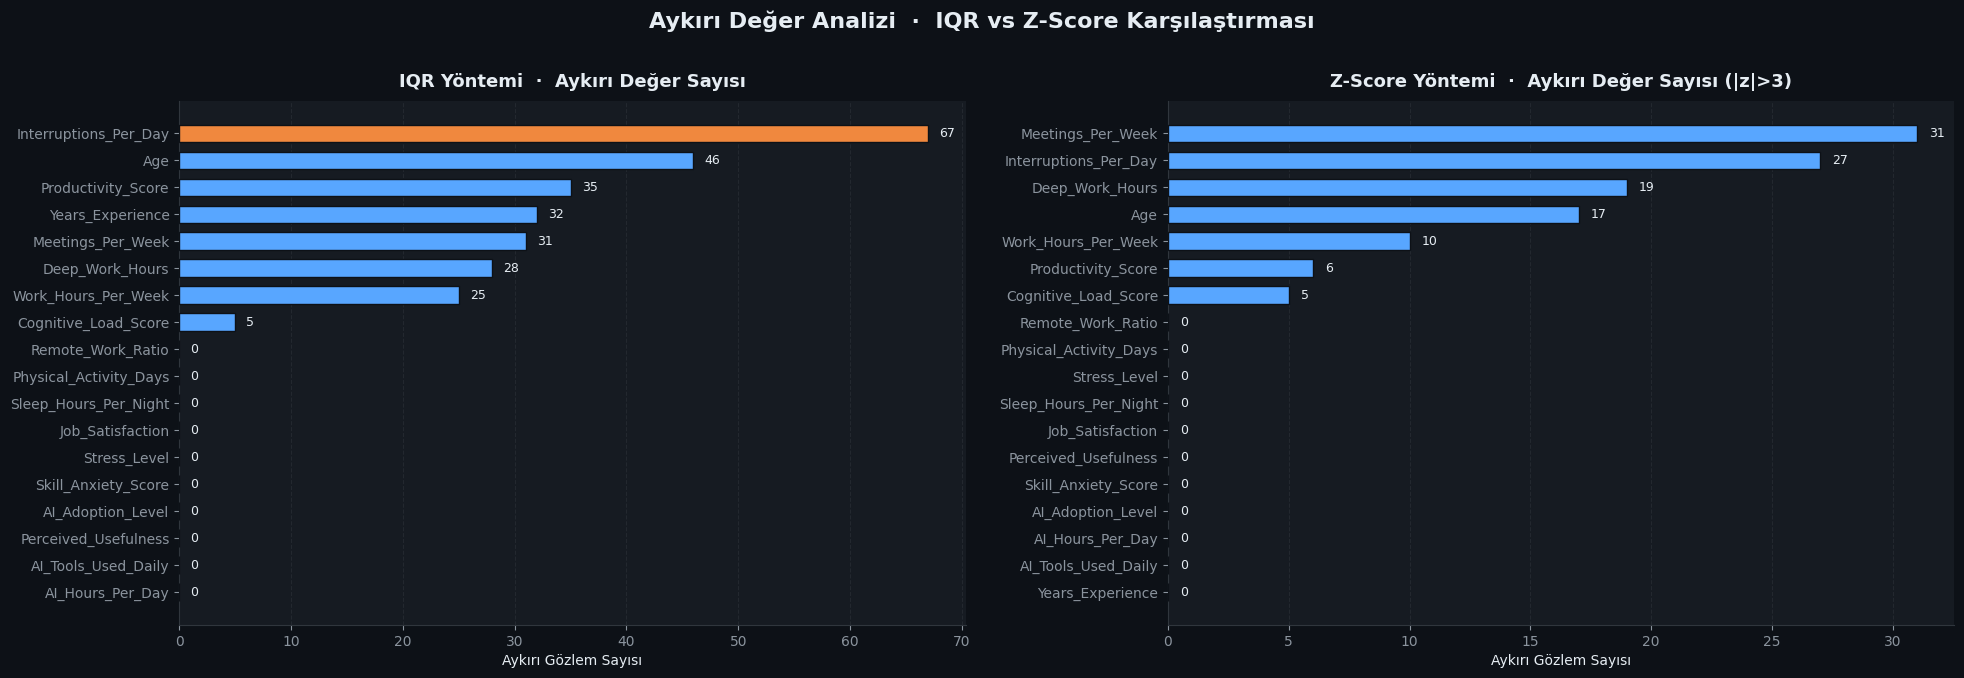

In [26]:
# — IQR vs Z-Score karşılaştırma görseli —
fig, axes = plt.subplots(1, 2, figsize=(20, 7))
fig.suptitle("Aykırı Değer Analizi  ·  IQR vs Z-Score Karşılaştırması",
             fontsize=16, fontweight="bold", color=TEXT_PRI)

# IQR aykırı sayı
ax1 = axes[0]
iqr_sorted = outlier_iqr.sum().sort_values(ascending=True)
colors1 = [C3 if v > 100 else C2 if v > 50 else C1 for v in iqr_sorted.values]
bars1 = ax1.barh(iqr_sorted.index, iqr_sorted.values,
                 color=colors1, edgecolor=BG, height=0.65, zorder=3)
for bar, val in zip(bars1, iqr_sorted.values):
    ax1.text(val + 1, bar.get_y() + bar.get_height()/2,
             str(val), va="center", fontsize=9, color=TEXT_PRI)
ax1.set_title("IQR Yöntemi  ·  Aykırı Değer Sayısı",
              fontsize=13, fontweight="bold", color=TEXT_PRI, pad=10)
ax1.set_xlabel("Aykırı Gözlem Sayısı", fontsize=10)
ax1.xaxis.grid(True, zorder=0); ax1.set_axisbelow(True)

# Z-Score aykırı sayı
ax2 = axes[1]
z_sorted = outlier_z.sum().sort_values(ascending=True)
colors2 = [C3 if v > 100 else C2 if v > 50 else C1 for v in z_sorted.values]
bars2 = ax2.barh(z_sorted.index, z_sorted.values,
                 color=colors2, edgecolor=BG, height=0.65, zorder=3)
for bar, val in zip(bars2, z_sorted.values):
    ax2.text(val + 0.5, bar.get_y() + bar.get_height()/2,
             str(val), va="center", fontsize=9, color=TEXT_PRI)
ax2.set_title("Z-Score Yöntemi  ·  Aykırı Değer Sayısı (|z|>3)",
              fontsize=13, fontweight="bold", color=TEXT_PRI, pad=10)
ax2.set_xlabel("Aykırı Gözlem Sayısı", fontsize=10)
ax2.xaxis.grid(True, zorder=0); ax2.set_axisbelow(True)

plt.tight_layout(pad=2)
plt.show()

In [27]:
# CAPPING (BASKILAMA) — IQR tabanlı aykırı değer baskılama

df_capped = df[num_cols].copy()

for col in num_cols:
    q1  = df_capped[col].quantile(0.25)
    q3  = df_capped[col].quantile(0.75)
    iqr = q3 - q1
    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr
    df_capped[col] = df_capped[col].clip(lower=lower, upper=upper)

# Capping öncesi / sonrası karşılaştırma
print("=== CAPPING ÖNCESI vs SONRASI — Min/Max Değişimi ===")
print(f"{'Değişken':<28} {'Öncesi Min':>12} {'Sonrası Min':>12} {'Öncesi Max':>12} {'Sonrası Max':>12}")
print("-" * 80)
for col in num_cols:
    print(f"{col:<28} "
          f"{df[col].min():>12.3f} "
          f"{df_capped[col].min():>12.3f} "
          f"{df[col].max():>12.3f} "
          f"{df_capped[col].max():>12.3f}")

=== CAPPING ÖNCESI vs SONRASI — Min/Max Değişimi ===
Değişken                       Öncesi Min  Sonrası Min   Öncesi Max  Sonrası Max
--------------------------------------------------------------------------------
Age                                22.000       22.000       60.000       55.000
Years_Experience                    0.000        0.000       35.000       34.350
AI_Tools_Used_Daily                 0.000        0.000       10.000       10.000
AI_Hours_Per_Day                    0.000        0.000        8.000        8.000
AI_Adoption_Level                   0.000        0.000        3.000        3.000
Perceived_Usefulness                1.000        1.000       10.000       10.000
Skill_Anxiety_Score                 1.000        1.000       10.000       10.000
Work_Hours_Per_Week                25.000       25.000       74.300       68.350
Meetings_Per_Week                   1.000        1.000       22.000       18.500
Deep_Work_Hours                     0.500        0.500  

In [28]:
df_clean = df.copy()
df_clean[num_cols] = df_capped

print("=== TEMİZLENMİŞ VERİ SETİ ÖZETI ===")
print(f"Boyut       : {df_clean.shape}")
print(f"Eksik değer : {df_clean.isnull().sum().sum()}")
print(f"Aykırı (IQR): {((df_clean[num_cols] < lower_iqr) | (df_clean[num_cols] > upper_iqr)).sum().sum()}")
print("\ndf_clean hazır — sonraki adımlarda bu dataframe kullanılacak.")

=== TEMİZLENMİŞ VERİ SETİ ÖZETI ===
Boyut       : (8500, 22)
Eksik değer : 0
Aykırı (IQR): 0

df_clean hazır — sonraki adımlarda bu dataframe kullanılacak.


# ***ÖLÇEKLEME & ENCODING & DENGESİZLİK***

In [29]:
num_cols = ['Age','Years_Experience','AI_Tools_Used_Daily','AI_Hours_Per_Day',
            'Work_Hours_Per_Week','Stress_Level','Sleep_Hours_Per_Night',
            'Productivity_Score','Skill_Anxiety_Score','Cognitive_Load_Score',
            'Job_Satisfaction','Interruptions_Per_Day','Deep_Work_Hours',
            'Meetings_Per_Week','Physical_Activity_Days','Remote_Work_Ratio',
            'Perceived_Usefulness','AI_Adoption_Level']

X_num = df_clean[num_cols].copy()
scaler_std    = StandardScaler()
X_std    = pd.DataFrame(scaler_std.fit_transform(X_num),    columns=num_cols)
print("=== ÖLÇEKLEME ÖZET — İlk 3 Satır ===")
print("\nStandardScaler (μ=0, σ=1):")
print(X_std.head(3).round(3).to_string())

=== ÖLÇEKLEME ÖZET — İlk 3 Satır ===

StandardScaler (μ=0, σ=1):
     Age  Years_Experience  AI_Tools_Used_Daily  AI_Hours_Per_Day  Work_Hours_Per_Week  Stress_Level  Sleep_Hours_Per_Night  Productivity_Score  Skill_Anxiety_Score  Cognitive_Load_Score  Job_Satisfaction  Interruptions_Per_Day  Deep_Work_Hours  Meetings_Per_Week  Physical_Activity_Days  Remote_Work_Ratio  Perceived_Usefulness  AI_Adoption_Level
0 -1.737            -1.651                0.313             0.551                0.887         0.175                  0.039               0.772                2.522                -0.638            -0.297                  1.998            0.199              1.074                   0.679              1.114                 0.782               0.35
1 -0.817            -0.403                0.313             0.088               -0.925        -0.368                 -0.767               0.502               -1.344                 0.035             1.296                 -1.693            

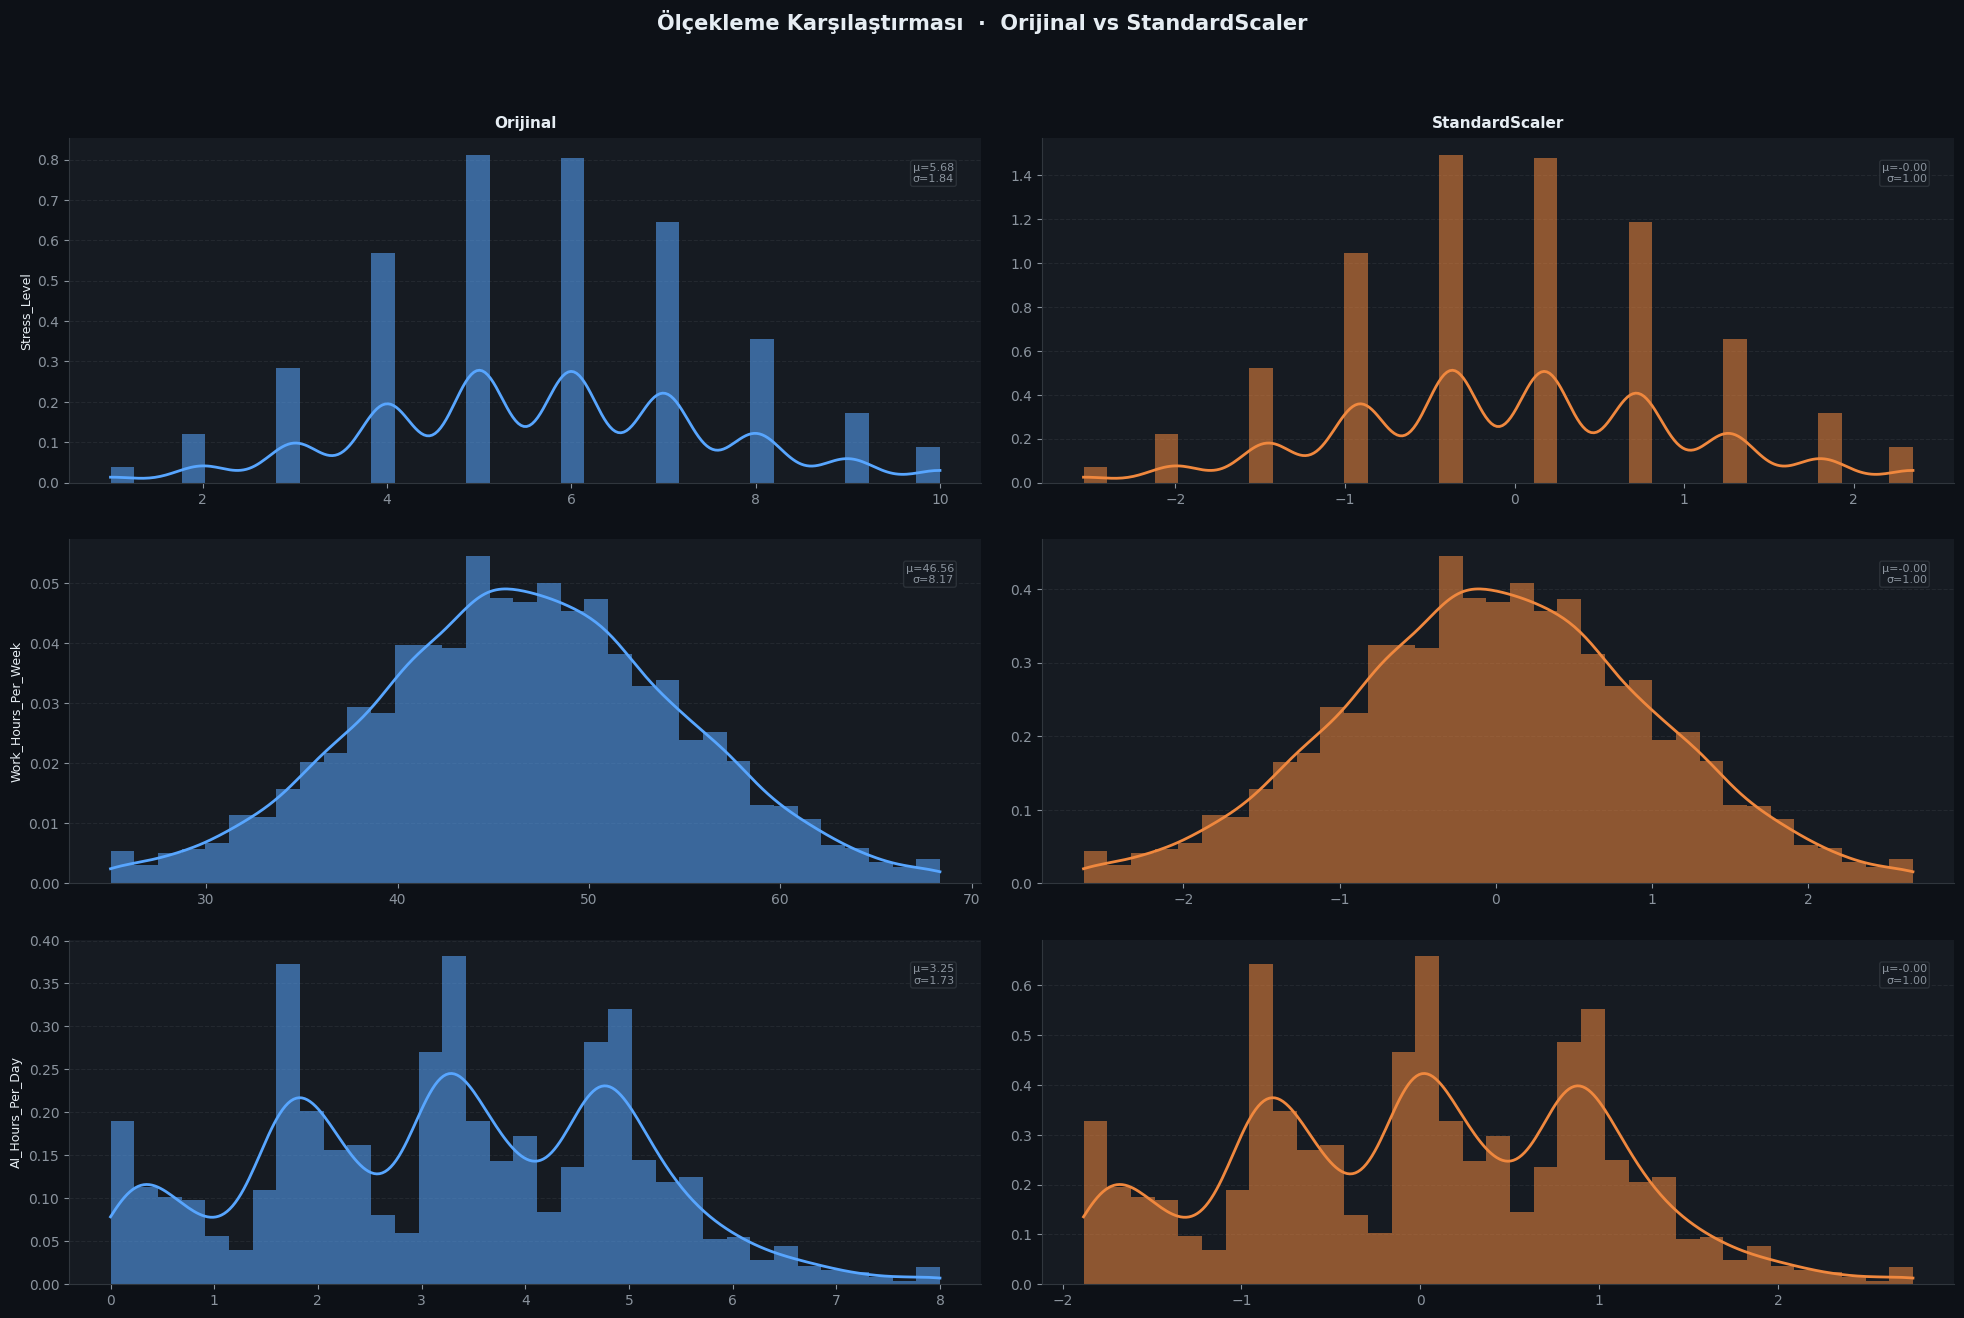

In [30]:
compare_cols = ['Stress_Level', 'Work_Hours_Per_Week', 'AI_Hours_Per_Day']
scalers = {
    'Orijinal':       X_num,
    'StandardScaler': X_std
}
scaler_colors = [C1, C2]

fig, axes = plt.subplots(3, 2, figsize=(20, 13))
fig.suptitle("Ölçekleme Karşılaştırması  ·  Orijinal vs StandardScaler",
             fontsize=15, fontweight="bold", color=TEXT_PRI, y=1.02)

for i, col in enumerate(compare_cols):
    for j, (name, data) in enumerate(scalers.items()):
        ax = axes[i][j]
        ax.hist(data[col], bins=35, color=scaler_colors[j],
                alpha=0.55, density=True, zorder=2)
        from scipy import stats as sp_stats
        kde_x = np.linspace(data[col].min(), data[col].max(), 300)
        kde   = sp_stats.gaussian_kde(data[col])
        ax.plot(kde_x, kde(kde_x), color=scaler_colors[j], lw=2, zorder=3)
        if i == 0:
            ax.set_title(name, fontsize=11, fontweight="bold",
                         color=TEXT_PRI, pad=8)
        if j == 0:
            ax.set_ylabel(col, fontsize=9, color=TEXT_PRI)
        ax.text(0.97, 0.93,
                f"μ={data[col].mean():.2f}\nσ={data[col].std():.2f}",
                transform=ax.transAxes, ha="right", va="top",
                fontsize=8, color=TEXT_SEC,
                bbox=dict(facecolor=PANEL, edgecolor=BORDER,
                          boxstyle="round,pad=0.2", alpha=0.8))
        ax.yaxis.grid(True, zorder=0); ax.set_axisbelow(True)

plt.tight_layout(pad=2)
plt.show()

In [31]:
le_target = LabelEncoder()
df_clean['Burnout_Label_LE'] = le_target.fit_transform(df_clean['Burnout_Label'])

print("Burnout_Label mapping:")
print(dict(zip(le_target.classes_, le_target.transform(le_target.classes_))))

target_num = df_clean['Burnout_Label_LE']
te = TargetEncoder(cols=['Industry', 'Job_Role'], smoothing=1.0)
df_clean[['Industry_TE', 'Job_Role_TE']] = te.fit_transform(
    df_clean[['Industry', 'Job_Role']], target_num
)

print("\n=== TARGET ENCODING SONUCU ===")
print("\nIndustry Encoding Değerleri:")
print(df_clean.groupby('Industry')['Industry_TE'].first().sort_values(ascending=False).round(4))
print("\nJob_Role Encoding Değerleri (ilk 10):")
print(df_clean.groupby('Job_Role')['Job_Role_TE'].first().sort_values(ascending=False).head(10).round(4))

drop_cols = ['Worker_ID', 'Industry', 'Job_Role', 'Burnout_Label']
df_model = df_clean.drop(columns=drop_cols)

print("\n=== MODEL DATAFRAME SÜTUNLARI ===")
print(df_model.dtypes)
print(f"\nBoyut: {df_model.shape}")
print(f"Tüm sütunlar sayısal mı: {df_model.select_dtypes(include='object').shape[1] == 0}")

Burnout_Label mapping:
{'At Risk': np.int64(0), 'Burned Out': np.int64(1), 'No Risk': np.int64(2)}

=== TARGET ENCODING SONUCU ===

Industry Encoding Değerleri:
Industry
Creative      1.6270
Legal         1.6012
Education     1.5952
Healthcare    1.5603
Finance       1.5436
Technology    1.5080
Name: Industry_TE, dtype: float64

Job_Role Encoding Değerleri (ilk 10):
Job_Role
Legal Analyst          1.7246
Curriculum Designer    1.6781
Art Director           1.6667
Brand Strategist       1.6389
UX Designer            1.6364
Paralegal              1.6278
Teacher                1.6126
Copywriter             1.6125
Medical Researcher     1.6032
Contract Specialist    1.5959
Name: Job_Role_TE, dtype: float64

=== MODEL DATAFRAME SÜTUNLARI ===
Age                         int64
Years_Experience          float64
AI_Tools_Used_Daily         int64
AI_Hours_Per_Day          float64
AI_Adoption_Level           int64
Perceived_Usefulness        int64
Skill_Anxiety_Score         int64
Work_Hours_Per_

In [28]:
df_model.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8500 entries, 0 to 8499
Data columns (total 21 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Age                     8500 non-null   int64  
 1   Years_Experience        8500 non-null   float64
 2   AI_Tools_Used_Daily     8500 non-null   int64  
 3   AI_Hours_Per_Day        8500 non-null   float64
 4   AI_Adoption_Level       8500 non-null   int64  
 5   Perceived_Usefulness    8500 non-null   int64  
 6   Skill_Anxiety_Score     8500 non-null   int64  
 7   Work_Hours_Per_Week     8500 non-null   float64
 8   Meetings_Per_Week       8500 non-null   float64
 9   Deep_Work_Hours         8500 non-null   float64
 10  Interruptions_Per_Day   8500 non-null   float64
 11  Sleep_Hours_Per_Night   8500 non-null   float64
 12  Physical_Activity_Days  8500 non-null   int64  
 13  Stress_Level            8500 non-null   int64  
 14  Job_Satisfaction        8500 non-null   

In [32]:
feature_cols = num_cols + ['Industry_TE', 'Job_Role_TE']

X = df_clean[feature_cols].copy()
y = df_clean['Burnout_Label_LE']

X_scaled = pd.DataFrame(scaler_std.fit_transform(X), columns=feature_cols)

print("X shape:", X_scaled.shape)
print("y dağılımı (orijinal):")
print(pd.Series(y).value_counts().rename(index=dict(zip(
    le_target.transform(le_target.classes_), le_target.classes_))))

X shape: (8500, 20)
y dağılımı (orijinal):
Burnout_Label_LE
No Risk       6601
At Risk       1865
Burned Out      34
Name: count, dtype: int64


In [33]:
smotetomek = SMOTETomek(
    smote=SMOTE(k_neighbors=5, random_state=42),
    random_state=42
)
X_resampled, y_resampled = smotetomek.fit_resample(X_scaled, y)

print("=== ÖNCE / SONRA KARŞILAŞTIRMA ===")
label_map = dict(zip(le_target.transform(le_target.classes_), le_target.classes_))
before = Counter(y)
after  = Counter(y_resampled)

print(f"\n{'Sınıf':<15} {'Önce':>8} {'Sonra':>8} {'Değişim':>10}")
print("-" * 45)
for k in sorted(before.keys()):
    diff = after[k] - before[k]
    print(f"{label_map[k]:<15} {before[k]:>8,} {after[k]:>8,} {diff:>+10,}")

print(f"\nToplam önce : {sum(before.values()):,}")
print(f"Toplam sonra: {sum(after.values()):,}")

=== ÖNCE / SONRA KARŞILAŞTIRMA ===

Sınıf               Önce    Sonra    Değişim
---------------------------------------------
At Risk            1,865    6,595     +4,730
Burned Out            34    6,601     +6,567
No Risk            6,601    6,595         -6

Toplam önce : 8,500
Toplam sonra: 19,791


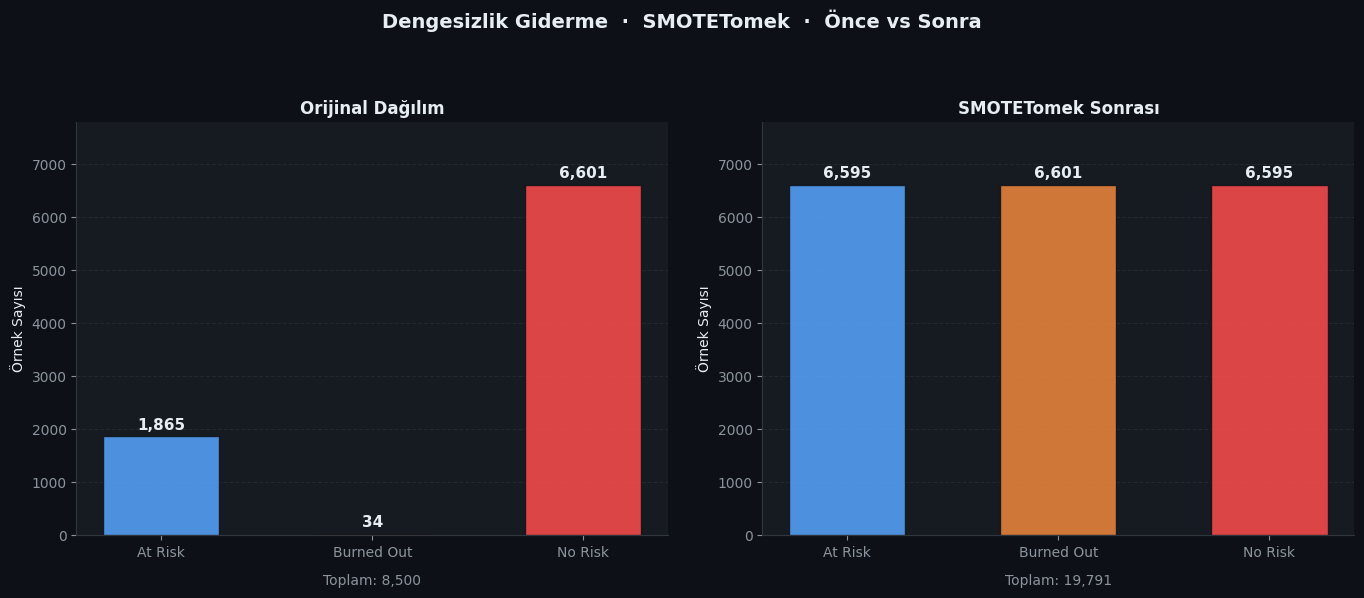


→ X_resampled, y_resampled modelleme için hazır.
  Final shape: (19791, 20)


In [34]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle("Dengesizlik Giderme  ·  SMOTETomek  ·  Önce vs Sonra",
             fontsize=14, fontweight="bold", color=TEXT_PRI, y=1.02)

label_names = [label_map[k] for k in sorted(before.keys())]

ax1 = axes[0]
vals_before = [before[k] for k in sorted(before.keys())]
bars1 = ax1.bar(label_names, vals_before, color=PALETTE,
                edgecolor=BG, width=0.55, zorder=3, alpha=0.85)
for bar, val in zip(bars1, vals_before):
    ax1.text(bar.get_x() + bar.get_width()/2,
             bar.get_height() + 80,
             f"{val:,}", ha="center", va="bottom",
             fontsize=11, fontweight="bold", color=TEXT_PRI)
ax1.set_title("Orijinal Dağılım", fontsize=12, fontweight="bold", color=TEXT_PRI)
ax1.set_ylabel("Örnek Sayısı"); ax1.set_ylim(0, max(vals_before) * 1.18)
ax1.yaxis.grid(True, zorder=0); ax1.set_axisbelow(True)
ax1.text(0.5, -0.12, f"Toplam: {sum(vals_before):,}",
         transform=ax1.transAxes, ha="center", fontsize=10, color=TEXT_SEC)

ax2 = axes[1]
vals_after = [after[k] for k in sorted(after.keys())]
bars2 = ax2.bar(label_names, vals_after, color=PALETTE,
                edgecolor=BG, width=0.55, zorder=3, alpha=0.85)
for bar, val in zip(bars2, vals_after):
    ax2.text(bar.get_x() + bar.get_width()/2,
             bar.get_height() + 80,
             f"{val:,}", ha="center", va="bottom",
             fontsize=11, fontweight="bold", color=TEXT_PRI)
ax2.set_title("SMOTETomek Sonrası", fontsize=12, fontweight="bold", color=TEXT_PRI)
ax2.set_ylabel("Örnek Sayısı"); ax2.set_ylim(0, max(vals_after) * 1.18)
ax2.yaxis.grid(True, zorder=0); ax2.set_axisbelow(True)
ax2.text(0.5, -0.12, f"Toplam: {sum(vals_after):,}",
         transform=ax2.transAxes, ha="center", fontsize=10, color=TEXT_SEC)

plt.tight_layout(pad=2)
plt.show()

print("\n→ X_resampled, y_resampled modelleme için hazır.")
print(f"  Final shape: {X_resampled.shape}")

# ***ÖZELLİK MÜHENDİSLİĞİ***

In [35]:
# — 1) Burnout Risk Index (Oran) —
# Yüksek stres + uzun çalışma saati + düşük uyku → tükenmişlik için en güçlü üçlü
# Bunu tek bir bileşik skora dönüştürüyoruz

df_clean['Burnout_Risk_Index'] = (
    (df_clean['Stress_Level'] * df_clean['Work_Hours_Per_Week']) /
    (df_clean['Sleep_Hours_Per_Night'] + 1)   # +1 sıfıra bölme önlemi
)

print("=== Burnout_Risk_Index ===")
print(df_clean['Burnout_Risk_Index'].describe().round(3))
print("\nSınıfa göre ortalama:")
print(df_clean.groupby('Burnout_Label')['Burnout_Risk_Index'].mean().round(3))

=== Burnout_Risk_Index ===
count    8500.000
mean       37.919
std        18.163
min         2.550
25%        24.822
50%        35.263
75%        48.110
max       136.700
Name: Burnout_Risk_Index, dtype: float64

Sınıfa göre ortalama:
Burnout_Label
At Risk       58.476
Burned Out    83.837
No Risk       31.874
Name: Burnout_Risk_Index, dtype: float64


In [36]:
# — 2) Cognitive Overload Score (Etkileşim Terimi) —
# Bilişsel yük + kesinti sayısı + toplantı yoğunluğu → odaklanmayı bozan faktörler
# Derin çalışma saatine bölerek "verimli zaman başına düşen baskı"yı ölçüyoruz

df_clean['Cognitive_Overload_Score'] = (
    (df_clean['Cognitive_Load_Score'] +
     df_clean['Interruptions_Per_Day'] +
     df_clean['Meetings_Per_Week']) /
    (df_clean['Deep_Work_Hours'] + 1)   # +1 sıfıra bölme önlemi
)

print("=== Cognitive_Overload_Score ===")
print(df_clean['Cognitive_Overload_Score'].describe().round(3))
print("\nSınıfa göre ortalama:")
print(df_clean.groupby('Burnout_Label')['Cognitive_Overload_Score'].mean().round(3))

=== Cognitive_Overload_Score ===
count    8500.000
mean        7.081
std         3.454
min         1.429
25%         4.792
50%         6.250
75%         8.276
max        28.000
Name: Cognitive_Overload_Score, dtype: float64

Sınıfa göre ortalama:
Burnout_Label
At Risk        8.013
Burned Out    10.585
No Risk        6.799
Name: Cognitive_Overload_Score, dtype: float64


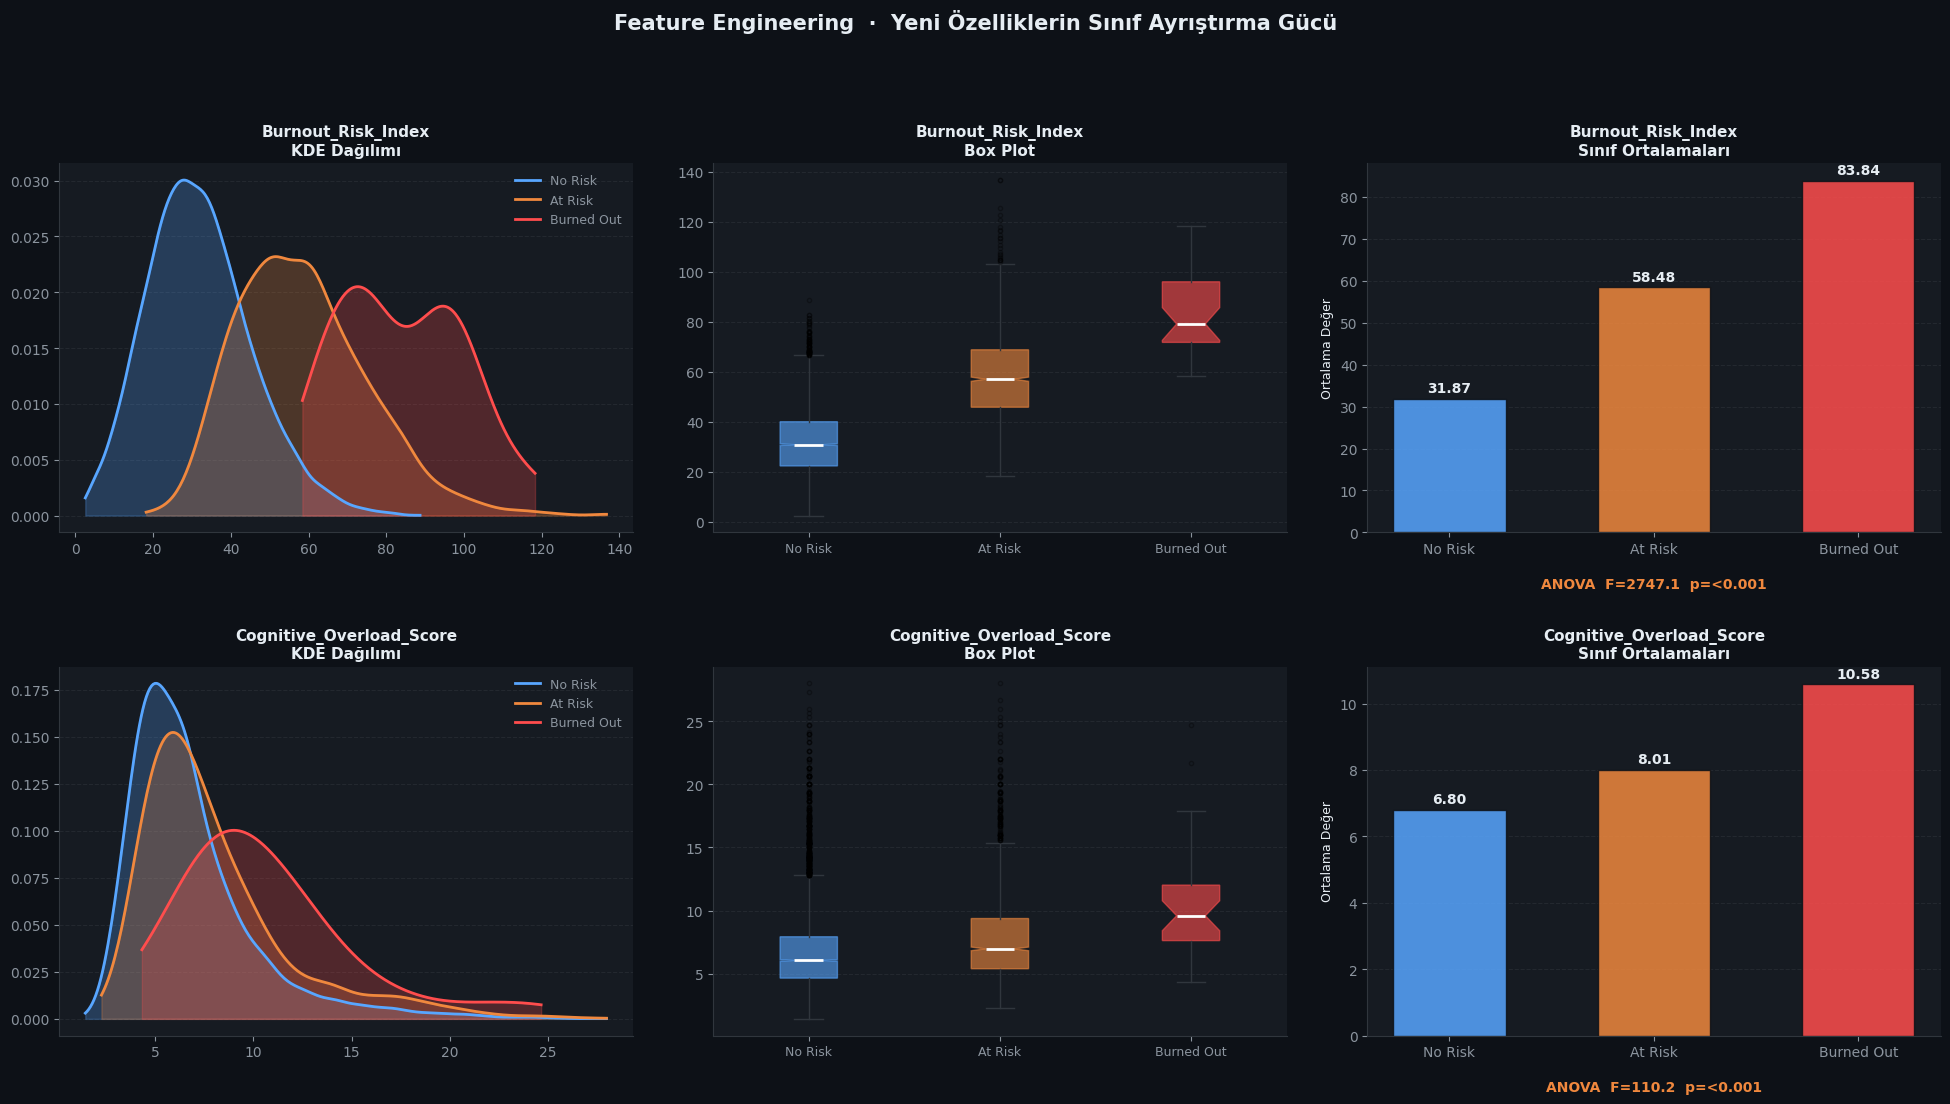

In [37]:
new_features = ['Burnout_Risk_Index', 'Cognitive_Overload_Score']
ORDER = ["No Risk", "At Risk", "Burned Out"]

fig, axes = plt.subplots(2, 3, figsize=(20, 11))
fig.suptitle("Feature Engineering  ·  Yeni Özelliklerin Sınıf Ayrıştırma Gücü",
             fontsize=15, fontweight="bold", color=TEXT_PRI, y=1.02)

for i, feat in enumerate(new_features):
    ax1 = axes[i][0]
    for lbl, color in zip(ORDER, PALETTE):
        sub = df_clean[df_clean['Burnout_Label'] == lbl][feat]
        kde_x = np.linspace(sub.min(), sub.max(), 300)
        kde   = sp_stats.gaussian_kde(sub)
        ax1.fill_between(kde_x, kde(kde_x), alpha=0.25, color=color)
        ax1.plot(kde_x, kde(kde_x), color=color, lw=2, label=lbl)
    ax1.set_title(f"{feat}\nKDE Dağılımı", fontsize=11, fontweight="bold", color=TEXT_PRI)
    ax1.legend(frameon=False, fontsize=9, labelcolor=TEXT_SEC)
    ax1.yaxis.grid(True, zorder=0); ax1.set_axisbelow(True)

    ax2 = axes[i][1]
    bp = ax2.boxplot(
        [df_clean[df_clean['Burnout_Label'] == lbl][feat].values for lbl in ORDER],
        positions=[1, 2, 3], patch_artist=True, notch=True,
        medianprops=dict(color="white", lw=2),
        whiskerprops=dict(color=BORDER),
        capprops=dict(color=BORDER),
        flierprops=dict(marker="o", markersize=3, alpha=0.3)
    )
    for patch, color in zip(bp['boxes'], PALETTE):
        patch.set_facecolor(color); patch.set_alpha(0.6); patch.set_edgecolor(color)
    ax2.set_xticks([1, 2, 3])
    ax2.set_xticklabels(["No Risk", "At Risk", "Burned Out"], fontsize=9, color=TEXT_SEC)
    ax2.set_title(f"{feat}\nBox Plot", fontsize=11, fontweight="bold", color=TEXT_PRI)
    ax2.yaxis.grid(True, zorder=0); ax2.set_axisbelow(True)

    ax3 = axes[i][2]
    groups_feat = [df_clean[df_clean['Burnout_Label'] == lbl][feat].values for lbl in ORDER]
    f_stat, p_val = sp_stats.f_oneway(*groups_feat)
    means = [df_clean[df_clean['Burnout_Label'] == lbl][feat].mean() for lbl in ORDER]
    bars = ax3.bar(ORDER, means, color=PALETTE, edgecolor=BG,
                   width=0.55, zorder=3, alpha=0.85)
    for bar, val in zip(bars, means):
        ax3.text(bar.get_x() + bar.get_width()/2,
                 bar.get_height() + max(means) * 0.01,
                 f"{val:.2f}", ha="center", va="bottom",
                 fontsize=10, fontweight="bold", color=TEXT_PRI)
    ax3.set_title(f"{feat}\nSınıf Ortalamaları", fontsize=11, fontweight="bold", color=TEXT_PRI)
    ax3.set_ylabel("Ortalama Değer", fontsize=9)
    ax3.yaxis.grid(True, zorder=0); ax3.set_axisbelow(True)
    ax3.text(0.5, -0.15,
             f"ANOVA  F={f_stat:.1f}  p={'<0.001' if p_val < 0.001 else f'{p_val:.4f}'}",
             transform=ax3.transAxes, ha="center",
             fontsize=10, color=C2 if p_val < 0.05 else TEXT_SEC,
             fontweight="bold")

plt.tight_layout(pad=2.5)
plt.show()

In [38]:
# — feature_cols listesini güncelle —
feature_cols = num_cols + ['Industry_TE', 'Job_Role_TE',
                            'Burnout_Risk_Index', 'Cognitive_Overload_Score']

X = df_clean[feature_cols].copy()
y = df_clean['Burnout_Label_LE']

X_scaled = pd.DataFrame(scaler_std.fit_transform(X), columns=feature_cols)

print(f"Güncel X shape  : {X_scaled.shape}")
print(f"Yeni özellikler : Burnout_Risk_Index, Cognitive_Overload_Score")
print(f"Toplam feature  : {len(feature_cols)}")

Güncel X shape  : (8500, 22)
Yeni özellikler : Burnout_Risk_Index, Cognitive_Overload_Score
Toplam feature  : 22


In [39]:
# — SMOTETomek tekrar uygula (yeni özelliklerle) —
smotetomek = SMOTETomek(
    smote=SMOTE(k_neighbors=5, random_state=42),
    random_state=42
)
X_resampled, y_resampled = smotetomek.fit_resample(X_scaled, y)

print(f"X_resampled shape : {X_resampled.shape}")
print(f"y_resampled dağılımı: {Counter(y_resampled)}")
print("\n→ X_resampled, y_resampled modelleme için hazır.")

X_resampled shape : (19791, 22)
y_resampled dağılımı: Counter({1: 6601, 2: 6595, 0: 6595})

→ X_resampled, y_resampled modelleme için hazır.


# ***MODELLEME ve DEĞERLENDİRME***

In [41]:
X_train, X_test, y_train, y_test = train_test_split(
    X_resampled, y_resampled,
    test_size=0.2,
    random_state=42,
    stratify=y_resampled
)

print(f"X_train : {X_train.shape}")
print(f"X_test  : {X_test.shape}")
print(f"y_train dağılımı: {Counter(y_train)}")
print(f"y_test  dağılımı: {Counter(y_test)}")

def compute_metrics(model, X, y, split_name):
    y_pred  = model.predict(X)
    y_proba = model.predict_proba(X) if hasattr(model, 'predict_proba') else None

    acc  = accuracy_score(y, y_pred)
    prec = precision_score(y, y_pred, average='macro', zero_division=0)
    rec  = recall_score(y, y_pred, average='macro', zero_division=0)
    f1   = f1_score(y, y_pred, average='macro', zero_division=0)
    auc  = (roc_auc_score(y, y_proba, multi_class='ovr', average='macro')
            if y_proba is not None else np.nan)
    cm   = confusion_matrix(y, y_pred)

    print(f"\n── {split_name} METRİKLERİ ──")
    print(f"  Accuracy : {acc:.4f}")
    print(f"  Precision: {prec:.4f}  (macro)")
    print(f"  Recall   : {rec:.4f}  (macro)")
    print(f"  F1-Score : {f1:.4f}  (macro)")
    print(f"  ROC-AUC  : {auc:.4f}  (macro ovr)")
    print(f"\n  Classification Report:\n")
    print(classification_report(y, y_pred,
          target_names=le_target.classes_, zero_division=0))
    print(f"  Confusion Matrix:\n{cm}")

    return {"split": split_name, "accuracy": acc, "precision": prec,
            "recall": rec, "f1": f1, "auc": auc}

def compute_resources(model, model_name, train_time, emissions_kg):
    tmp_path = f"/tmp/{model_name}.pkl"
    with open(tmp_path, 'wb') as f:
        pickle.dump(model, f)
    size_mb = os.path.getsize(tmp_path) / (1024 * 1024)
    os.remove(tmp_path)

    process = psutil.Process(os.getpid())
    ram_mb  = process.memory_info().rss / (1024 * 1024)

    print(f"\n── KAYNAK KULLANIMI ──")
    print(f"  Eğitim süresi : {train_time:.2f} sn")
    print(f"  RAM kullanımı : {ram_mb:.1f} MB")
    print(f"  Model boyutu  : {size_mb:.4f} MB")
    print(f"  Karbon (CO₂)  : {emissions_kg*1000:.6f} g CO₂eq")

    return {"train_time_sec": round(train_time, 4),
            "ram_mb":         round(ram_mb, 2),
            "model_size_mb":  round(size_mb, 6),
            "co2_grams":      round(emissions_kg * 1000, 6)}

all_results = []

X_train : (15832, 22)
X_test  : (3959, 22)
y_train dağılımı: Counter({1: 5280, 0: 5276, 2: 5276})
y_test  dağılımı: Counter({1: 1321, 0: 1319, 2: 1319})


In [43]:
print("=" * 60)
print("MODEL 1  ·  Logistic Regression")
print("=" * 60)

tracker = EmissionsTracker(log_level="error", save_to_file=False)
tracker.start()
t0 = time.time()

lr = LogisticRegression(
    max_iter=1000,
    class_weight='balanced',
    random_state=42,
    solver='lbfgs',
    multi_class='multinomial'
)
lr.fit(X_train, y_train)

train_time  = time.time() - t0
emissions   = tracker.stop()

train_metrics = compute_metrics(lr, X_train, y_train, "TRAIN")
test_metrics  = compute_metrics(lr, X_test,  y_test,  "TEST")

resources = compute_resources(lr, "logistic_regression", train_time, emissions)

all_results.append({
    "model": "Logistic Regression",
    **{f"train_{k}": v for k, v in train_metrics.items() if k != "split"},
    **{f"test_{k}":  v for k, v in test_metrics.items()  if k != "split"},
    **resources
})

[codecarbon WARNING @ 08:06:55] Multiple instances of codecarbon are allowed to run at the same time.


MODEL 1  ·  Logistic Regression

── TRAIN METRİKLERİ ──
  Accuracy : 0.9963
  Precision: 0.9963  (macro)
  Recall   : 0.9963  (macro)
  F1-Score : 0.9963  (macro)
  ROC-AUC  : 1.0000  (macro ovr)

  Classification Report:

              precision    recall  f1-score   support

     At Risk       0.99      1.00      0.99      5276
  Burned Out       1.00      1.00      1.00      5280
     No Risk       1.00      0.99      1.00      5276

    accuracy                           1.00     15832
   macro avg       1.00      1.00      1.00     15832
weighted avg       1.00      1.00      1.00     15832

  Confusion Matrix:
[[5251   24    1]
 [   0 5280    0]
 [  33    0 5243]]

── TEST METRİKLERİ ──
  Accuracy : 0.9942
  Precision: 0.9942  (macro)
  Recall   : 0.9942  (macro)
  F1-Score : 0.9942  (macro)
  ROC-AUC  : 0.9999  (macro ovr)

  Classification Report:

              precision    recall  f1-score   support

     At Risk       0.99      1.00      0.99      1319
  Burned Out       1.0

In [45]:
print("=" * 60)
print("MODEL 2  ·  K-Nearest Neighbors")
print("=" * 60)

tracker = EmissionsTracker(log_level="error", save_to_file=False)
tracker.start()
t0 = time.time()

knn = KNeighborsClassifier(
    n_neighbors=7,
    metric='minkowski',
    weights='distance',
    n_jobs=-1
)
knn.fit(X_train, y_train)

train_time = time.time() - t0
emissions  = tracker.stop()

train_metrics = compute_metrics(knn, X_train, y_train, "TRAIN")
test_metrics  = compute_metrics(knn, X_test,  y_test,  "TEST")
resources     = compute_resources(knn, "knn", train_time, emissions)

all_results.append({
    "model": "KNN",
    **{f"train_{k}": v for k, v in train_metrics.items() if k != "split"},
    **{f"test_{k}":  v for k, v in test_metrics.items()  if k != "split"},
    **resources
})

MODEL 2  ·  K-Nearest Neighbors

── TRAIN METRİKLERİ ──
  Accuracy : 1.0000
  Precision: 1.0000  (macro)
  Recall   : 1.0000  (macro)
  F1-Score : 1.0000  (macro)
  ROC-AUC  : 1.0000  (macro ovr)

  Classification Report:

              precision    recall  f1-score   support

     At Risk       1.00      1.00      1.00      5276
  Burned Out       1.00      1.00      1.00      5280
     No Risk       1.00      1.00      1.00      5276

    accuracy                           1.00     15832
   macro avg       1.00      1.00      1.00     15832
weighted avg       1.00      1.00      1.00     15832

  Confusion Matrix:
[[5276    0    0]
 [   0 5280    0]
 [   0    0 5276]]

── TEST METRİKLERİ ──
  Accuracy : 0.9449
  Precision: 0.9521  (macro)
  Recall   : 0.9449  (macro)
  F1-Score : 0.9446  (macro)
  ROC-AUC  : 0.9919  (macro ovr)

  Classification Report:

              precision    recall  f1-score   support

     At Risk       0.86      1.00      0.92      1319
  Burned Out       1.0

In [47]:
print("=" * 60)
print("MODEL 3  ·  Decision Tree")
print("=" * 60)

tracker = EmissionsTracker(log_level="error", save_to_file=False)
tracker.start()
t0 = time.time()

dt = DecisionTreeClassifier(
    max_depth=10,
    min_samples_split=20,
    min_samples_leaf=10,
    class_weight='balanced',
    random_state=42
)
dt.fit(X_train, y_train)

train_time = time.time() - t0
emissions  = tracker.stop()

train_metrics = compute_metrics(dt, X_train, y_train, "TRAIN")
test_metrics  = compute_metrics(dt, X_test,  y_test,  "TEST")
resources     = compute_resources(dt, "decision_tree", train_time, emissions)

all_results.append({
    "model": "Decision Tree",
    **{f"train_{k}": v for k, v in train_metrics.items() if k != "split"},
    **{f"test_{k}":  v for k, v in test_metrics.items()  if k != "split"},
    **resources
})

MODEL 3  ·  Decision Tree

── TRAIN METRİKLERİ ──
  Accuracy : 0.9802
  Precision: 0.9803  (macro)
  Recall   : 0.9802  (macro)
  F1-Score : 0.9802  (macro)
  ROC-AUC  : 0.9987  (macro ovr)

  Classification Report:

              precision    recall  f1-score   support

     At Risk       0.97      0.97      0.97      5276
  Burned Out       0.99      1.00      0.99      5280
     No Risk       0.98      0.97      0.98      5276

    accuracy                           0.98     15832
   macro avg       0.98      0.98      0.98     15832
weighted avg       0.98      0.98      0.98     15832

  Confusion Matrix:
[[5142   46   88]
 [  11 5269    0]
 [ 168    0 5108]]

── TEST METRİKLERİ ──
  Accuracy : 0.9795
  Precision: 0.9795  (macro)
  Recall   : 0.9795  (macro)
  F1-Score : 0.9795  (macro)
  ROC-AUC  : 0.9949  (macro ovr)

  Classification Report:

              precision    recall  f1-score   support

     At Risk       0.97      0.97      0.97      1319
  Burned Out       0.99     

In [49]:
print("=" * 60)
print("MODEL 4  ·  Random Forest")
print("=" * 60)

tracker = EmissionsTracker(log_level="error", save_to_file=False)
tracker.start()
t0 = time.time()

rf = RandomForestClassifier(
    n_estimators=200,
    max_depth=15,
    min_samples_split=10,
    min_samples_leaf=5,
    class_weight='balanced',
    random_state=42,
    n_jobs=-1
)
rf.fit(X_train, y_train)

train_time = time.time() - t0
emissions  = tracker.stop()

train_metrics = compute_metrics(rf, X_train, y_train, "TRAIN")
test_metrics  = compute_metrics(rf, X_test,  y_test,  "TEST")
resources     = compute_resources(rf, "random_forest", train_time, emissions)

all_results.append({
    "model": "Random Forest",
    **{f"train_{k}": v for k, v in train_metrics.items() if k != "split"},
    **{f"test_{k}":  v for k, v in test_metrics.items()  if k != "split"},
    **resources
})

MODEL 4  ·  Random Forest

── TRAIN METRİKLERİ ──
  Accuracy : 0.9953
  Precision: 0.9953  (macro)
  Recall   : 0.9953  (macro)
  F1-Score : 0.9953  (macro)
  ROC-AUC  : 0.9999  (macro ovr)

  Classification Report:

              precision    recall  f1-score   support

     At Risk       0.99      0.99      0.99      5276
  Burned Out       1.00      1.00      1.00      5280
     No Risk       1.00      0.99      0.99      5276

    accuracy                           1.00     15832
   macro avg       1.00      1.00      1.00     15832
weighted avg       1.00      1.00      1.00     15832

  Confusion Matrix:
[[5246    6   24]
 [   1 5279    0]
 [  44    0 5232]]

── TEST METRİKLERİ ──
  Accuracy : 0.9813
  Precision: 0.9814  (macro)
  Recall   : 0.9813  (macro)
  F1-Score : 0.9813  (macro)
  ROC-AUC  : 0.9992  (macro ovr)

  Classification Report:

              precision    recall  f1-score   support

     At Risk       0.96      0.98      0.97      1319
  Burned Out       1.00     

In [51]:
print("=" * 60)
print("MODEL 5  ·  XGBoost")
print("=" * 60)
sample_weights = compute_sample_weight(class_weight='balanced', y=y_train)

tracker = EmissionsTracker(log_level="error", save_to_file=False)
tracker.start()
t0 = time.time()

xgb = XGBClassifier(
    n_estimators=200,
    max_depth=6,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    use_label_encoder=False,
    eval_metric='mlogloss',
    random_state=42,
    n_jobs=-1
)
xgb.fit(X_train, y_train, sample_weight=sample_weights)

train_time = time.time() - t0
emissions  = tracker.stop()

train_metrics = compute_metrics(xgb, X_train, y_train, "TRAIN")
test_metrics  = compute_metrics(xgb, X_test,  y_test,  "TEST")
resources     = compute_resources(xgb, "xgboost", train_time, emissions)

all_results.append({
    "model": "XGBoost",
    **{f"train_{k}": v for k, v in train_metrics.items() if k != "split"},
    **{f"test_{k}":  v for k, v in test_metrics.items()  if k != "split"},
    **resources
})

MODEL 5  ·  XGBoost

── TRAIN METRİKLERİ ──
  Accuracy : 1.0000
  Precision: 1.0000  (macro)
  Recall   : 1.0000  (macro)
  F1-Score : 1.0000  (macro)
  ROC-AUC  : 1.0000  (macro ovr)

  Classification Report:

              precision    recall  f1-score   support

     At Risk       1.00      1.00      1.00      5276
  Burned Out       1.00      1.00      1.00      5280
     No Risk       1.00      1.00      1.00      5276

    accuracy                           1.00     15832
   macro avg       1.00      1.00      1.00     15832
weighted avg       1.00      1.00      1.00     15832

  Confusion Matrix:
[[5276    0    0]
 [   0 5280    0]
 [   0    0 5276]]

── TEST METRİKLERİ ──
  Accuracy : 0.9934
  Precision: 0.9934  (macro)
  Recall   : 0.9934  (macro)
  F1-Score : 0.9934  (macro)
  ROC-AUC  : 0.9999  (macro ovr)

  Classification Report:

              precision    recall  f1-score   support

     At Risk       0.99      0.99      0.99      1319
  Burned Out       1.00      1.00 

In [52]:
results_df = pd.DataFrame(all_results)

print("\n" + "=" * 80)
print("TÜM MODEL SONUÇLARI — ÖZET TABLO")
print("=" * 80)

print("\n── TRAIN METRİKLERİ ──")
train_cols = ['model','train_accuracy','train_precision',
              'train_recall','train_f1','train_auc']
print(results_df[train_cols].to_string(index=False))

print("\n── TEST METRİKLERİ ──")
test_cols = ['model','test_accuracy','test_precision',
             'test_recall','test_f1','test_auc']
print(results_df[test_cols].to_string(index=False))

print("\n── KAYNAK KULLANIMI ──")
res_cols = ['model','train_time_sec','ram_mb','model_size_mb','co2_grams']
print(results_df[res_cols].to_string(index=False))

print("\n── OVERFİTTİNG KONTROLÜ (Train F1 − Test F1) ──")
results_df['overfit_gap'] = (results_df['train_f1'] - results_df['test_f1']).round(4)
print(results_df[['model','train_f1','test_f1','overfit_gap']].to_string(index=False))


TÜM MODEL SONUÇLARI — ÖZET TABLO

── TRAIN METRİKLERİ ──
              model  train_accuracy  train_precision  train_recall  train_f1  train_auc
Logistic Regression        0.996337         0.996346      0.996336  0.996336   0.999971
                KNN        1.000000         1.000000      1.000000  1.000000   1.000000
      Decision Tree        0.980230         0.980256      0.980225  0.980212   0.998715
      Random Forest        0.995263         0.995264      0.995262  0.995261   0.999946
            XGBoost        1.000000         1.000000      1.000000  1.000000   1.000000

── TEST METRİKLERİ ──
              model  test_accuracy  test_precision  test_recall  test_f1  test_auc
Logistic Regression       0.994190        0.994239     0.994188 0.994188  0.999926
                KNN       0.944936        0.952098     0.944908 0.944561  0.991871
      Decision Tree       0.979540        0.979497     0.979530 0.979501  0.994916
      Random Forest       0.981308        0.981389     0.98

In [53]:
BG="#0D1117"; PANEL="#161B22"; BORDER="#30363D"
C1="#58A6FF"; C2="#F0883E"; C3="#FF4D4D"
ACCENT="#A371F7"
TEXT_PRI="#E6EDF3"; TEXT_SEC="#8B949E"

matplotlib.rcParams.update({
    "figure.facecolor": BG, "axes.facecolor": PANEL,
    "axes.edgecolor": BORDER, "axes.labelcolor": TEXT_PRI,
    "xtick.color": TEXT_SEC, "ytick.color": TEXT_SEC,
    "text.color": TEXT_PRI, "grid.color": BORDER,
    "grid.linestyle": "--", "grid.alpha": 0.4,
    "font.family": "DejaVu Sans",
    "axes.spines.top": False, "axes.spines.right": False,
})

models      = results_df['model'].tolist()
metrics     = ['accuracy', 'precision', 'recall', 'f1', 'auc']
metric_labels = ['Accuracy', 'Precision', 'Recall', 'F1-Score', 'ROC-AUC']
model_colors  = [C1, C2, C3, ACCENT, "#3FB950"]
x = np.arange(len(models))

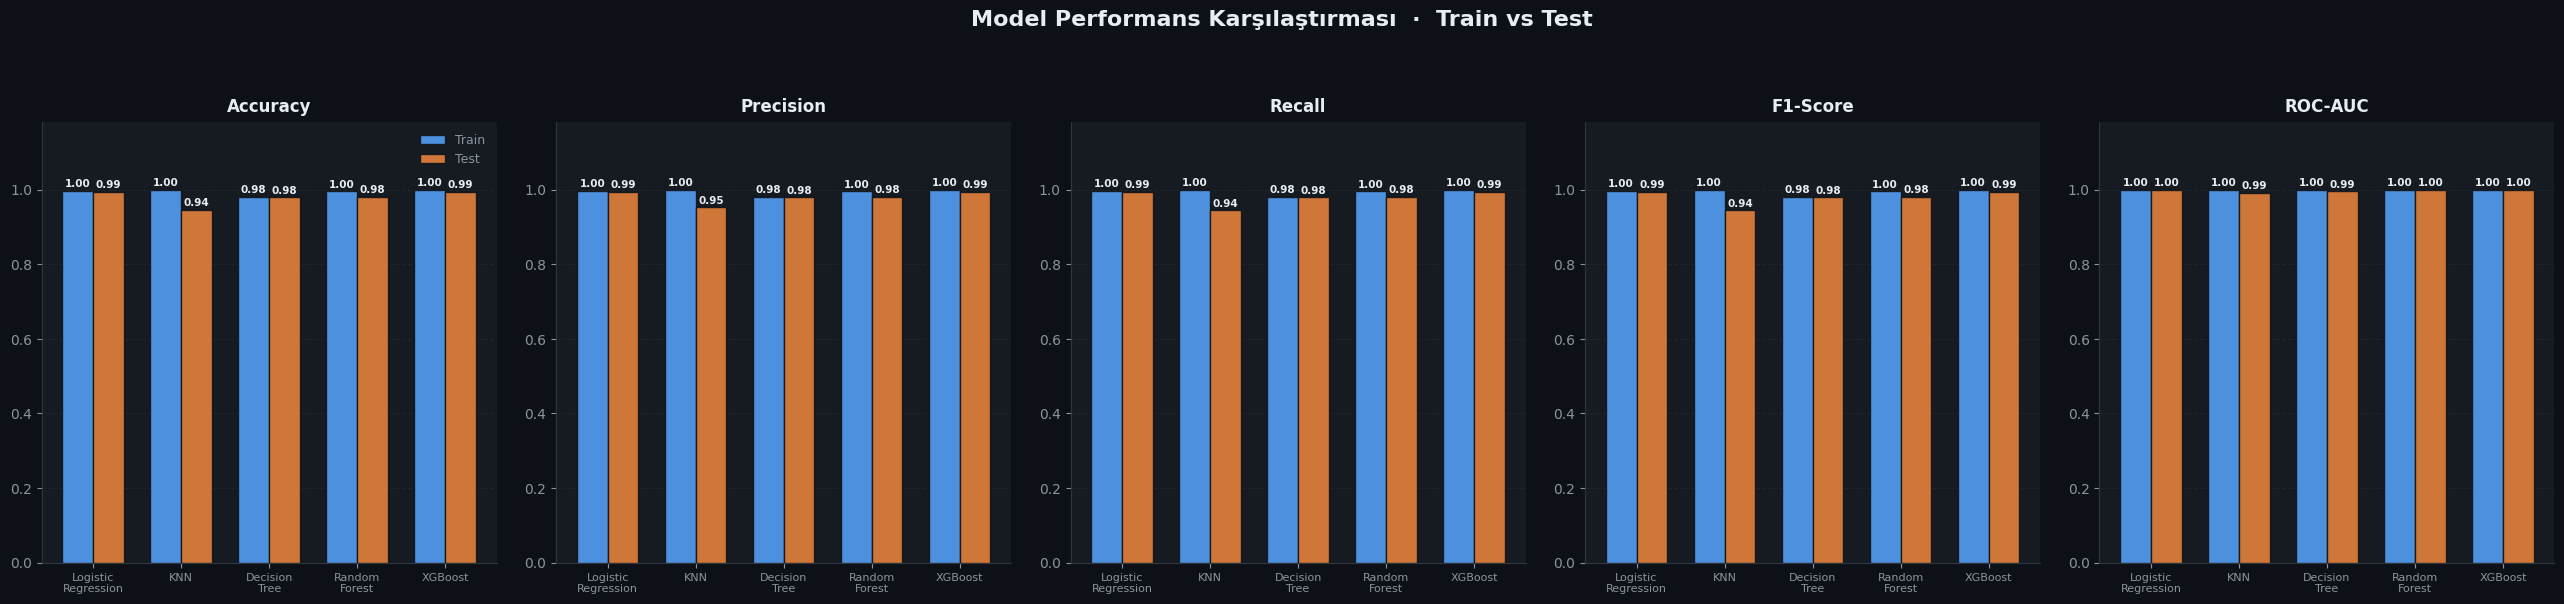

In [54]:
fig, axes = plt.subplots(1, 5, figsize=(26, 6))
fig.suptitle("Model Performans Karşılaştırması  ·  Train vs Test",
             fontsize=16, fontweight="bold", color=TEXT_PRI, y=1.02)

bar_w = 0.35
for i, (metric, label) in enumerate(zip(metrics, metric_labels)):
    ax = axes[i]
    train_vals = results_df[f'train_{metric}'].values
    test_vals  = results_df[f'test_{metric}'].values

    b1 = ax.bar(x - bar_w/2, train_vals, width=bar_w,
                color=C1, alpha=0.85, edgecolor=BG, label='Train', zorder=3)
    b2 = ax.bar(x + bar_w/2, test_vals,  width=bar_w,
                color=C2, alpha=0.85, edgecolor=BG, label='Test',  zorder=3)

    for bar, val in zip(b1, train_vals):
        ax.text(bar.get_x() + bar.get_width()/2,
                bar.get_height() + 0.005,
                f"{val:.2f}", ha="center", va="bottom",
                fontsize=7.5, color=TEXT_PRI, fontweight="bold")
    for bar, val in zip(b2, test_vals):
        ax.text(bar.get_x() + bar.get_width()/2,
                bar.get_height() + 0.005,
                f"{val:.2f}", ha="center", va="bottom",
                fontsize=7.5, color=TEXT_PRI, fontweight="bold")

    ax.set_title(label, fontsize=12, fontweight="bold", color=TEXT_PRI, pad=8)
    ax.set_xticks(x)
    ax.set_xticklabels([m.replace(" ", "\n") for m in models],
                       fontsize=8, color=TEXT_SEC)
    ax.set_ylim(0, 1.18)
    ax.yaxis.grid(True, zorder=0); ax.set_axisbelow(True)
    if i == 0:
        ax.legend(frameon=False, fontsize=9, labelcolor=TEXT_SEC)

plt.tight_layout(pad=2)
plt.show()

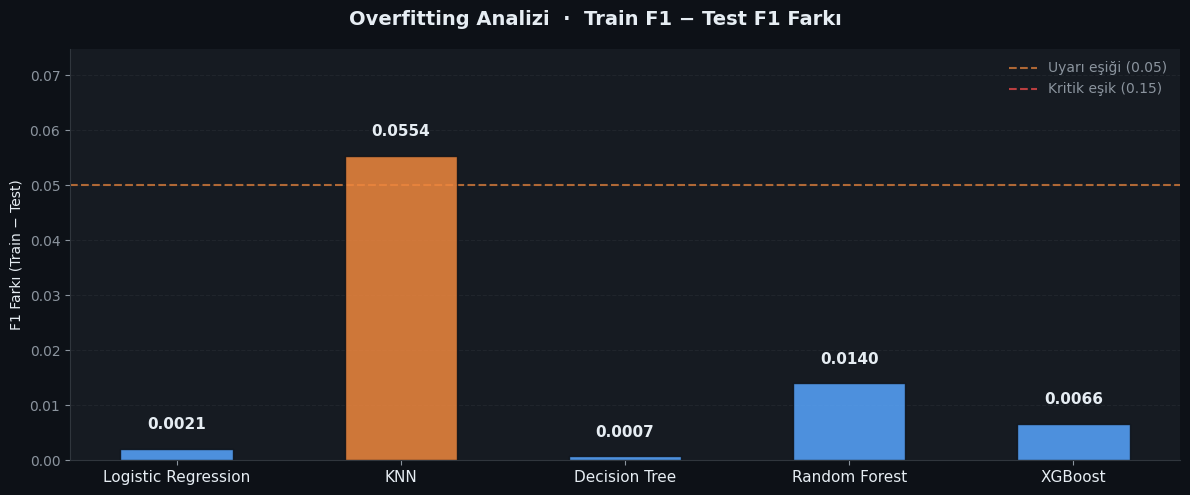

In [56]:
fig, ax = plt.subplots(figsize=(12, 5))
fig.suptitle("Overfitting Analizi  ·  Train F1 − Test F1 Farkı",
             fontsize=14, fontweight="bold", color=TEXT_PRI)

gaps   = results_df['overfit_gap'].values
colors = [C3 if g > 0.15 else C2 if g > 0.05 else C1 for g in gaps]
bars   = ax.bar(models, gaps, color=colors, edgecolor=BG,
                width=0.5, zorder=3, alpha=0.85)

for bar, val in zip(bars, gaps):
    ax.text(bar.get_x() + bar.get_width()/2,
            bar.get_height() + 0.003,
            f"{val:.4f}", ha="center", va="bottom",
            fontsize=11, fontweight="bold", color=TEXT_PRI)

ax.axhline(0.05, color=C2, lw=1.5, ls="--", alpha=0.7, label="Uyarı eşiği (0.05)")
ax.axhline(0.15, color=C3, lw=1.5, ls="--", alpha=0.7, label="Kritik eşik (0.15)")
ax.set_ylabel("F1 Farkı (Train − Test)", fontsize=10)
ax.set_ylim(0, max(gaps) * 1.35)
ax.yaxis.grid(True, zorder=0); ax.set_axisbelow(True)
ax.legend(frameon=False, fontsize=10, labelcolor=TEXT_SEC)
ax.tick_params(axis='x', labelsize=11, labelcolor=TEXT_PRI)

plt.tight_layout()
plt.show()

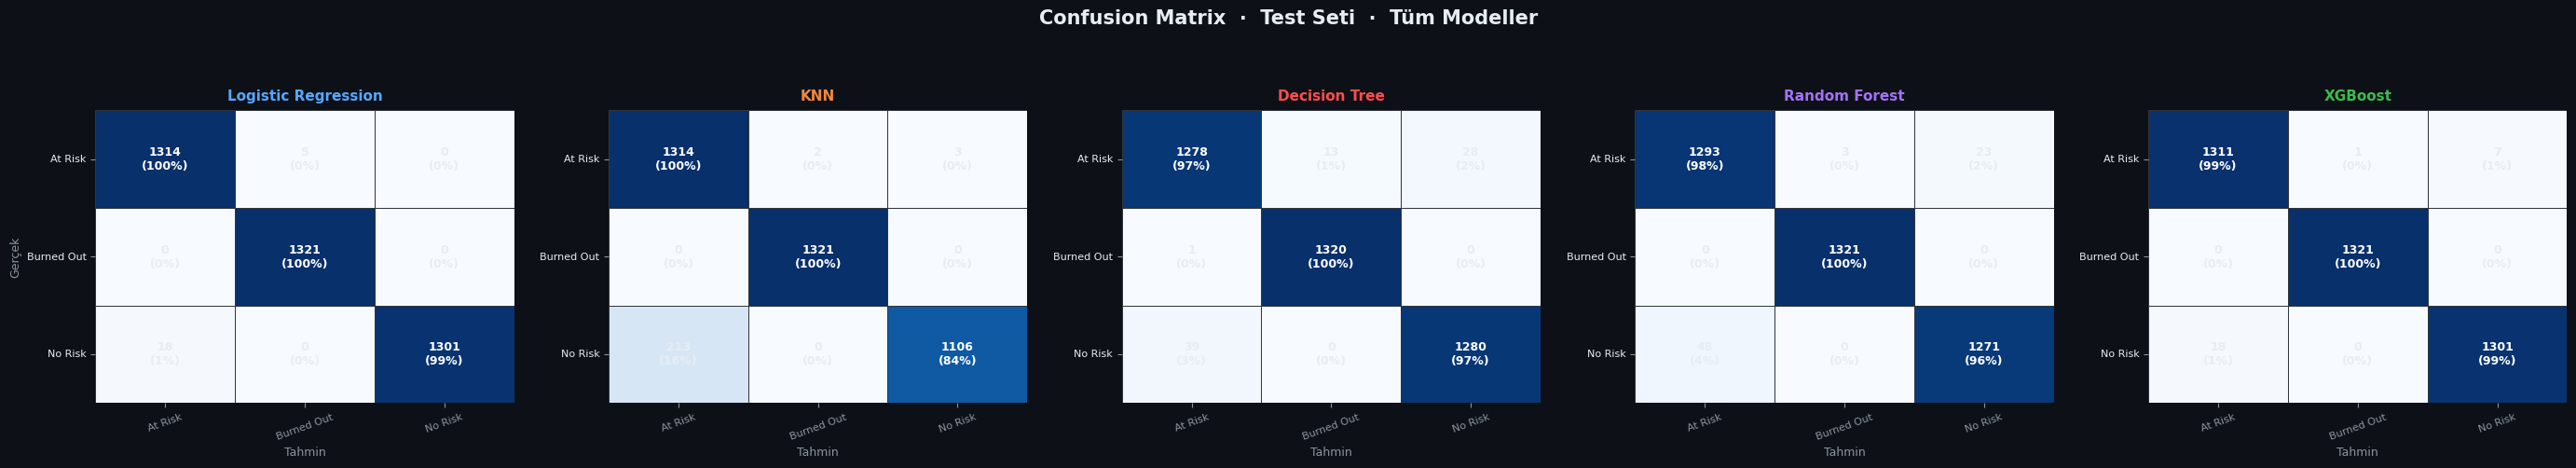

In [57]:
model_objects = [lr, knn, dt, rf, xgb]
class_names   = le_target.classes_

fig, axes = plt.subplots(1, 5, figsize=(28, 5))
fig.suptitle("Confusion Matrix  ·  Test Seti  ·  Tüm Modeller",
             fontsize=15, fontweight="bold", color=TEXT_PRI, y=1.02)

for i, (model_obj, model_name, color) in enumerate(
        zip(model_objects, models, model_colors)):
    ax  = axes[i]
    cm  = confusion_matrix(y_test, model_obj.predict(X_test))
    cm_pct = cm.astype(float) / cm.sum(axis=1, keepdims=True)

    sns.heatmap(cm_pct, ax=ax, annot=False,
                cmap="Blues", vmin=0, vmax=1,
                linewidths=0.5, linecolor=BORDER,
                cbar=False)

    for row in range(cm.shape[0]):
        for col in range(cm.shape[1]):
            ax.text(col + 0.5, row + 0.5,
                    f"{cm[row,col]}\n({cm_pct[row,col]:.0%})",
                    ha="center", va="center",
                    fontsize=9, fontweight="bold",
                    color="white" if cm_pct[row,col] > 0.5 else TEXT_PRI)

    ax.set_title(model_name, fontsize=11, fontweight="bold",
                 color=color, pad=8)
    ax.set_xlabel("Tahmin", fontsize=9, color=TEXT_SEC)
    if i == 0:
        ax.set_ylabel("Gerçek", fontsize=9, color=TEXT_SEC)
    ax.set_xticklabels(class_names, fontsize=8,
                       color=TEXT_SEC, rotation=20)
    ax.set_yticklabels(class_names, fontsize=8,
                       color=TEXT_PRI, rotation=0)

plt.tight_layout(pad=2)
plt.show()

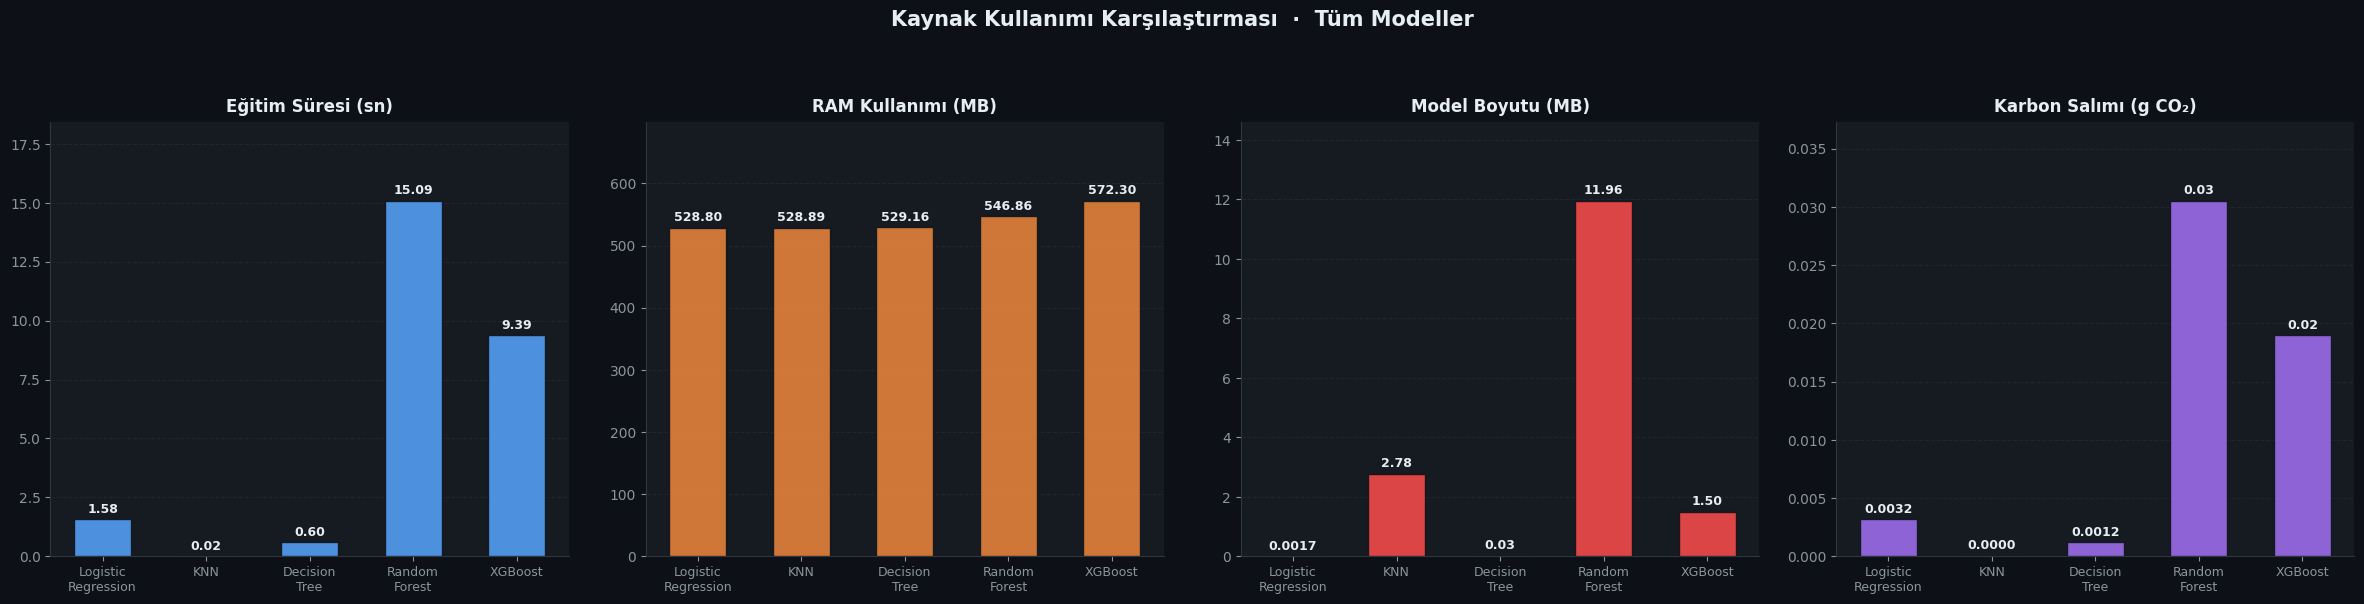

In [58]:
fig, axes = plt.subplots(1, 4, figsize=(24, 6))
fig.suptitle("Kaynak Kullanımı Karşılaştırması  ·  Tüm Modeller",
             fontsize=15, fontweight="bold", color=TEXT_PRI, y=1.02)

resource_metrics = [
    ('train_time_sec', 'Eğitim Süresi (sn)',   C1),
    ('ram_mb',         'RAM Kullanımı (MB)',    C2),
    ('model_size_mb',  'Model Boyutu (MB)',     C3),
    ('co2_grams',      'Karbon Salımı (g CO₂)', ACCENT),
]

for ax, (col, label, color) in zip(axes, resource_metrics):
    vals = results_df[col].values
    bars = ax.bar(models, vals, color=color, edgecolor=BG,
                  width=0.55, zorder=3, alpha=0.85)
    for bar, val in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width()/2,
                bar.get_height() + max(vals) * 0.01,
                f"{val:.4f}" if val < 0.01 else f"{val:.2f}",
                ha="center", va="bottom",
                fontsize=9, fontweight="bold", color=TEXT_PRI)
    ax.set_title(label, fontsize=12, fontweight="bold", color=TEXT_PRI, pad=8)
    ax.set_xticklabels([m.replace(" ", "\n") for m in models],
                       fontsize=9, color=TEXT_SEC)
    ax.set_ylim(0, max(vals) * 1.22)
    ax.yaxis.grid(True, zorder=0); ax.set_axisbelow(True)
    ax.tick_params(axis='x', labelsize=9)

plt.tight_layout(pad=2)
plt.show()

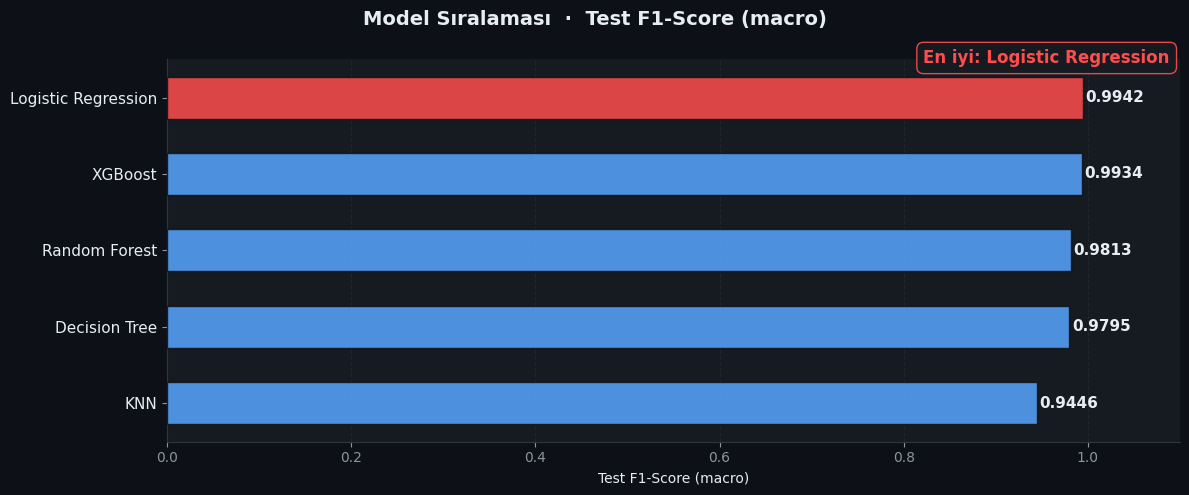

In [67]:
fig, ax = plt.subplots(figsize=(12, 5))
fig.suptitle("Model Sıralaması  ·  Test F1-Score (macro)",
             fontsize=14, fontweight="bold", color=TEXT_PRI)

sorted_df = results_df.sort_values('test_f1', ascending=True)
colors_rank = [C3 if v == sorted_df['test_f1'].max() else C1
               for v in sorted_df['test_f1'].values]

bars = ax.barh(sorted_df['model'], sorted_df['test_f1'],
               color=colors_rank, edgecolor=BG,
               height=0.55, zorder=3, alpha=0.85)
for bar, val in zip(bars, sorted_df['test_f1'].values):
    ax.text(val + 0.003, bar.get_y() + bar.get_height()/2,
            f"{val:.4f}", va="center", fontsize=11,
            fontweight="bold", color=TEXT_PRI)

ax.set_xlabel("Test F1-Score (macro)", fontsize=10)
ax.set_xlim(0, 1.1)
ax.xaxis.grid(True, zorder=0); ax.set_axisbelow(True)
ax.tick_params(axis='y', labelsize=11, labelcolor=TEXT_PRI)

best_model = sorted_df.iloc[-1]['model']
ax.text(0.99, 0.99, f"En iyi: {best_model}",
        transform=ax.transAxes, ha="right",
        fontsize=12, color=C3, fontweight="bold",
        bbox=dict(facecolor=PANEL, edgecolor=C3,
                  boxstyle="round,pad=0.4", alpha=0.9))

plt.tight_layout()
plt.show()

# ***OPTİMİZASYON***

In [69]:
cv      = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
scorer  = make_scorer(f1_score, average='macro', zero_division=0)

cv_results = []

def run_gridsearch(estimator, param_grid, model_name):
    print(f"\n{'='*60}")
    print(f"GridSearchCV  ·  {model_name}")
    print(f"{'='*60}")

    gs = GridSearchCV(
        estimator  = estimator,
        param_grid = param_grid,
        cv         = cv,
        scoring    = scorer,
        n_jobs     = -1,
        verbose    = 1,
        refit      = True
    )

    t0 = time.time()
    gs.fit(X_train, y_train)
    elapsed = time.time() - t0

    print(f"\n  En iyi parametreler : {gs.best_params_}")
    print(f"  CV F1 (best)        : {gs.best_score_:.4f}")
    print(f"  Arama süresi        : {elapsed:.1f} sn")

    return gs, elapsed

def eval_optimized(gs, model_name, elapsed):
    best = gs.best_estimator_

    cv_scores = cross_val_score(best, X_train, y_train,
                                cv=cv, scoring=scorer, n_jobs=-1)
    print(f"\n  5-Fold CV F1 skorları : {cv_scores.round(4)}")
    print(f"  CV Ortalama ± Std     : {cv_scores.mean():.4f} ± {cv_scores.std():.4f}")

    train_m = compute_metrics(best, X_train, y_train, "TRAIN (optimized)")
    test_m  = compute_metrics(best, X_test,  y_test,  "TEST  (optimized)")

    cv_results.append({
        "model":          model_name,
        "best_params":    gs.best_params_,
        "cv_f1_mean":     round(cv_scores.mean(), 4),
        "cv_f1_std":      round(cv_scores.std(),  4),
        "cv_scores":      cv_scores.round(4).tolist(),
        "train_f1":       round(train_m["f1"], 4),
        "test_f1":        round(test_m["f1"],  4),
        "train_acc":      round(train_m["accuracy"], 4),
        "test_acc":       round(test_m["accuracy"],  4),
        "train_auc":      round(train_m["auc"], 4),
        "test_auc":       round(test_m["auc"],  4),
        "overfit_gap":    round(train_m["f1"] - test_m["f1"], 4),
        "search_time_sec":round(elapsed, 2),
    })

    return best

In [71]:
param_grid_lr = {
    'C':            [0.01, 0.1, 1],
    'solver':       ['lbfgs', 'saga'],
    'max_iter':     [50, 80],
    'class_weight': ['balanced']
}

gs_lr, elapsed_lr = run_gridsearch(
    LogisticRegression(random_state=42, multi_class='multinomial'),
    param_grid_lr,
    "Logistic Regression"
)

best_lr = eval_optimized(gs_lr, "Logistic Regression", elapsed_lr)


GridSearchCV  ·  Logistic Regression
Fitting 5 folds for each of 12 candidates, totalling 60 fits

  En iyi parametreler : {'C': 1, 'class_weight': 'balanced', 'max_iter': 80, 'solver': 'lbfgs'}
  CV F1 (best)        : 0.9946
  Arama süresi        : 32.2 sn

  5-Fold CV F1 skorları : [0.9921 0.9931 0.9965 0.9949 0.9962]
  CV Ortalama ± Std     : 0.9946 ± 0.0017

── TRAIN (optimized) METRİKLERİ ──
  Accuracy : 0.9963
  Precision: 0.9963  (macro)
  Recall   : 0.9963  (macro)
  F1-Score : 0.9963  (macro)
  ROC-AUC  : 1.0000  (macro ovr)

  Classification Report:

              precision    recall  f1-score   support

     At Risk       0.99      1.00      0.99      5276
  Burned Out       1.00      1.00      1.00      5280
     No Risk       1.00      0.99      1.00      5276

    accuracy                           1.00     15832
   macro avg       1.00      1.00      1.00     15832
weighted avg       1.00      1.00      1.00     15832

  Confusion Matrix:
[[5251   24    1]
 [   0 5280  

In [72]:
param_grid_knn = {
    'n_neighbors': [3, 5, 7],
    'weights':     ['uniform', 'distance'],
    'metric':      ['minkowski', 'manhattan']
}

gs_knn, elapsed_knn = run_gridsearch(
    KNeighborsClassifier(n_jobs=-1),
    param_grid_knn,
    "KNN"
)

best_knn = eval_optimized(gs_knn, "KNN", elapsed_knn)


GridSearchCV  ·  KNN
Fitting 5 folds for each of 12 candidates, totalling 60 fits

  En iyi parametreler : {'metric': 'manhattan', 'n_neighbors': 3, 'weights': 'distance'}
  CV F1 (best)        : 0.9546
  Arama süresi        : 54.5 sn

  5-Fold CV F1 skorları : [0.9534 0.9588 0.9547 0.9569 0.949 ]
  CV Ortalama ± Std     : 0.9546 ± 0.0034

── TRAIN (optimized) METRİKLERİ ──
  Accuracy : 1.0000
  Precision: 1.0000  (macro)
  Recall   : 1.0000  (macro)
  F1-Score : 1.0000  (macro)
  ROC-AUC  : 1.0000  (macro ovr)

  Classification Report:

              precision    recall  f1-score   support

     At Risk       1.00      1.00      1.00      5276
  Burned Out       1.00      1.00      1.00      5280
     No Risk       1.00      1.00      1.00      5276

    accuracy                           1.00     15832
   macro avg       1.00      1.00      1.00     15832
weighted avg       1.00      1.00      1.00     15832

  Confusion Matrix:
[[5276    0    0]
 [   0 5280    0]
 [   0    0 5276]]

In [73]:
param_grid_dt = {
    'max_depth':        [5, 8, 10],
    'min_samples_split':[10, 20],
    'min_samples_leaf': [5, 10],
    'criterion':        ['gini', 'entropy'],
    'class_weight':     ['balanced']
}

gs_dt, elapsed_dt = run_gridsearch(
    DecisionTreeClassifier(random_state=42),
    param_grid_dt,
    "Decision Tree"
)

best_dt = eval_optimized(gs_dt, "Decision Tree", elapsed_dt)


GridSearchCV  ·  Decision Tree
Fitting 5 folds for each of 24 candidates, totalling 120 fits

  En iyi parametreler : {'class_weight': 'balanced', 'criterion': 'entropy', 'max_depth': 10, 'min_samples_leaf': 5, 'min_samples_split': 20}
  CV F1 (best)        : 0.9741
  Arama süresi        : 41.4 sn

  5-Fold CV F1 skorları : [0.9731 0.9763 0.9763 0.9735 0.9712]
  CV Ortalama ± Std     : 0.9741 ± 0.0020

── TRAIN (optimized) METRİKLERİ ──
  Accuracy : 0.9864
  Precision: 0.9865  (macro)
  Recall   : 0.9864  (macro)
  F1-Score : 0.9864  (macro)
  ROC-AUC  : 0.9996  (macro ovr)

  Classification Report:

              precision    recall  f1-score   support

     At Risk       0.97      0.99      0.98      5276
  Burned Out       1.00      1.00      1.00      5280
     No Risk       0.99      0.98      0.98      5276

    accuracy                           0.99     15832
   macro avg       0.99      0.99      0.99     15832
weighted avg       0.99      0.99      0.99     15832

  Confusio

In [74]:
param_grid_rf = {
    'n_estimators':     [50, 80],
    'max_depth':        [10, 15],
    'min_samples_split':[5, 10],
    'min_samples_leaf': [2, 5],
    'class_weight':     ['balanced']
}

gs_rf, elapsed_rf = run_gridsearch(
    RandomForestClassifier(random_state=42, n_jobs=-1),
    param_grid_rf,
    "Random Forest"
)

best_rf = eval_optimized(gs_rf, "Random Forest", elapsed_rf)


GridSearchCV  ·  Random Forest
Fitting 5 folds for each of 16 candidates, totalling 80 fits

  En iyi parametreler : {'class_weight': 'balanced', 'max_depth': 15, 'min_samples_leaf': 2, 'min_samples_split': 5, 'n_estimators': 80}
  CV F1 (best)        : 0.9803
  Arama süresi        : 256.6 sn

  5-Fold CV F1 skorları : [0.9829 0.9779 0.9814 0.9769 0.9823]
  CV Ortalama ± Std     : 0.9803 ± 0.0024

── TRAIN (optimized) METRİKLERİ ──
  Accuracy : 0.9992
  Precision: 0.9992  (macro)
  Recall   : 0.9992  (macro)
  F1-Score : 0.9992  (macro)
  ROC-AUC  : 1.0000  (macro ovr)

  Classification Report:

              precision    recall  f1-score   support

     At Risk       1.00      1.00      1.00      5276
  Burned Out       1.00      1.00      1.00      5280
     No Risk       1.00      1.00      1.00      5276

    accuracy                           1.00     15832
   macro avg       1.00      1.00      1.00     15832
weighted avg       1.00      1.00      1.00     15832

  Confusion Mat

In [75]:
param_grid_xgb = {
    'n_estimators':    [50, 80],
    'max_depth':       [4, 6],
    'learning_rate':   [0.05, 0.1],
    'subsample':       [0.7, 0.8],
    'colsample_bytree':[0.7, 0.8]
}

sample_weights = compute_sample_weight(class_weight='balanced', y=y_train)

gs_xgb = GridSearchCV(
    estimator  = XGBClassifier(
        use_label_encoder=False,
        eval_metric='mlogloss',
        random_state=42,
        n_jobs=-1
    ),
    param_grid = param_grid_xgb,
    cv         = cv,
    scoring    = scorer,
    n_jobs     = -1,
    verbose    = 1,
    refit      = True
)

t0 = time.time()
gs_xgb.fit(X_train, y_train, sample_weight=sample_weights)
elapsed_xgb = time.time() - t0

print(f"\n  En iyi parametreler : {gs_xgb.best_params_}")
print(f"  CV F1 (best)        : {gs_xgb.best_score_:.4f}")
print(f"  Arama süresi        : {elapsed_xgb:.1f} sn")

best_xgb = eval_optimized(gs_xgb, "XGBoost", elapsed_xgb)

Fitting 5 folds for each of 32 candidates, totalling 160 fits

  En iyi parametreler : {'colsample_bytree': 0.8, 'learning_rate': 0.1, 'max_depth': 6, 'n_estimators': 80, 'subsample': 0.7}
  CV F1 (best)        : 0.9890
  Arama süresi        : 122.7 sn

  5-Fold CV F1 skorları : [0.9899 0.9889 0.9886 0.9908 0.9883]
  CV Ortalama ± Std     : 0.9893 ± 0.0009

── TRAIN (optimized) METRİKLERİ ──
  Accuracy : 0.9996
  Precision: 0.9996  (macro)
  Recall   : 0.9996  (macro)
  F1-Score : 0.9996  (macro)
  ROC-AUC  : 1.0000  (macro ovr)

  Classification Report:

              precision    recall  f1-score   support

     At Risk       1.00      1.00      1.00      5276
  Burned Out       1.00      1.00      1.00      5280
     No Risk       1.00      1.00      1.00      5276

    accuracy                           1.00     15832
   macro avg       1.00      1.00      1.00     15832
weighted avg       1.00      1.00      1.00     15832

  Confusion Matrix:
[[5273    2    1]
 [   0 5280    0]
 

In [76]:
cv_df = pd.DataFrame(cv_results)

print("\n" + "="*70)
print("OPTİMİZASYON ÖZET TABLOSU")
print("="*70)

print("\n── CV & TEST PERFORMANS ──")
perf_cols = ['model','cv_f1_mean','cv_f1_std',
             'train_f1','test_f1','overfit_gap']
print(cv_df[perf_cols].to_string(index=False))

print("\n── EN İYİ PARAMETRELER ──")
for _, row in cv_df.iterrows():
    print(f"\n{row['model']}:")
    for k, v in row['best_params'].items():
        print(f"    {k}: {v}")

print("\n── ARAMA SÜRELERİ ──")
print(cv_df[['model','search_time_sec']].to_string(index=False))


OPTİMİZASYON ÖZET TABLOSU

── CV & TEST PERFORMANS ──
              model  cv_f1_mean  cv_f1_std  train_f1  test_f1  overfit_gap
Logistic Regression      0.9946     0.0017    0.9963   0.9942       0.0021
                KNN      0.9546     0.0034    1.0000   0.9587       0.0413
      Decision Tree      0.9741     0.0020    0.9864   0.9770       0.0094
      Random Forest      0.9803     0.0024    0.9992   0.9831       0.0162
            XGBoost      0.9893     0.0009    0.9996   0.9922       0.0074

── EN İYİ PARAMETRELER ──

Logistic Regression:
    C: 1
    class_weight: balanced
    max_iter: 80
    solver: lbfgs

KNN:
    metric: manhattan
    n_neighbors: 3
    weights: distance

Decision Tree:
    class_weight: balanced
    criterion: entropy
    max_depth: 10
    min_samples_leaf: 5
    min_samples_split: 20

Random Forest:
    class_weight: balanced
    max_depth: 15
    min_samples_leaf: 2
    min_samples_split: 5
    n_estimators: 80

XGBoost:
    colsample_bytree: 0.8
    l

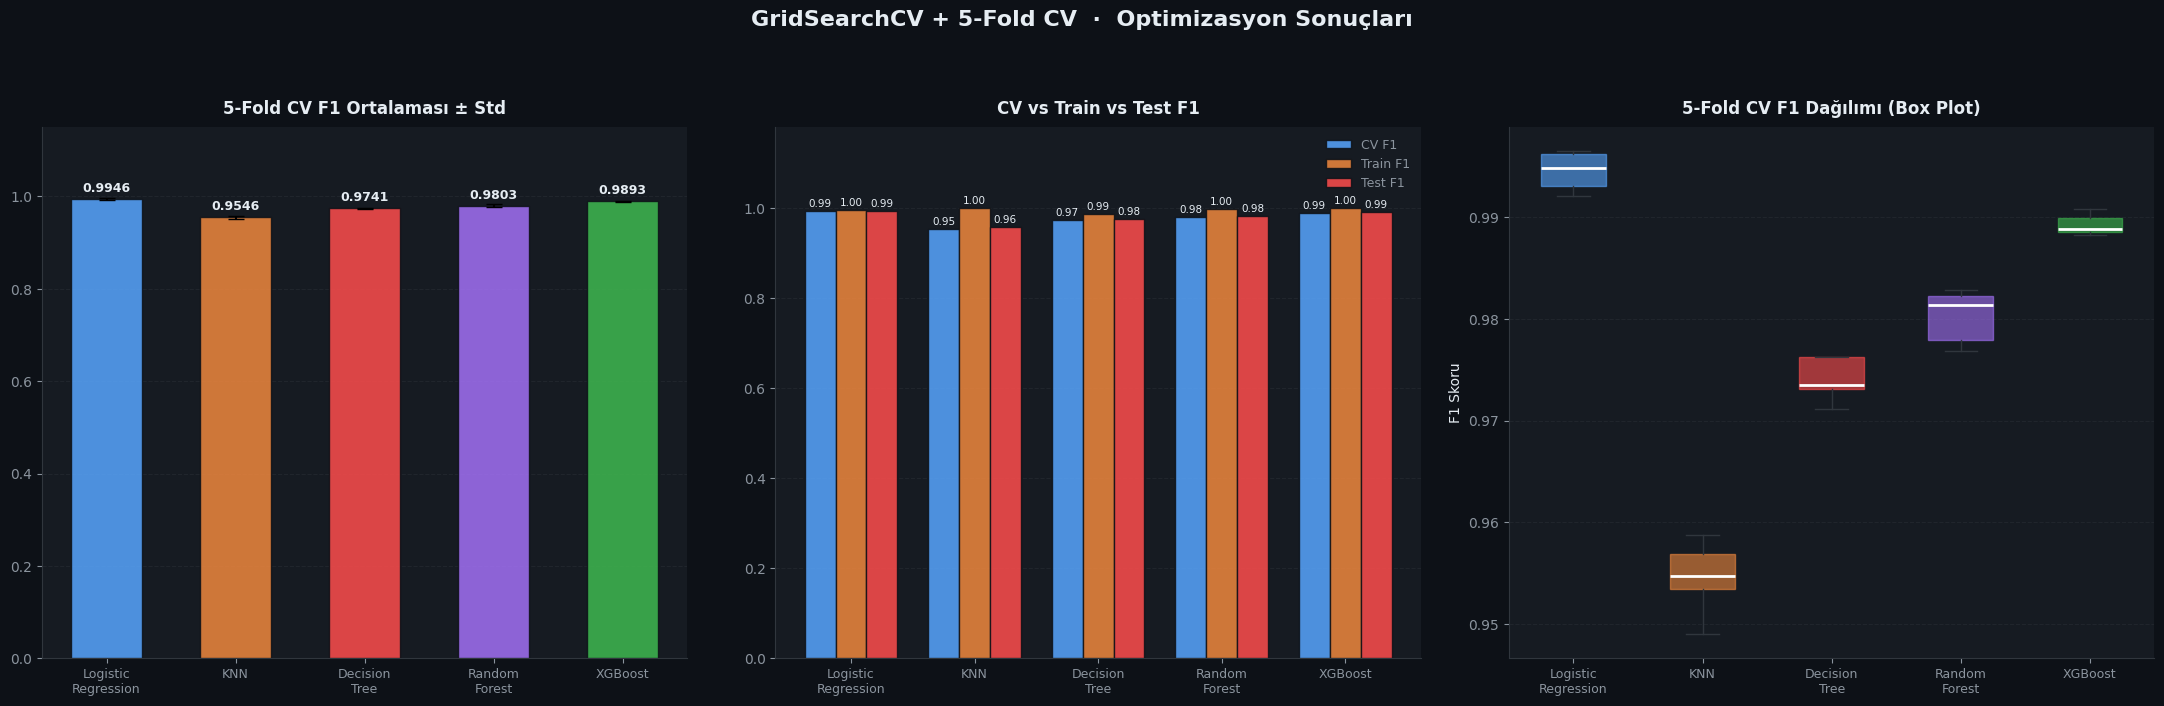

In [77]:
model_colors = [C1, C2, C3, ACCENT, "#3FB950"]
models_list  = cv_df['model'].tolist()

fig, axes = plt.subplots(1, 3, figsize=(22, 7))
fig.suptitle("GridSearchCV + 5-Fold CV  ·  Optimizasyon Sonuçları",
             fontsize=16, fontweight="bold", color=TEXT_PRI, y=1.02)

ax1 = axes[0]
means = cv_df['cv_f1_mean'].values
stds  = cv_df['cv_f1_std'].values
bars  = ax1.bar(models_list, means, yerr=stds,
                color=model_colors, edgecolor=BG,
                width=0.55, zorder=3, alpha=0.85,
                capsize=6, error_kw=dict(color=TEXT_SEC, lw=1.5))
for bar, val in zip(bars, means):
    ax1.text(bar.get_x() + bar.get_width()/2,
             bar.get_height() + max(stds)*1.2 + 0.005,
             f"{val:.4f}", ha="center", va="bottom",
             fontsize=9, fontweight="bold", color=TEXT_PRI)
ax1.set_title("5-Fold CV F1 Ortalaması ± Std",
              fontsize=12, fontweight="bold", color=TEXT_PRI, pad=10)
ax1.set_ylim(0, 1.15)
ax1.set_xticklabels([m.replace(" ","\n") for m in models_list],
                    fontsize=9, color=TEXT_SEC)
ax1.yaxis.grid(True, zorder=0); ax1.set_axisbelow(True)

ax2 = axes[1]
x   = np.arange(len(models_list))
w   = 0.25
b1  = ax2.bar(x - w, cv_df['cv_f1_mean'], width=w,
              color=C1, alpha=0.85, edgecolor=BG, label='CV F1',    zorder=3)
b2  = ax2.bar(x,     cv_df['train_f1'],   width=w,
              color=C2, alpha=0.85, edgecolor=BG, label='Train F1', zorder=3)
b3  = ax2.bar(x + w, cv_df['test_f1'],    width=w,
              color=C3, alpha=0.85, edgecolor=BG, label='Test F1',  zorder=3)
for bars_group in [b1, b2, b3]:
    for bar in bars_group:
        ax2.text(bar.get_x() + bar.get_width()/2,
                 bar.get_height() + 0.005,
                 f"{bar.get_height():.2f}",
                 ha="center", va="bottom",
                 fontsize=7.5, color=TEXT_PRI)
ax2.set_title("CV vs Train vs Test F1",
              fontsize=12, fontweight="bold", color=TEXT_PRI, pad=10)
ax2.set_xticks(x)
ax2.set_xticklabels([m.replace(" ","\n") for m in models_list],
                    fontsize=9, color=TEXT_SEC)
ax2.set_ylim(0, 1.18)
ax2.legend(frameon=False, fontsize=9, labelcolor=TEXT_SEC)
ax2.yaxis.grid(True, zorder=0); ax2.set_axisbelow(True)

ax3 = axes[2]
fold_data = [row['cv_scores'] for _, row in cv_df.iterrows()]
bp = ax3.boxplot(fold_data, patch_artist=True,
                 medianprops=dict(color="white", lw=2),
                 whiskerprops=dict(color=BORDER),
                 capprops=dict(color=BORDER),
                 flierprops=dict(marker="o", markersize=5, alpha=0.5))
for patch, color in zip(bp['boxes'], model_colors):
    patch.set_facecolor(color); patch.set_alpha(0.6)
    patch.set_edgecolor(color)
for flier, color in zip(bp['fliers'], model_colors):
    flier.set_markerfacecolor(color)
    flier.set_markeredgecolor(color)
ax3.set_xticks(range(1, len(models_list)+1))
ax3.set_xticklabels([m.replace(" ","\n") for m in models_list],
                    fontsize=9, color=TEXT_SEC)
ax3.set_title("5-Fold CV F1 Dağılımı (Box Plot)",
              fontsize=12, fontweight="bold", color=TEXT_PRI, pad=10)
ax3.set_ylabel("F1 Skoru", fontsize=10)
ax3.yaxis.grid(True, zorder=0); ax3.set_axisbelow(True)

plt.tight_layout(pad=2)
plt.show()